# DBN + Influence Diagram for S&P 500 Factor Investing

This notebook implements a **Dynamic Bayesian Network (DBN)** combined with an **Influence Diagram (ID)** for systematic factor investing in S&P 500 stocks.

## Methodology Overview

1. **Data Preparation**: Load S&P 500 price history and compute technical indicators
2. **Feature Engineering**: Create 13 technical indicators + macroeconomic features
3. **Target Variable**: Binary classification of forward returns (3-month excess return > 0)
4. **Discretization**: Convert continuous features to 5-bin categorical variables
5. **DBN Structure Learning**: Build 2-time-slice Bayesian Network with temporal dependencies
6. **Feature Selection**: Use time-weighted mutual information to select relevant predictors
7. **Inference**: Compute P(Y=1|features) for each stock at each decision date
8. **Calibration**: Map probabilities to expected returns using training data
9. **Influence Diagram**: Formalize sequential decisions (selection → allocation) with utility maximization
10. **Portfolio Construction**: Use mean-variance optimization with calibrated expectations

---



# 📊 **Step 1: Import Libraries and Load Data**

In [ ]:
from typing import Optional, Dict, Callable
import sys
import random
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
import traceback
import re
import pandas_ta as ta
from tqdm.notebook import tqdm
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (8,4)


import pyagrum as gum
import pyagrum.lib.dynamicBN as gdyn
import pyagrum.lib.notebook as gnb

from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mutual_info_score
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.isotonic import IsotonicRegression

from scipy.interpolate import PchipInterpolator
from scipy.optimize import minimize
from scipy.interpolate import interp1d
from scipy.stats import norm

import statsmodels.api as sm

import openassetpricing as oap
import yfinance as yf
import pandas_datareader as web

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

path_data = "../inputs/clean/"


print(f"platform:\t\t{sys.platform}")
print(f"python version:\t\t{sys.version}")
print(f"pandas version:\t\t{pd.__version__}")
print(f"numpy version:\t\t{np.__version__}")
print(f"matplotlib version:\t{matplotlib.__version__}")
print(f"yfinance version:\t{yf.__version__}")
print(f"pd-datareader version:\t{web.__version__}")
print(f"pyagrum version:\t{gum.__version__}")

platform:		linux
python version:		3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:16:04) [GCC 11.2.0]
pandas version:		2.3.3
numpy version:		1.26.4
matplotlib version:	3.10.7
yfinance version:	0.2.66
pd-datareader version:	0.10.0
pyagrum version:	2.2.1


## Data Downloading and Preprocessing


In [260]:
openap = oap.OpenAP()
openap.list_port() 


df_ = openap.dl_port('deciles_vw', 'pandas')
factors = df_[df_['port']=='LS'].signalname.unique()

# filter for LS (long short) port and selected factors
mask = (df_['port'] == 'LS') & (df_['signalname'].isin(factors))
ls_df = df_.loc[mask, ['signalname', 'date', 'ret']].copy()

# pivot to wide: index=date, columns=signalname, values=ret
df__ = ls_df.pivot(index='date', columns='signalname', values='ret')


# convert returns to decimals
df__ = df__ / 100

# filters for the most available data points
date = '1990-10-31'
df__ = df__[df__.index >= date ]
df_clean = df__.bfill(limit=3)

# drop columns where the last 1 values are all NaN
cols_to_drop_tail = df_clean.columns[df_clean.tail(1).isna().all()]
cols_to_drop = cols_to_drop_tail
df = df_clean.drop(columns=cols_to_drop).dropna(how='any', axis=1).copy()



┌─────────────────────────────────────────────────┬─────────────────────┐
│ CZ portfolio file                               │ Name for download   │
├─────────────────────────────────────────────────┼─────────────────────┤
│ PredictorAltPorts_Deciles.zip                   │ deciles_ew          │
│ PredictorAltPorts_DecilesVW.zip                 │ deciles_vw          │
│ PredictorAltPorts_LiqScreen_ME_gt_NYSE20pct.zip │ ex_nyse_p20_me      │
│ PredictorAltPorts_LiqScreen_NYSEonly.zip        │ nyse                │
│ PredictorAltPorts_LiqScreen_Price_gt_5.zip      │ ex_price5           │
│ PredictorAltPorts_Quintiles.zip                 │ quintiles_ew        │
│ PredictorAltPorts_QuintilesVW.zip               │ quintiles_vw        │
│ PredictorPortsFull.csv                          │ op                  │
└─────────────────────────────────────────────────┴─────────────────────┘

Data is downloaded: 4s


In [261]:
# retrieve indices data from Yahoo Finance
start = df.index[0]
end = df.index[-1]

tick = ['^GSPC', '^RUT', 'DX-Y.NYB', '^IRX', '^VIX']
yfin_data = yf.download(tick,
                        start,
                        end,
                        auto_adjust=False,
                        progress=False)['Close']

# change variable names into something more intuitive
yfin_data = yfin_data.loc[:,tick]
yfin_data.columns.name = None
yfin_data.rename(columns = {
    '^GSPC': 'SP500',
    '^RUT': 'RSSL2K',
    'DX-Y.NYB': 'USDIDX',
    '^IRX': 'TBLL13WK',
    '^VIX': 'VIX'
    },
    inplace=True)

yfin_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8708 entries, 1990-10-31 to 2024-12-30
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SP500     8605 non-null   float64
 1   RSSL2K    8605 non-null   float64
 2   USDIDX    8706 non-null   float64
 3   TBLL13WK  8576 non-null   float64
 4   VIX       8605 non-null   float64
dtypes: float64(5)
memory usage: 408.2 KB


In [262]:
# fetch macroeconomic indicator data from FRED
datasets_fred = [
    'GDP',
    'UNRATE',
    'CPIAUCSL',
    'USEPUINDXD',
    'TRESEGUSM052N',
    'WTISPLC'
    ]

fred_data = pd.DataFrame()
for f in datasets_fred:
    fred_data[f] = web.DataReader(f,'fred',start,end)
fred_data.rename(columns = {
    'M2REAL': 'M2SPPLY',
    'CPIAUCSL': 'INFLATION',
    'TRESEGUSM052N': 'GLDRSRV',
    'USEPUINDXD': 'POLICY',
    'WTISPLC': 'CRUDOIL'
    },
    inplace=True)
fred_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 136 entries, 1991-01-01 to 2024-10-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GDP        136 non-null    float64
 1   UNRATE     136 non-null    float64
 2   INFLATION  136 non-null    float64
 3   POLICY     136 non-null    float64
 4   GLDRSRV    136 non-null    float64
 5   CRUDOIL    136 non-null    float64
dtypes: float64(6)
memory usage: 7.4 KB


In [263]:
fred_data.tail()

,GDP,UNRATE,INFLATION,POLICY,GLDRSRV,CRUDOIL
DATE,,,,,,
2023-10-01,28424.722,3.9,307.653,143.15,229672.544554,85.64
2024-01-01,28708.161,3.7,309.794,110.48,232964.719173,74.15
2024-04-01,29147.044,3.9,313.016,113.74,230561.250351,85.35
2024-07-01,29511.664,4.2,313.566,244.08,234180.419138,81.80
2024-10-01,29825.182,4.1,315.564,58.83,232884.026202,71.99


In [ ]:
# concatenate into 1 dataframe
macro_df = pd.concat([df, yfin_data, fred_data], axis=1, join='outer')

# transform factor returns into cumulative returns
# for k in macro_df.columns[:6]:
#     macro_df[k] = (1 + macro_df[k]).cumprod()

# forward fill using the last data to avoid look-ahead bias
macro_df = macro_df.ffill()

# resample monthly & drop NaNs
macro_df = macro_df.resample('ME').last()
macro_df = macro_df.dropna()
macro_df.to_csv(path_data + 'macro_data.csv')
macro_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 408 entries, 1991-01-31 to 2024-12-31
Freq: ME
Columns: 173 entries, AM to CRUDOIL
dtypes: float64(173)
memory usage: 554.6 KB


In [265]:
macro_df.tail()

,AM,AOP,AbnormalAccruals,Accruals,AdExp,AgeIPO,AnalystRevision,AnalystValue,AnnouncementReturn,AssetGrowth,...,RSSL2K,USDIDX,TBLL13WK,VIX,GDP,UNRATE,INFLATION,POLICY,GLDRSRV,CRUDOIL
2024-08-31,-0.017737,-0.049702,0.043768,0.005813,-0.039660,0.082149,-0.008119,0.025297,0.001208,-0.046427,...,2217.629883,101.699997,4.968,15.00,29511.664,4.2,313.566,244.08,234180.419138,81.80
2024-09-30,-0.038262,-0.003674,-0.037136,0.004457,0.036032,0.021574,-0.037428,0.006873,0.006611,0.010751,...,2229.969971,100.779999,4.498,16.73,29511.664,4.2,313.566,244.08,234180.419138,81.80
2024-10-31,0.049080,-0.011045,0.015385,0.027163,-0.036986,0.023074,0.008152,0.054118,0.007795,0.007144,...,2196.649902,103.980003,4.432,23.16,29825.182,4.1,315.564,58.83,232884.026202,71.99
2024-11-30,0.052842,-0.070304,-0.012800,-0.059064,-0.000433,0.104989,0.048071,-0.056294,0.111638,-0.056705,...,2434.729980,105.739998,4.373,13.51,29825.182,4.1,315.564,58.83,232884.026202,71.99
2024-12-31,-0.079941,0.088907,0.034252,0.005743,0.000481,-0.034499,0.021701,0.001782,-0.012278,-0.059544,...,2227.780029,108.129997,4.182,17.40,29825.182,4.1,315.564,58.83,232884.026202,71.99


## Discretizing Macro Data

This **trend scanning** method was taken from Lopez de Prado's book (Machine Learning for Asset Managers, pp. 67-72). The Python implementation below was modified from code adaptations by Endre Moen (https://github.com/emoen/Machine-Learning-for-Asset-Managers).

Basically, this method uses the t-statistics from rolling linear regressions to determine if a stretch of price or index level series is part of an up-trend or a down-trend. I've modified the code so that it can label sideways price movement too (i.e., no trend), so we'll end up with 3 labels or "states".

In [266]:
# Define trend-scanning discretization functions

def tValLinR(close):
    """
    Compute the t-statistic of the slope coefficient from an OLS regression
    """
    if close.ndim > 1:
        close = close.ravel()
    n = close.shape[0]
    x = np.ones((n, 2))
    x[:, 1] = np.arange(n)
    ols = sm.OLS(close, x).fit()
    return float(ols.tvalues[1])

def getBinsFromTrend(
    molecule: pd.Index,
    close: pd.Series,
    span: tuple[int, int, int], # = (3, 20, 1),
    tval_clip: float = 30.0,
) -> pd.DataFrame:
    """
    Apply the trend-scanning method to generate labels.

    Parameters
    ----------
    molecule : pd.Index
        Subset of indices from `close` to evaluate.
    close : pd.Series
        Price or time series data.
    span : tuple[int, int, int], optional
        Range of window sizes to test (start, stop, step).
        Example: (3, 10, 1) tests windows of size 3..9.
    tval_clip : float, optional
        Maximum absolute value to clip t-statistics at.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - t1: Start time of chosen trend window
        - tVal: t-statistic of chosen window
        - bin: Sign of tVal (+1, -1, or 0)
        - windowSize: Length of chosen window
    """
    hrzns = range(*span)
    minWindow, maxWindow = span[0], span[1] - 1

    out = pd.DataFrame(index=molecule, columns=["t1", "tVal", "bin", "windowSize"])

    for idx in molecule:
        pos = close.index.get_loc(idx)
        if pos < maxWindow:
            continue # not enough history

        df_tval = pd.Series(dtype="float64")
        for hrzn in hrzns:
            start_pos = pos - hrzn + 1
            if start_pos < 0:
                continue
            dt1 = close.index[start_pos]
            df1 = close.iloc[start_pos : pos + 1]
            df_tval.loc[dt1] = tValLinR(df1.values)

        # Replace problematic values and choose window with strongest |t|
        df_tval = df_tval.replace([-np.inf, np.inf, np.nan], 0.0)
        if df_tval.empty:
            continue
        chosen_start = df_tval.abs().idxmax()
        chosen_tval = df_tval.loc[chosen_start]
        chosen_window = df_tval.abs().values.argmax() + minWindow

        out.loc[idx, ["t1", "tVal", "windowSize"]] = (chosen_start, chosen_tval, chosen_window)

    out["t1"] = pd.to_datetime(out["t1"])
    out["tVal"] = out["tVal"].astype(float).clip(-tval_clip, tval_clip)

    # Robust binning: handle duplicate edges or insufficient unique values
    tvals = out["tVal"].dropna()
    if tvals.nunique() <= 1:
        # not enough variation: assign single bin 0
        out["bin"] = 0
    else:
        try:
            # try qcut; allow pandas to drop duplicate edges if necessary
            out["bin"] = pd.qcut(out["tVal"], q=5, labels=False, duplicates="drop")
        except ValueError:
            # fallback to pd.cut using number of unique values (capped at 5)
            n_bins = min(5, tvals.nunique())
            out["bin"] = pd.cut(out["tVal"], bins=n_bins, labels=False)

    return out.dropna(subset=["bin"])



### Discretizing the Macro data

In [ ]:
# Set discretization parameters
idx_range_from = 3   # Minimum window size (months)
idx_range_to = 10    # Maximum window size (months)
tval_clip = 20.0     # Clipping threshold for t-values
print("✓ Trend-scanning is executing...")
print(f"  Parameters: window [{idx_range_from}, {idx_range_to}), t-clip ±{tval_clip}")

# now execute trend scanning & loop over all variables

def _scan_column(col_name):
    series = macro_df[col_name]
    bins = getBinsFromTrend(series.index, series, [idx_range_from, idx_range_to, 1], tval_clip)
    return col_name, bins['bin']

results = Parallel(n_jobs=-1, verbose=5)(
    delayed(_scan_column)(col) for col in macro_df.columns
)

macro_df_disc = pd.DataFrame(
    {col: vals for col, vals in results},
    index=macro_df.index
).dropna()

# create VIX regimes
macro_df_disc["VIX_regime"] = pd.qcut(
    macro_df["VIX"],
    q=[0.0, 0.33, 0.66, 1.0],
    labels=[0, 1, 2]
).astype("Int64")

#macro_df_disc["VIX_regime"] = macro_df["VIX_regime"]

macro_df_disc = macro_df_disc.dropna()

macro_df_disc.to_csv(path_data + 'macro_data_discretized.csv')
macro_df_disc.shape


✓ Trend-scanning is executing...
  Parameters: window [3, 10), t-clip ±20.0


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   25.9s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:   56.1s
[Parallel(n_jobs=-1)]: Done 173 out of 173 | elapsed:  1.1min finished


(399, 174)

## Loading Saved Data

In [ ]:

macro_df = pd.read_csv(path_data + "macro_data.csv", index_col=0, parse_dates=True)


# Load discretized data and fill NaNs to preserve dates
macro_df_disc = pd.read_csv(path_data + 'macro_data_discretized.csv', index_col=0, parse_dates=True)
macro_df_disc = macro_df_disc.fillna(method='ffill').fillna(method='bfill').dropna()

# rename SP500 column to SPX for future consisteny
macro_df.rename(columns={"SP500": "SPX"}, inplace=True)
macro_df_disc.rename(columns={"SP500": "SPX"}, inplace=True)

# factor_cols = [col for col in macro_df.columns if col != 'SPX']
# variability = macro_df[factor_cols].nunique() > 1
# varying_factors = [col for col in factor_cols if variability[col]]
# macro_df = macro_df[['SPX'] + varying_factors]
# macro_df_disc = macro_df_disc[['SPX'] + varying_factors]  # Apply same filter to discretized data

# loading the adjusted close prices of S&P 500
prices_df = pd.read_parquet(path_data + 'sp500_prices_wide.parquet')
prices_df = prices_df.resample('ME').last()
prices_m = prices_df.xs('Adj Close', axis=1, level=1)
# prices_m = pd.read_csv('sp500_adj_close_prices.csv', index_col=0, parse_dates=True)


# ============================================================================
# INDEX ALIGNMENT WITH PROPER NaN HANDLING
# ============================================================================

# STEP 1: Forward-fill BEFORE alignment (respects temporal causality)
# - Macros: short ffill (2-3 months) for quarterly releases
# - Prices: minimal ffill (1 month) for delistings/suspensions
macro_df = macro_df.fillna(method='ffill', limit=2)
macro_df_disc = macro_df_disc.fillna(method='ffill', limit=2)
prices_m = prices_m.fillna(method='ffill', limit=1)

# STEP 2: Align indices (intersection ensures all dates exist in all datasets)
usable_idx = (
    macro_df.index
    .intersection(macro_df_disc.index)
    .intersection(prices_m.index)
)

macro_df = macro_df.loc[usable_idx]
macro_df_disc = macro_df_disc.loc[usable_idx]
prices_m = prices_m.loc[usable_idx]

# STEP 3: Strategic post-alignment handling of remaining NaNs
# MEDIAN-fill for macro (better than 0 for indicators like VIX)
# Only fill columns that are truly missing (not discretized bins!)
continuous_macro_cols = [col for col in macro_df.columns if col not in ['SPX']]
for col in continuous_macro_cols:
    if macro_df[col].isna().any():
        median_val = macro_df[col].median()
        macro_df[col] = macro_df[col].fillna(median_val)
        print(f"  Filled {col} NaNs with median={median_val:.4f}")

# For discretized macro: use FORWARD-fill from nearest valid bin (temporal smoothing)
macro_df_disc = macro_df_disc.fillna(method='ffill', limit=1).fillna(method='bfill', limit=1)

# For prices: ONLY fill with 0 if explicitly delisted (rare case)
# Otherwise keep NaN to handle properly in panel building
prices_m = prices_m.fillna(0.)  # Your original logic (acceptable for prices)

# STEP 4: Final validation
print(f"✓ Aligned to {len(usable_idx)} dates: {usable_idx.min().date()} → {usable_idx.max().date()}")
print(f"  macro_df remaining NaNs: {macro_df.isna().sum().sum()}")
print(f"  macro_df_disc remaining NaNs: {macro_df_disc.isna().sum().sum()}")
print(f"  prices_m remaining NaNs: {prices_m.isna().sum().sum()}")


✓ Aligned to 399 dates: 1991-10-31 → 2024-12-31
  macro_df remaining NaNs: 0
  macro_df_disc remaining NaNs: 0
  prices_m remaining NaNs: 0


## Function `clean_prices_preserve_history`
Purpose
- Clean monthly prices while preserving history and names (no column drops).

Inputs
- prices_df: DataFrame (dates × tickers).
- min_price: Treat prices < min_price as invalid.

Output
- Cleaned DataFrame with zeros → NaN, tiny values → NaN, short ffill (limit=3).

Procedure
- Replace 0 with NaN; NaN any price < min_price.
- Forward-fill gaps up to 3 months to handle small glitches.
- Print diagnostics.

Notes
- Keeps penny stocks (>=$0.01) but removes suspicious tiny values.

In [269]:
def clean_prices_preserve_history(prices_df, min_price=0.01):
    """
    Clean prices WITHOUT removing stocks
    
    Strategy:
    - Replace zeros with NaN (invalid data points)
    - Keep stocks even if they were penny stocks historically
    - Forward-fill gaps (up to 3 months)
    """
    prices_clean = prices_df.copy()
    
    # Step 1: Replace zeros with NaN (invalid observations)
    prices_clean = prices_clean.replace(0, np.nan)
    
    # Step 2: Replace extremely low prices (likely data errors, not real penny stocks)
    # Only flag prices below $0.01 as errors (true penny stocks like $0.50-$4.99 are OK!)
    prices_clean = prices_clean.where(prices_clean >= min_price, np.nan)
    
    # Step 3: Forward-fill short gaps (handle delisting/IPO transitions)
    prices_clean = prices_clean.fillna(method='ffill', limit=3)
    
    print(f"✅ Price cleaning complete:")
    print(f"   Original shape: {prices_df.shape}")
    print(f"   Cleaned shape:  {prices_clean.shape}")
    print(f"   Zeros removed: {(prices_df == 0).sum().sum():,}")
    print(f"   NaNs introduced: {prices_clean.isna().sum().sum() - prices_df.isna().sum().sum():,}")
    
    return prices_clean

# Apply cleaning (keeps all stocks!)
prices_m_clean = clean_prices_preserve_history(prices_m, min_price=0.01)


✅ Price cleaning complete:
   Original shape: (399, 503)
   Cleaned shape:  (399, 503)
   Zeros removed: 39,186
   NaNs introduced: 39,189


## Function `to_month_end_index`
Purpose
- Align an index to month-end timestamps.

Input
- idx: DatetimeIndex-like.

Output
- DatetimeIndex aligned to month-end.

Procedure
- Cast to Period('M') and to_timestamp('M').

In [270]:
# --- PARAMETERS (tune later) ---
M   = 3     # rebalancing frequency in months
FWD = 3     # evaluation horizon in months (often FWD=M)




def to_month_end_index(idx):
    i = pd.DatetimeIndex(idx)
    return i.to_period('M').to_timestamp('M')

# Ensure month-end alignment
macro_df.index         = to_month_end_index(macro_df.index)
macro_df_disc.index = to_month_end_index(macro_df_disc.index)
prices_m_clean.index    = to_month_end_index(prices_m_clean.index)

print("macro_df span :", macro_df.index.min().date(), "→", macro_df.index.max().date(), "| rows:", len(macro_df))
print("macro_df_disc span:", macro_df_disc.index.min().date(), "→", macro_df_disc.index.max().date(), "| rows:", len(macro_df_disc))
print("prices_m span :", prices_m_clean.index.min().date(), "→", prices_m_clean.index.max().date(), "| rows:", len(prices_m_clean))
usable_idx = macro_df.index.intersection(macro_df_disc.index).intersection(prices_m.index)
print("USABLE span:", usable_idx.min().date(), "→", usable_idx.max().date(), "| rows:", len(usable_idx))


macro_df span : 1991-10-31 → 2024-12-31 | rows: 399
macro_df_disc span: 1991-10-31 → 2024-12-31 | rows: 399
prices_m span : 1991-10-31 → 2024-12-31 | rows: 399
USABLE span: 1991-10-31 → 2024-12-31 | rows: 399


In [271]:
# split data into training & testing sets (80:20 split)

train_ratio = 0.80  

macro_train = macro_df.iloc[: int(macro_df.shape[0] * train_ratio)]
macro_test = macro_df.iloc[int(macro_df.shape[0] * train_ratio) : ]

macro_disc_train = macro_df_disc.iloc[: int(macro_df_disc.shape[0] * train_ratio)]
macro_disc_test = macro_df_disc.iloc[int(macro_df_disc.shape[0] * train_ratio) : ]


prices_train = prices_m_clean.iloc[:int(len(prices_m_clean) * train_ratio)]
prices_test = prices_m_clean.iloc[int(len(prices_m_clean) * train_ratio):]

prices_df_train = prices_df.iloc[:int(len(prices_df) * train_ratio)]
prices_df_test = prices_df.iloc[int(len(prices_df) * train_ratio):]



print("Training Set Size: ", macro_disc_train.shape)
print("Start of Training Period: ", macro_disc_train.index[0])
print("End of Training Period: ", macro_disc_train.index[-1])

print("\nTesting Set Size: ", macro_disc_test.shape)
print("Start of Testing Period: ", macro_disc_test.index[0])
print("End of Testing Period: ", macro_disc_test.index[-1])

Training Set Size:  (319, 174)
Start of Training Period:  1991-10-31 00:00:00
End of Training Period:  2018-04-30 00:00:00

Testing Set Size:  (80, 174)
Start of Testing Period:  2018-05-31 00:00:00
End of Testing Period:  2024-12-31 00:00:00


# 📊 **Step 2: Compute Forward Returns**

Calculate `M`-month forward excess returns (vs S&P 500) for each stock.
This will be our target variable: Y = 1 if excess return > 0, else Y = 0.

## Function `compute_forward_returns`
Purpose
- Compute forward log returns over FWD periods, robust to missing decision dates and extreme values.

Inputs
- prices: Series or DataFrame with datetime index.
- dates: Optional list of decision dates to reindex onto.
- FWD: Forward horizon in periods (months).
- max_return_log: Cap for extreme log-returns.

Output
- DataFrame (or Series if input was Series) of forward log-returns at requested dates.

Procedure
- Shift -FWD and take log ratio.
- Replace ±inf with NaN and clip to ±max_return_log.
- If dates provided, reindex to those dates.

Notes
- Use with SPX too, then compute excess returns by subtraction.

In [272]:
def compute_forward_returns(prices, dates=None, FWD=3, max_return_log=0.693):
    """
    Compute forward log-returns with safeguards and tolerate dates missing from the price index.

    - prices : pd.Series or pd.DataFrame (index = dates)
    - dates  : list-like of decision dates (may include dates not present in prices.index)
    - FWD    : forward horizon in periods (months)
    - max_return_log : cap in log-return space (default ≈ ln(2) for 100% cap)
    """
    # normalize input
    if isinstance(prices, pd.Series):
        prices_df = prices.to_frame()
    else:
        prices_df = prices.copy()

    # compute forward log returns for all available dates
    fwd_all = np.log(prices_df.shift(-FWD) / prices_df)

    # replace inf and -inf with NaN
    fwd_all = fwd_all.replace([np.inf, -np.inf], np.nan)

    # cap extreme values
    fwd_all = fwd_all.clip(lower=-max_return_log, upper=max_return_log)

    # if no specific dates requested, return full frame
    if dates is None:
        return fwd_all

    # coerce dates to DatetimeIndex and reindex (will introduce NaN rows for missing dates)
    dates_idx = pd.to_datetime(dates)
    # preserve name if provided
    if isinstance(dates, pd.DatetimeIndex) and dates_idx.name is None:
        dates_idx.name = dates.name

    return fwd_all.reindex(dates_idx)


In [273]:
# Decision dates: every M-th month on the discretized-factor calendar
all_months = macro_train.index.sort_values()
decisions = all_months[::M]

# Need FWD look-ahead to compute forward returns
last_eval_month = macro_train.index.max() - pd.offsets.MonthEnd(FWD)
decisions = decisions[decisions <= last_eval_month]

# Forward log-returns for each ticker over FWD months
px = prices_train.sort_index()
fwd_px = compute_forward_returns(px, decisions, FWD, max_return_log=0.693)
# fwd_px = np.log(px.shift(-FWD) / px).loc[decisions]  # (dates × tickers)

# Forward SPX log-return from df1['SPX']
spx = macro_train['SPX'].sort_index()
fwd_spx = compute_forward_returns(spx.to_frame(), decisions, FWD, max_return_log=0.693)
# fwd_spx = np.log(spx.shift(-FWD) / spx).loc[decisions]  # (dates, )

# Keep only dates where both are available
valid_dec = fwd_spx.dropna().index.intersection(fwd_px.dropna(how='all').index)
fwd_px  = fwd_px.loc[valid_dec]
fwd_spx = fwd_spx.loc[valid_dec]

print("Decision count:", len(decisions), "| Valid decisions:", len(valid_dec))
print("valid_dec span:", valid_dec.min().date(), "→", valid_dec.max().date())
print("fwd_px shape:", fwd_px.shape, "| fwd_spx shape:", fwd_spx.shape)
print("Sample valid_dec (first 5):", list(valid_dec[:5].date))



Decision count: 106 | Valid decisions: 106
valid_dec span: 1991-10-31 → 2018-01-31
fwd_px shape: (106, 503) | fwd_spx shape: (106, 1)
Sample valid_dec (first 5): [datetime.date(1991, 10, 31), datetime.date(1992, 1, 31), datetime.date(1992, 4, 30), datetime.date(1992, 7, 31), datetime.date(1992, 10, 31)]


# 📊 **Step 3: Compute Technical Indicators**

## Function `compute_technical_indicators`

Purpose
- Compute a set of technical indicators per ticker from OHLCV (pandas_ta), handling bad data and ensuring numeric dtypes.

Inputs
- prices_df: Wide MultiIndex columns (ticker, field) with OHLCV.
- tickers: Optional subset to compute.
- fillna: If True, fill remaining NaNs with 0.
- min_rows: Minimum non-NaN rows to compute per ticker.

Output
- Wide MultiIndex DataFrame (ticker, indicator) with numeric indicators across time.

Procedure
- Validate MultiIndex, ensure OHLCV presence, coerce to float64.
- Safely compute momentum, trend, volatility, oscillators (RSI, ROC, MACD, SMA/EMA, ADX, Aroon, ATR/NATR, BBands, Stoch, CCI, Williams %R).
- Drop all-null columns; optional fillna; concatenate across tickers.

Notes
- Internally guards against pandas_ta inconsistencies and dtype drift.

In [274]:
def compute_technical_indicators(prices_df: pd.DataFrame, tickers=None, min_rows=15):
    """
    Compute technical indicators with integrated cleaning.
    
    Assumes prices_df has MultiIndex columns (ticker, field) with OHLCV data.
    Returns MultiIndex DataFrame (ticker, indicator).
    """
    all_tickers = prices_df.columns.get_level_values(0).unique()
    tickers = all_tickers if tickers is None else tickers
    
    # Helper for safe pandas_ta calls
    def _safe_ta(func, *args, **kwargs):
        try:
            res = func(*args, **kwargs)
            if res is None:
                return None
            return res.apply(pd.to_numeric, errors='coerce') if isinstance(res, pd.DataFrame) else pd.to_numeric(res, errors='coerce')
        except:
            return None
    
    # Neutral fill values per indicator type
    neutral_fills = {
        'rsi': 50, 'stoch': 50, 'cci': 0, 'willr': -50,
        'macd': 0, 'adx': 25,
        'sma': 'median', 'ema': 'median', 'atr': 'median', 'natr': 'median', 'bb': 'median'
    }
    
    def _get_neutral(ind_name, col_data):
        """Get neutral fill value for an indicator"""
        for key, val in neutral_fills.items():
            if ind_name.lower().startswith(key):
                return col_data.median() if val == 'median' else val
        return col_data.median()  # default to median for unknown indicators
    
    outs = []
    for tk in tickers:
        if tk not in all_tickers:
            continue
        
        df = prices_df[tk]
        if not {'Open','High','Low','Close','Volume'}.issubset(df.columns):
            continue
        
        # Convert to numeric float64 with lowercase columns
        ohlcv = (df[['Open','High','Low','Close','Volume']]
                 .apply(pd.to_numeric, errors='coerce')
                 .astype('float64')
                 .rename(columns=str.lower))
        
        if ohlcv['close'].notna().sum() < min_rows:
            continue
        
        feat = pd.DataFrame(index=ohlcv.index)
        
        # === MOMENTUM ===
        feat['rsi_14'] = _safe_ta(ta.rsi, ohlcv['close'], length=14)
        feat['roc_12'] = _safe_ta(ta.roc, ohlcv['close'], length=12)
        
        macd = _safe_ta(ta.macd, ohlcv['close'], fast=12, slow=26, signal=9)
        if macd is not None:
            if 'MACD_12_26_9' in macd.columns:
                feat['macd'] = macd['MACD_12_26_9']
            if 'MACDh_12_26_9' in macd.columns:
                feat['macd_hist'] = macd['MACDh_12_26_9']
            if 'MACDs_12_26_9' in macd.columns:
                feat['macd_signal'] = macd['MACDs_12_26_9']
        
        # === TREND ===
        feat['sma_20'] = _safe_ta(ta.sma, ohlcv['close'], length=20)
        feat['sma_50'] = _safe_ta(ta.sma, ohlcv['close'], length=50)
        feat['ema_12'] = _safe_ta(ta.ema, ohlcv['close'], length=12)
        feat['ema_26'] = _safe_ta(ta.ema, ohlcv['close'], length=26)
        
        adx = _safe_ta(ta.adx, ohlcv['high'], ohlcv['low'], ohlcv['close'], length=14)
        if adx is not None and 'ADX_14' in adx.columns:
            feat['adx_14'] = adx['ADX_14']
        
        aroon = _safe_ta(ta.aroon, ohlcv['high'], ohlcv['low'], length=25)
        if aroon is not None:
            if 'AROONU_25' in aroon.columns:
                feat['aroon_up_25'] = aroon['AROONU_25']
            if 'AROOND_25' in aroon.columns:
                feat['aroon_dn_25'] = aroon['AROOND_25']
        
        # === VOLATILITY ===
        feat['atr_14'] = _safe_ta(ta.atr, ohlcv['high'], ohlcv['low'], ohlcv['close'], length=14)
        feat['natr_14'] = _safe_ta(ta.natr, ohlcv['high'], ohlcv['low'], ohlcv['close'], length=14)
        
        bb = _safe_ta(ta.bbands, ohlcv['close'], length=20, std=2)
        if bb is not None:
            if 'BBM_20_2.0' in bb.columns:
                feat['bb_m20'] = bb['BBM_20_2.0']
            if 'BBP_20_2.0' in bb.columns:
                feat['bb_pctb_20_2'] = bb['BBP_20_2.0']
            if 'BBB_20_2.0' in bb.columns:
                feat['bb_bw_20_2'] = bb['BBB_20_2.0']
        
        # === OSCILLATORS ===
        st = _safe_ta(ta.stoch, ohlcv['high'], ohlcv['low'], ohlcv['close'], k=14, d=3)
        if st is not None:
            k_cols = [c for c in st.columns if 'STOCHK_' in c]
            d_cols = [c for c in st.columns if 'STOCHD_' in c]
            if k_cols:
                feat['stoch_k_14_3'] = st[k_cols[0]]
            if d_cols:
                feat['stoch_d_14_3'] = st[d_cols[0]]
        
        feat['cci_20'] = _safe_ta(ta.cci, ohlcv['high'], ohlcv['low'], ohlcv['close'], length=20)
        feat['willr_14'] = _safe_ta(ta.willr, ohlcv['high'], ohlcv['low'], ohlcv['close'], length=14)
        
        # === INTEGRATED CLEANING ===
        # Step 1: Replace inf with NaN
        feat = feat.replace([np.inf, -np.inf], np.nan)
        
        # Step 2: Forward-fill short gaps (3 months for monthly data)
        feat = feat.fillna(method='ffill', limit=3)
        
        # Step 3: Backward-fill only at series start (for new tickers)
        for col in feat.columns:
            first_valid = feat[col].first_valid_index()
            if first_valid is not None:
                start_idx = feat.index.get_loc(first_valid)
                if start_idx > 0:
                    feat.loc[:first_valid, col] = feat.loc[:first_valid, col].fillna(method='bfill', limit=2)
        
        # Step 4: Context-aware neutral fill for remaining NaNs
        for col in feat.columns:
            if feat[col].isna().any():
                neutral = _get_neutral(col, feat[col])
                feat[col] = feat[col].fillna(neutral)
        
        # Drop all-NaN columns
        feat = feat.loc[:, feat.notna().any()]
        
        if feat.empty:
            continue
        
        # Add ticker level to column MultiIndex
        feat.columns = pd.MultiIndex.from_product([[tk], feat.columns])
        outs.append(feat)
    
    if not outs:
        return pd.DataFrame(index=prices_df.index)
    
    return pd.concat(outs, axis=1).sort_index(axis=1, level=0)

In [275]:
def indicators_to_dict(indicators_wide: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    Convert a wide MultiIndex DataFrame with columns (ticker, indicator)
    into a dict: {indicator_name: DataFrame(index=Date, columns=[tickers])}.
    """
    if not isinstance(indicators_wide.columns, pd.MultiIndex) or indicators_wide.columns.nlevels != 2:
        raise ValueError("Expected columns MultiIndex with levels (ticker, indicator).")

    # Reorder to (indicator, ticker) -> easy to group and slice
    swapped = indicators_wide.swaplevel(0, 1, axis=1).sort_index(axis=1)

    # Split into {indicator: df_of_all_tickers}
    out = {}
    for ind, sub in swapped.groupby(level=0, axis=1):
        # remove the indicator level so columns are just tickers
        out[ind] = sub.droplevel(0, axis=1).copy()
    return out

In [276]:
# prices_df: the wide MultiIndex (ticker, field) DataFrame
train_indicators = compute_technical_indicators(prices_df_train)
train_indicators = indicators_to_dict(train_indicators)

Here we will selects the stocks that have outperformed the market (S&P 500 index) over the next `FWD` months. This is done by comparing the forward returns of each stock to the forward return of the S&P 500 index. If a stock's forward return is greater than the S&P 500's forward return, it is considered to have outperformed the market. In this case we assign a label of `1` to that stock for that decision date. Conversely, if a stock's forward return is less than or equal to the S&P 500's forward return, it is assigned a label of `0`. These labels are not indicating any trading signal for now. For each rebalancing period we will use this labels to select the stocks that will be consider for asset picking process. 


# 📊 **Step 4: Discretization (Continuous → Categorical)**

We discretize continuous technical indicators into 5 categorical bins for each decision date using cross-sectional quantile-based binning. This converts continuous features into ordinal categories (0-4), making them suitable for the DBN's discrete probability distributions. We also create binary labels (Y) by comparing each stock's forward return to the S&P 500 forward return.

## Function: `xsec_discretize`

Purpose
- Cross-sectional quantile binning per date into ordinal bins (0..n_bins-1) for a feature matrix.

Inputs
- df: DataFrame (date × tickers) for one indicator.
- n_bins: Number of quantile bins.

Output
- DataFrame of integer bins per date.

Procedure
- For each date, fit KBinsDiscretizer(strategy='quantile') on finite values; write back per-ticker bins.

Notes
- Requires at least n_bins finite values for a date; otherwise leaves NaN.

In [277]:
def xsec_discretize(df, n_bins=5):
    out = []
    for dt, row in df.iterrows():
        x = row.values.astype(float)
        mask = np.isfinite(x)
        y = np.full_like(x, np.nan, dtype=float)
        if mask.sum() >= n_bins:
            est = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
            y[mask] = est.fit_transform(x[mask].reshape(-1,1)).ravel()
        out.append(pd.Series(y, index=row.index, name=dt))
    return pd.DataFrame(out)


train_indicators_disc = {k: xsec_discretize(v, 3).round().astype('Int64') for k, v in train_indicators.items()}


# 📊 **Step 5: Build Panel DataFrame** 

Create MultiIndex DataFrame (date, ticker) with all discretized features.
This panel structure is required for 2-time-slice Bayesian Network.

## Function: `build_panel`

Purpose
- Assemble a panel with MultiIndex (date, ticker) containing target Y and features (technicals and macro), with optional internal macro discretization.

Inputs
- cont_factor_df: Continuous macro/SPX DataFrame (must include 'SPX').
- prices_df: Wide MultiIndex prices (ticker, field).
- indicators_dict: Dict of indicator DataFrames (continuous for FWD=1; discrete for classification).
- FWD: Forward horizon; for FWD=1 returns a continuous Y; otherwise binary Y.
- is_continuous: If True, keep Y continuous (MI regression use).
- macro_disc_df: Optional precomputed discretized macro; else trend-scan internally.
- filter_decisions: If True, only dates with realizable FWD labels.

Outputs
- panel: MultiIndex DataFrame with columns: Y, indicators, macro states.
- valid_dec: DatetimeIndex of decision dates used.

Procedure
- Build decision date grid; compute forward returns for stocks and SPX; create Y (excess).
- Stack Y and indicators to (date, ticker); fill feature NaNs with 0 (keep Y possibly NaN for current date).
- Prepare macro: continuous (FWD=1) or discretized (provided or computed via trend-scanning).
- Broadcast macro states across tickers; type-cast to Int for discrete regime.

Notes
- Avoids label leakage by restricting dates when filter_decisions is True.

In [278]:
def build_panel(cont_factor_df, prices_df, indicators_dict, FWD=1, 
                macro_disc_df=None, filter_decisions=None,
                benchmark='SPX'):
    """
    Build panel with MultiIndex (date, ticker).
        
    Parameters:
    - cont_factor_df: ALWAYS continuous macro/price dataframe (macro_df)
    - prices_df: DataFrame with stock prices (continuous)
    - indicators_dict: Technical indicators (continuous)
    - FWD: Forward period for computing returns
    - filter_decisions: If True, filter decisions to <= last_eval_month (for training). If None, defaults to True if FWD != 0.

    Returns:
    - panel: MultiIndex DataFrame (date, ticker) with Y and all features
    - valid_dec: DatetimeIndex of valid decision dates
    """
    assert FWD >= 1, f"FWD must be greater than or equal to 1, you have {FWD}"
    
    prices_df = prices_df.xs('Adj Close', axis=1, level=1)

    if filter_decisions is None:
        filter_decisions = (FWD != 1)
    
    # --- decision grid ---
    all_months = cont_factor_df.index.sort_values()
    decisions = all_months[::FWD] if filter_decisions else all_months
    if filter_decisions:
        last_eval_month = cont_factor_df.index.max() # - pd.offsets.MonthEnd(FWD)
        decisions = decisions[decisions <= last_eval_month]



    # Forward log-returns for each ticker over FWD months
    px = prices_df.sort_index()
    fwd_px = compute_forward_returns(px, decisions, FWD)

    # Forward SPX return
    if benchmark not in cont_factor_df.columns:
        raise ValueError(f"cont_factor_df must contain continuous '{benchmark}' series")
    spx = cont_factor_df[benchmark].sort_index()
    fwd_spx = compute_forward_returns(
        spx.to_frame(), 
        decisions, 
        FWD
    )[benchmark]
 
    # SET valid_dec = decisions to include current date even if fwd returns are NaN
    valid_dec = decisions
    fwd_px  = fwd_px.loc[valid_dec]
    fwd_spx = fwd_spx.loc[valid_dec]


    # EXCLUDE SPX from factor columns (only used for Y calculation)
    FACTOR_COLS = [col for col in cont_factor_df.columns if col != 'SPX']

    # 1) Relative label Y
    fwd_excess = fwd_px.sub(fwd_spx, axis=0)
    if FWD == 1:
        Y_panel = fwd_excess
    else:
        Y_panel = (fwd_excess > 0).astype('Int64')

    # Ensure consistent naming and indices
    for W in (Y_panel, *indicators_dict.values()):
        W.index.name = 'date'
        W.columns.name = 'ticker'

    # Stack to MultiIndex series
    Y_s = Y_panel.stack(dropna=False).rename('Y')
    indicators_dict_s = {k: v.stack(dropna=False).rename(k) for k, v in indicators_dict.items()}

    # Concatenate label + technicals on MultiIndex (date,ticker)
    panel_mi = pd.concat([Y_s, *indicators_dict_s.values()], axis=1)
    
    # Drop NaNs only in features (not Y, as it's NaN for current date in backtest)
    feature_cols = list(indicators_dict.keys())
    panel_mi[feature_cols] = panel_mi[feature_cols].fillna(0)
    panel_mi = panel_mi.loc[valid_dec]

    # For scoring, drop rows where Y is NaN
    # if FWD != 1 and panel_mi['Y'].isna().any():  
    #     panel_mi = panel_mi.dropna(subset=['Y'])

    # Handle macro discretization internally ===
    if FWD==1:
        # Use continuous macro factors directly
        macro_df = cont_factor_df.loc[valid_dec, FACTOR_COLS].copy()
    elif FWD != 1 and macro_disc_df is not None:
        # Use provided discretized macro factors, adjust FACTOR_COLS to match
        # FACTOR_COLS = [col for col in macro_disc_df.columns if col != benchmark]
        FACTOR_COLS = macro_disc_df.columns.tolist()

        macro_disc_df = macro_disc_df.dropna()
        # Intersect valid_dec with available macro dates to avoid KeyError
        valid_dec = valid_dec.intersection(macro_disc_df.index)
        # Re-filter fwd data to the updated valid_dec
        fwd_px = fwd_px.loc[valid_dec]
        fwd_spx = fwd_spx.loc[valid_dec]
        macro_df = macro_disc_df.loc[valid_dec, FACTOR_COLS].astype('Int64').copy()

    else:
        # Discretize macro factors using trend scanning (getBinsFromTrend)
        print("  Discretizing macro factors using trend scanning...")
        macro_disc_df = pd.DataFrame(index=cont_factor_df.index, columns=FACTOR_COLS)
        
        for col in FACTOR_COLS:
            col_series = pd.Series(index=cont_factor_df.index, data=cont_factor_df[col].values)
            col_discretized = getBinsFromTrend(
                col_series.index, 
                col_series, 
                [3, 10, 1],  # window span (same as notebook default)
                tval_clip=20.0
            )
            macro_disc_df[col] = col_discretized['bin']
        
        macro_disc_df = macro_disc_df.dropna()
        # FIX: Intersect valid_dec with available macro dates
        valid_dec = valid_dec.intersection(macro_disc_df.index)
        # Re-filter fwd data to the updated valid_dec
        fwd_px = fwd_px.loc[valid_dec]
        fwd_spx = fwd_spx.loc[valid_dec]
        macro_df = macro_disc_df.loc[valid_dec, FACTOR_COLS].astype('Int64').copy()

    # Broadcast macro states across tickers
    dates_for_rows = panel_mi.index.get_level_values('date')
    macro_broadcast = pd.DataFrame(
        macro_df.reindex(dates_for_rows).values,
        index=panel_mi.index,
        columns=FACTOR_COLS
    )

    # Final panel
    panel = pd.concat([panel_mi, macro_broadcast], axis=1)

    if FWD != 1:
        findic_cols = list(indicators_dict.keys())
        panel[['Y', *findic_cols] + FACTOR_COLS] = panel[['Y', *findic_cols] + FACTOR_COLS].astype('Int64')
    

    return panel, valid_dec

In [279]:
panel, valid_dec = build_panel(
    cont_factor_df=macro_train,        # continuous (discretized internally)
    prices_df=prices_df_train,
    indicators_dict=train_indicators_disc,  # already discretized
    FWD=FWD,
    macro_disc_df=macro_disc_train,
    filter_decisions=True
)

panel

Y  adx_14  aroon_dn_25  aroon_up_25  atr_14  cci_20  \
date       ticker                                                        
1991-10-31 A       0       1            2            0       2       1   
           AAPL    1       1            2            0       0       1   
           ABBV    0       1            1            1       2       1   
           ABNB    0       0            0            0       0       0   
           ABT     1       0            0            1       0       0   
...               ..     ...          ...          ...     ...     ...   
2018-04-30 XYZ     0       2            0            2       1       2   
           YUM     0       1            0            2       1       1   
           ZBH     0       0            0            0       2       0   
           ZBRA    0       1            1            2       2       2   
           ZTS     0       2            0            2       1       2   

                   ema_12  ema_26  macd  macd_hist  ...  USDIDX  TBLL13WK  \
date       ticker                                   ...                     
1991-10-31 A            2       1     0          0  ...       1         0   
           AAPL         0       0     0          0  ...       1         0   
           ABBV         2       2     0          0  ...       1         0   
           ABNB         0       0     0          0  ...       1         0   
           ABT          0       1     0          0  ...       1         0   
...                   ...     ...   ...        ...  ...     ...       ...   
2018-04-30 XYZ          0       0     2          2  ...       2         4   
           YUM          1       1     1          2  ...       2         4   
           ZBH          2       2     0          0  ...       2         4   
           ZBRA         2       2     2          2  ...       2         4   
           ZTS          1       1     2          2  ...       2         4   

                   VIX  GDP  UNRATE  INFLATION  POLICY  GLDRSRV  CRUDOIL  \
date       ticker                                                          
1991-10-31 A         1    4       4          2       3        0        2   
           AAPL      1    4       4          2       3        0        2   
           ABBV      1    4       4          2       3        0        2   
           ABNB      1    4       4          2       3        0        2   
           ABT       1    4       4          2       3        0        2   
...                ...  ...     ...        ...     ...      ...      ...   
2018-04-30 XYZ       4    4       1          4       3        2        4   
           YUM       4    4       1          4       3        2        4   
           ZBH       4    4       1          4       3        2        4   
           ZBRA      4    4       1          4       3        2        4   
           ZTS       4    4       1          4       3        2        4   

                   VIX_regime  
date       ticker              
1991-10-31 A                1  
           AAPL             1  
           ABBV             1  
           ABNB             1  
           ABT              1  
...                       ...  
2018-04-30 XYZ              1  
           YUM              1  
           ZBH              1  
           ZBRA             1  
           ZTS              1  

[53821 rows x 191 columns]

In [280]:
panel_, valid_dec = build_panel(
    cont_factor_df=macro_train,        # continuous (discretized internally)
    prices_df=prices_df_train,
    indicators_dict=train_indicators,  # already discretized
    FWD=1,
    macro_disc_df=None,
    filter_decisions=True
)

panel_

Y     adx_14  aroon_dn_25  aroon_up_25     atr_14  \
date       ticker                                                             
1991-10-31 A            NaN  25.000000         24.0         56.0   3.787676   
           AAPL    0.030228  45.292872         24.0         72.0   0.080578   
           ABBV         NaN  25.000000         16.0         80.0   6.225437   
           ABNB         NaN   0.000000          0.0          0.0   0.000000   
           ABT     0.028120  23.597487         12.0         80.0   0.513179   
...                     ...        ...          ...          ...        ...   
2018-04-30 XYZ          NaN  69.673407         12.0         96.0   6.566090   
           YUM          NaN  28.591234          0.0        100.0   5.364278   
           ZBH          NaN  13.405639          0.0         64.0  10.809301   
           ZBRA         NaN  35.634312         16.0         96.0  13.688756   
           ZTS          NaN  50.400284          0.0        100.0   5.366594   

                        cci_20      ema_12      ema_26       macd  macd_hist  \
date       ticker                                                              
1991-10-31 A          0.000000   26.205007   26.442232   0.000000   0.000000   
           AAPL    -409.768354    0.433760    0.809687   0.000000   0.000000   
           ABBV       0.000000   59.785892   57.116200   0.000000   0.000000   
           ABNB       0.000000    0.000000    0.000000   0.000000   0.000000   
           ABT     -505.800665    5.648095   20.942127   0.000000   0.000000   
...                        ...         ...         ...        ...        ...   
2018-04-30 XYZ     -114.259722   37.108768   28.228830   8.879938   2.444629   
           YUM     -603.411465   79.157577   72.399625   6.757952   1.055937   
           ZBH    -1396.375897  113.931304  112.207558   1.723746  -1.289447   
           ZBRA    -282.051948  116.807552  101.723142  15.084410   3.722458   
           ZTS     -393.334331   71.890045   62.908309   8.981737   2.005562   

                   ...       RSSL2K     USDIDX  TBLL13WK    VIX        GDP  \
date       ticker  ...                                                       
1991-10-31 A       ...   185.000000  89.930000     4.820  15.48   6264.540   
           AAPL    ...   185.000000  89.930000     4.820  15.48   6264.540   
           ABBV    ...   185.000000  89.930000     4.820  15.48   6264.540   
           ABNB    ...   185.000000  89.930000     4.820  15.48   6264.540   
           ABT     ...   185.000000  89.930000     4.820  15.48   6264.540   
...                ...          ...        ...       ...    ...        ...   
2018-04-30 XYZ     ...  1541.880005  91.839996     1.763  15.93  20580.912   
           YUM     ...  1541.880005  91.839996     1.763  15.93  20580.912   
           ZBH     ...  1541.880005  91.839996     1.763  15.93  20580.912   
           ZBRA    ...  1541.880005  91.839996     1.763  15.93  20580.912   
           ZTS     ...  1541.880005  91.839996     1.763  15.93  20580.912   

                   UNRATE  INFLATION  POLICY        GLDRSRV  CRUDOIL  
date       ticker                                                     
1991-10-31 A          7.0    137.200  142.35   63448.894437   23.228  
           AAPL       7.0    137.200  142.35   63448.894437   23.228  
           ABBV       7.0    137.200  142.35   63448.894437   23.228  
           ABNB       7.0    137.200  142.35   63448.894437   23.228  
           ABT        7.0    137.200  142.35   63448.894437   23.228  
...                   ...        ...     ...            ...      ...  
2018-04-30 XYZ        4.0    250.227  111.65  113499.030119   66.250  
           YUM        4.0    250.227  111.65  113499.030119   66.250  
           ZBH        4.0    250.227  111.65  113499.030119   66.250  
           ZBRA       4.0    250.227  111.65  113499.030119   66.250  
           ZTS        4.0    250.227  111.65  113499.030119   66.250  

[160457 rows x 189

## Function: `build_two_slice`

Purpose
- Create a “two-slice” dataset joining consecutive decision dates into past (_0) and current (_t) features for DBN learning.

Inputs
- panel: MultiIndex (date, ticker) with Y and features.
- valid_dec: DatetimeIndex of dates to consider.

Output
- DataFrame indexed by (date, ticker) with columns: Y0, Yt, features_0, features_t.

Procedure
- Build date pairs where both t-1 and t exist in valid_dec.
- For each pair, join previous and current rows on tickers, suffix columns with _0/_t; rename Y columns to Y0/Yt.
- Drop rows with NaNs in features only (keep Yt to predict).

Notes
- Ensures temporal direction and keeps Yt as the target.

In [281]:
def build_two_slice(panel, valid_dec):
    """
    Build two-slice dataframe (t_{k-1} -> t_k) from panel
    
    """
    # Get feature columns (everything except Y)
    feature_cols = [c for c in panel.columns if c != 'Y']
    
    # Get ALL dates from panel (not just valid_dec)
    dates = panel.index.get_level_values('date').unique().sort_values()
    
    # Build consecutive date pairs from ALL dates
    date_pairs = []
    for i in range(len(dates) - 1):
        date_prev = dates[i]
        date_curr = dates[i + 1]
        
        # Only keep pairs where BOTH dates exist in valid_dec
        if date_prev in valid_dec.values and date_curr in valid_dec.values:
            date_pairs.append((date_prev, date_curr))
    
    print(f"   Found {len(date_pairs)} valid date pairs from {len(dates)} total dates")
    
    # Build two-slice by iterating over date pairs
    two_slice_list = []
    for date_prev, date_curr in date_pairs:
        # Extract data for both dates
        prev_data = panel.xs(date_prev, level='date').add_suffix('_0')
        curr_data = panel.xs(date_curr, level='date').add_suffix('_t')
        
        # Join on ticker index
        combined = prev_data.join(curr_data, how='inner')
        
        # Add current date as index level
        combined['date'] = date_curr
        combined = combined.set_index('date', append=True).swaplevel()
        
        two_slice_list.append(combined)
    
    # Concatenate all date pairs
    two_slice = pd.concat(two_slice_list, axis=0)
    
    # Rename Y columns for consistency
    two_slice = two_slice.rename(columns={'Y_0': 'Y0', 'Y_t': 'Yt'})
    
    # Define expected column order
    expected_order = (
        ['Y0', 'Yt']
        + [f'{c}_0' for c in feature_cols]
        + [f'{c}_t' for c in feature_cols]
    )
    
    # Keep only columns that exist
    final_cols = [c for c in expected_order if c in two_slice.columns]
    
    # KEY FIX: Drop NaNs only in Y0 and features (not Yt, as it's the prediction target)
    subset_to_drop = [f'{c}_0' for c in feature_cols] + [f'{c}_t' for c in feature_cols]
    two_slice = two_slice.dropna(subset=subset_to_drop)
    
    return two_slice[final_cols]

In [282]:
# Build two-slice dataframe
two_slice = build_two_slice(panel, valid_dec)

print(f"✓ Two-slice shape: {two_slice.shape}")
print(f"✓ Date pairs: {len(valid_dec)-1} → Rows: {len(two_slice)}")
two_slice

   Found 106 valid date pairs from 107 total dates
✓ Two-slice shape: (53318, 382)
✓ Date pairs: 318 → Rows: 53318


Y0  Yt  adx_14_0  aroon_dn_25_0  aroon_up_25_0  atr_14_0  \
date       ticker                                                             
1992-01-31 A        0   0         1              2              0         2   
           AAPL     1   0         1              2              0         0   
           ABBV     0   0         1              1              1         2   
           ABNB     0   0         0              0              0         0   
           ABT      1   1         0              0              1         0   
...                ..  ..       ...            ...            ...       ...   
2018-04-30 XYZ      1   0         2              2              1         1   
           YUM      1   0         1              2              1         1   
           ZBH      0   0         0              2              0         2   
           ZBRA     1   0         1              2              1         2   
           ZTS      1   0         2              2              1         1   

                   cci_20_0  ema_12_0  ema_26_0  macd_0  ...  USDIDX_t  \
date       ticker                                        ...             
1992-01-31 A              1         2         1       0  ...         1   
           AAPL           1         0         0       0  ...         1   
           ABBV           1         2         2       0  ...         1   
           ABNB           0         0         0       0  ...         1   
           ABT            0         0         1       0  ...         1   
...                     ...       ...       ...     ...  ...       ...   
2018-04-30 XYZ            2         0         0       2  ...         2   
           YUM            1         1         1       1  ...         2   
           ZBH            0         2         2       1  ...         2   
           ZBRA           2         2         2       2  ...         2   
           ZTS            1         1         1       2  ...         2   

                   TBLL13WK_t  VIX_t  GDP_t  UNRATE_t  INFLATION_t  POLICY_t  \
date       ticker                                                              
1992-01-31 A                0      0      1         4            4         1   
           AAPL             0      0      1         4            4         1   
           ABBV             0      0      1         4            4         1   
           ABNB             0      0      1         4            4         1   
           ABT              0      0      1         4            4         1   
...                       ...    ...    ...       ...          ...       ...   
2018-04-30 XYZ              4      4      4         1            4         3   
           YUM              4      4      4         1            4         3   
           ZBH              4      4      4         1            4         3   
           ZBRA             4      4      4         1            4         3   
           ZTS              4      4      4         1            4         3   

                   GLDRSRV_t  CRUDOIL_t  VIX_regime_t  
date       ticker                                      
1992-01-31 A               2          1             1  
           AAPL            2          1             1  
           ABBV            2          1             1  
           ABNB            2          1             1  
           ABT             2          1             1  
...                      ...        ...           ...  
2018-04-30 XYZ             2          4             1  
           YUM             2          4             1  
           ZBH             2          4             1  
           ZBRA            2          4             1  
           ZTS             2          4             1  

[53318 rows x 382 columns]

# 🧠 **Step 6: Feature Selection via Time-Weighted Mutual Information**

Use mutual information to measure feature-target dependence across time.
Apply exponential time weighting (recent data more important) with 1-year half-life.
Select top features that exceed threshold.

In [283]:
# 🔍 DIAGNOSTIC: Inspect indicators for inf/NaN values
print("="*70)
print("INDICATOR QUALITY CHECK (Summary)")
print("="*70)

problem_indicators = []
for name, df in train_indicators.items():
    n_inf = np.isinf(df.values).sum()
    n_nan = np.isnan(df.values).sum()
    n_total = df.size
    
    if n_inf > 0 or n_nan > 0:
        pct_inf = 100 * n_inf / n_total
        pct_nan = 100 * n_nan / n_total
        problem_indicators.append({
            'indicator': name,
            'inf_count': n_inf,
            'inf_pct': pct_inf,
            'nan_count': n_nan,
            'nan_pct': pct_nan
        })

if problem_indicators:
    print(f"\n⚠️  Found {len(problem_indicators)} indicators with issues:")
    for item in problem_indicators[:10]:  # Show first 10
        print(f"  {item['indicator']:25s}: inf={item['inf_count']:6d} ({item['inf_pct']:5.2f}%), nan={item['nan_count']:6d} ({item['nan_pct']:5.2f}%)")
    if len(problem_indicators) > 10:
        print(f"  ... and {len(problem_indicators) - 10} more")
else:
    print("\n✅ All indicators are clean!")

print("\n" + "="*70)
print("CLEANING INDICATORS...")
print("="*70)

# Clean indicators: replace inf with NaN, then forward fill, then drop remaining NaN
train_indicators_clean = {}
for name, df in train_indicators.items():
    df_clean = df.replace([np.inf, -np.inf], np.nan)
    # Forward fill to propagate last valid value
    df_clean = df_clean.fillna(method='ffill', limit=3)
    # Backward fill for any remaining NaN at the start
    df_clean = df_clean.fillna(method='bfill', limit=3)
    # Replace any remaining NaN with 0 (conservative approach)
    df_clean = df_clean.fillna(0)
    train_indicators_clean[name] = df_clean

# Replace original with cleaned version
train_indicators = train_indicators_clean

print(f"✅ Cleaned {len(problem_indicators)} indicators")
print("   Strategy: inf→NaN, ffill(limit=3), bfill(limit=3), remaining→0")



INDICATOR QUALITY CHECK (Summary)

✅ All indicators are clean!

CLEANING INDICATORS...
✅ Cleaned 0 indicators
   Strategy: inf→NaN, ffill(limit=3), bfill(limit=3), remaining→0


## Function: `compute_mi_continuous`

Purpose
- Rank features by mutual information with continuous forward excess returns (FWD=1), using time decay and bootstrap for stability.

Inputs
- cont_factor_df: Continuous macro/SPX.
- prices_df: Wide prices.
- indicators_dict: Continuous indicators dict.
- FWD: 1 month.
- window_years: Rolling window length.
- half_life_years: Exponential time-decay half-life.
- use_time_weighting: Toggle time weights.
- n_bootstrap: Number of resamples.
- random_state: Seed.

Output
- Series of MI scores indexed by feature name, descending.

Procedure
- Build continuous panel via build_panel(FWD=1).
- Keep recent window; prepare X (features) and y (Y).
- If weighted: draw bootstrap samples with time-decay weights; compute mutual_info_regression; average across bootstraps.

Notes
- Splits later into technical vs macro lists for top-k selection.

In [284]:
def _bootstrap_worker(X_sorted, y_sorted, weights, n_samples, random_state):
    """Single bootstrap iteration"""
    np.random.seed(random_state)
    indices = np.random.choice(n_samples, size=n_samples, replace=True, p=weights)
    
    return mutual_info_regression(
        X_sorted[indices], 
        y_sorted[indices], 
        discrete_features=False, 
        random_state=random_state
    )


def compute_mi_continuous(cont_factor_df, prices_df, indicators_dict, 
                          FWD=1, window_years=5, half_life_years=2,
                          use_time_weighting=True, n_bootstrap=5,
                          benchmark='SPX',   
                          random_state=42, n_jobs=-1):
    """
    Compute mutual information (MI) between features and forward returns
    using a rolling window and optional time-weighted bootstrap.
    Parameters:
    - cont_factor_df: Continuous macro/price dataframe
    - prices_df: DataFrame with stock prices
    - indicators_dict: Dict of technical indicators (continuous)
    - FWD: Forward period in months
    - window_years: Rolling window size in years
    - half_life_years: Half-life for time decay weighting
    - use_time_weighting: If True, use time-weighted bootstrap
    - n_bootstrap: Number of bootstrap samples
    - random_state: Random seed for reproducibility
    - n_jobs: Number of parallel jobs for bootstrap
    Returns:
    - pd.Series with MI values indexed by feature names
    """
    
    np.random.seed(random_state)
    
    # Auto-detect features
    feat_cols_tech = list(indicators_dict.keys())
    feat_cols_macro = cont_factor_df.columns.tolist()
    
    print(f"Auto-detected: {len(feat_cols_tech)} tech + {len(feat_cols_macro)} macro")
    
    # Build panel 
    panel, _ = build_panel(
        cont_factor_df=cont_factor_df,
        prices_df=prices_df,
        indicators_dict=indicators_dict,
        FWD=FWD,
        macro_disc_df=None,
        filter_decisions=True,
        benchmark=benchmark
    )
    
    # Clean
    panel = panel.replace([np.inf, -np.inf], np.nan).dropna()
    if len(panel) == 0:
        print("ERROR: No valid data")
        return pd.Series()
    
    print(f"Panel: {panel.shape[0]:,} rows × {panel.shape[1]} features")
    
    # Rolling window
    dates = panel.index.get_level_values('date').unique().sort_values()
    cutoff = dates.max() - pd.DateOffset(years=window_years)
    panel_window = panel[panel.index.get_level_values('date') >= cutoff]
    
    print(f"Window: last {window_years}y → {len(panel_window):,} samples")
    
    # Prepare X, y
    available_tech = [c for c in feat_cols_tech if c in panel_window.columns]
    available_macro = [c for c in feat_cols_macro if c in panel_window.columns]
    feature_cols = available_tech + available_macro
    
    X = panel_window[feature_cols].values
    y = panel_window['Y'].values
    
    # Simple MI (no weighting)
    if not use_time_weighting:
        print("Computing unweighted MI...")
        mi_vals = mutual_info_regression(X, y, discrete_features=False, random_state=random_state)
        return pd.Series(mi_vals, index=feature_cols).sort_values(ascending=False)
    
    # Time-weighted bootstrap
    panel_sorted = panel_window.sort_index(level='date')
    dates_in_window = panel_sorted.index.get_level_values('date')
    
    days_from_end = (dates_in_window.max() - dates_in_window).days.values
    lambda_decay = np.log(2) / (half_life_years * 365.25)
    weights = np.exp(-lambda_decay * days_from_end)
    weights /= weights.sum()
    
    print(f"Time decay: ½-life={half_life_years}y, weight ratio={weights.max()/weights.min():.1f}x")
    
    # Prepare data for workers
    X_sorted = panel_sorted[feature_cols].values
    y_sorted = panel_sorted['Y'].values
    n_samples = len(panel_sorted)
    
    # PARALLEL BOOTSTRAP with joblib
    print(f"Bootstrap: {n_bootstrap} samples (n_jobs={n_jobs})...")
    
    mi_matrix = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(_bootstrap_worker)(
            X_sorted, y_sorted, weights, n_samples, random_state + i
        )
        for i in range(n_bootstrap)
    )
    
    # Average and return
    mi_results = np.mean(mi_matrix, axis=0)
    return pd.Series(mi_results, index=feature_cols).sort_values(ascending=False)

In [285]:
# ============================================================================
# FEATURE SELECTION PARAMETERS
# ============================================================================
N_TECH = 5   # Number of technical indicators to keep
N_MACRO = 5  # Number of macro factors to keep

print(f"Feature selection configuration:")
print(f"  Technical indicators to select: {N_TECH}")
print(f"  Macro factors to select: {N_MACRO}")

# ============================================================================
# RUN FEATURE SELECTION (SIMPLIFIED CALL!)
# ============================================================================
print("="*70)
print("ROBUST MUTUAL INFORMATION FEATURE SELECTION")
print("="*70)

mi_ser_robust = compute_mi_continuous(
    cont_factor_df=macro_train,           # Continuous macro/SPX data
    prices_df=prices_df_train,            # Stock prices
    indicators_dict=train_indicators,  # Continuous technical indicators
    FWD=1,                           # Forward period
    window_years=5,                    # Last 5 years
    half_life_years=1,                 # 1-year half-life
    use_time_weighting=True,           # Enable time weighting
    n_bootstrap=5,                    # 10 bootstrap samples
    random_state=42
)

# Split and select top features (now using auto-detected lists)
TECH_COLS = list(train_indicators.keys())  # Derive from indicators_dict
MACRO_COLS = macro_train.columns.tolist()     # Derive from cont_factor_df

mi_tech = mi_ser_robust.loc[[c for c in TECH_COLS if c in mi_ser_robust.index]].sort_values(ascending=False)
mi_macro = mi_ser_robust.loc[[c for c in MACRO_COLS if c in mi_ser_robust.index]].sort_values(ascending=False)

TECH_KEEP = mi_tech.head(min(N_TECH, len(mi_tech))).index.tolist()
MACRO_KEEP = mi_macro.head(min(N_MACRO, len(mi_macro))).index.tolist()

print("\n" + "="*70)
print("FEATURE SELECTION RESULTS")
print("="*70)
print(f"\n=== Top {min(12, len(mi_ser_robust))} Features Overall ===")
print(mi_ser_robust.head(12))
print(f"\nSelected technicals ({len(TECH_KEEP)}): {TECH_KEEP}")
print(f"Selected macros ({len(MACRO_KEEP)}):     {MACRO_KEEP}")

Feature selection configuration:
  Technical indicators to select: 5
  Macro factors to select: 5
ROBUST MUTUAL INFORMATION FEATURE SELECTION
Auto-detected: 16 tech + 173 macro
Panel: 121,682 rows × 189 features
Window: last 5y → 28,436 samples
Time decay: ½-life=1y, weight ratio=32.0x
Bootstrap: 5 samples (n_jobs=-1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



FEATURE SELECTION RESULTS

=== Top 12 Features Overall ===
natr_14        2.924255
macd_hist      2.900369
ema_26         2.896133
rsi_14         2.893167
willr_14       2.892785
ema_12         2.892754
macd           2.892026
sma_20         2.889141
adx_14         2.886568
macd_signal    2.886096
roc_12         2.885627
cci_20         2.885050
dtype: float64

Selected technicals (5): ['natr_14', 'macd_hist', 'ema_26', 'rsi_14', 'willr_14']
Selected macros (5):     ['RSSL2K', 'HerfBE', 'Frontier', 'sfe', 'betaVIX']


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   38.3s finished


# 🧠 **Step 7: Learning a Dynamic Bayesian Network**

In [286]:

TECHS = TECH_KEEP
MACROS = MACRO_KEEP
OBSV   = TECHS + MACROS                   # observed discrete indicators (3 states each)

# Add _0 and _t suffixes and flatten in one step
OBSV_t = [f"{c}_{t}" for c in OBSV for t in ['0', 't']] + ['Y0', 'Yt']  
# OBSV_t

## Function: `learn_two_slice_dbn`

Purpose
- Learn a 2-slice Bayesian Network structure from the two-slice DataFrame with domain constraints.

Inputs
- tech_keep, macro_keep: Selected feature names.
- two_slice_df: Dataset with Y0/Yt and _0/_t features.
- max_indegree: Limit on parents.
- mandatory_techs: Optional specific tech nodes to force → Yt arcs.

Output
- gum.BayesNet object.

Procedure
- Initialize BNLearner on the selected columns.
- Greedy hill-climbing with BDeu score and indegree cap.
- Add mandatory arcs: Y0→Yt; macro→tech in each slice; tech_t→Yt (or provided).
- Forbid future→past and within-past arcs to enforce temporal causality.

In [287]:
def learn_two_slice_dbn(tech_keep, macro_keep, two_slice_df, *, max_indegree=3, mandatory_techs=None):
    observed = list(tech_keep) + list(macro_keep)
    obs_with_time = [f"{col}_{suffix}" for col in observed for suffix in ("0", "t")] + ["Y0", "Yt"]

    learner = gum.BNLearner(two_slice_df[obs_with_time])
    learner.useGreedyHillClimbing()
    learner.setMaxIndegree(max_indegree)
    learner.useScoreBDeu()

    learner.addMandatoryArc("Y0", "Yt")

    # Add arcs from macros to techs at t=0 and t=t (learn dependencies)
    for macro in macro_keep:
        for tech in tech_keep:
            learner.addMandatoryArc(f"{macro}_0", f"{tech}_0")  # Macro at t-1 influences tech at t-1
            learner.addMandatoryArc(f"{macro}_t", f"{tech}_t")  # Macro at t influences tech at t

    key_techs = mandatory_techs if mandatory_techs is not None else [f"{col}_t" for col in tech_keep]
    for node in key_techs:
        if node in obs_with_time:
            learner.addMandatoryArc(node, "Yt")

    vars_t = [node for node in obs_with_time if node.endswith("t")]
    vars_0 = [node for node in obs_with_time if node.endswith("0")]

    # Prevent future vars (_t) from influencing past vars (_0) - check vt != v0 to avoid self-loops
    for vt in vars_t:
        for v0 in vars_0:
            if vt != v0:  
                learner.addForbiddenArc(vt, v0)

    for src in vars_0:
        for dst in vars_0:
            if src != dst:
                learner.addForbiddenArc(src, dst)

    return learner.learnBN()

In [288]:
twodbn = learn_two_slice_dbn(
    tech_keep=TECH_KEEP,
    macro_keep=MACRO_KEEP,
    two_slice_df=two_slice,
    max_indegree=6)

# 📈 **Step 8: Visualize DBN Structure**


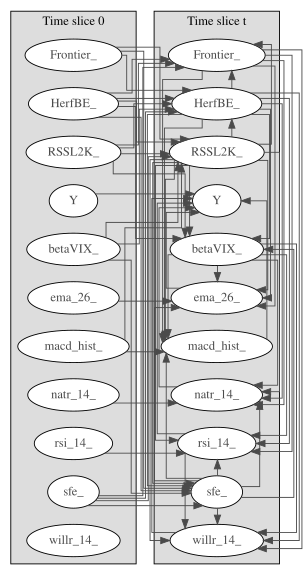

In [289]:
gdyn.showTimeSlices(twodbn, size="8")

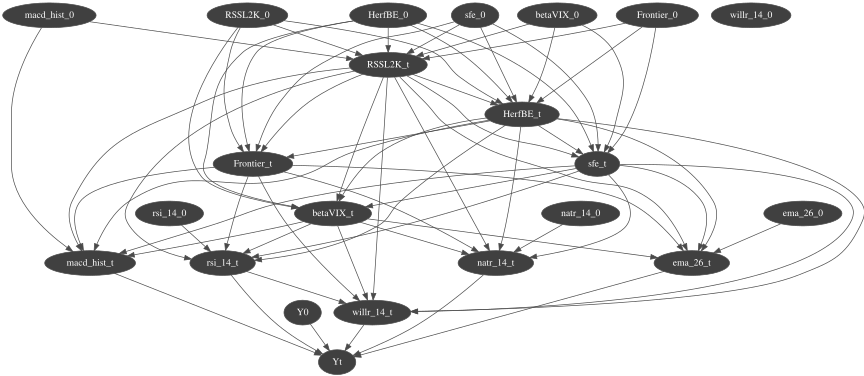

In [290]:
gnb.showBN(twodbn, size="12")

In [291]:
def sanity_check_unroll(twodbn, two_slice, OBSV, date=None, ticker=None):
    """
    Unroll DBN to T=2 and compute p(Y1=1) for a chosen date/ticker.
    """
    dates = two_slice.index.get_level_values("date").unique().sort_values()
    test_date = pd.Timestamp(date) if date is not None else dates[0]
    rows_t = two_slice.loc[(test_date, slice(None)), :]

    chosen_ticker = ticker or rows_t.index.get_level_values("ticker")[0]
    dbn_unrolled = gdyn.unroll2TBN(twodbn, 2)

    ev = {"Y0": int(rows_t.loc[(test_date, chosen_ticker), "Y0"])}
    for z in OBSV:
        ev[f"{z}_0"] = int(rows_t.loc[(test_date, chosen_ticker), f"{z}_0"])
        ev[f"{z}_1"] = int(rows_t.loc[(test_date, chosen_ticker), f"{z}_t"])

    ie = gum.LazyPropagation(dbn_unrolled)
    ie.setEvidence(ev)
    ie.makeInference()
    pY1 = float(ie.posterior("Y1")[1])

    print(f"Sanity: {chosen_ticker} on {test_date.date()} → p(Y1=1) = {pY1:.4f} (DBN unrolled)")
    return pY1

# for sanity check lets see the result of the posterior probability pY1 of the first asset
sanity_check_unroll(twodbn, two_slice, OBSV)

Sanity: A on 1992-01-31 → p(Y1=1) = 0.2413 (DBN unrolled)


0.24128061728025837


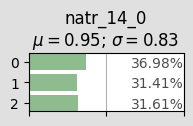
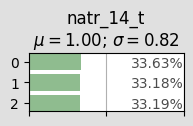
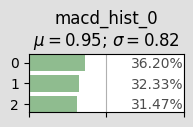
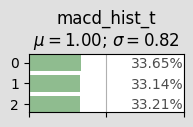
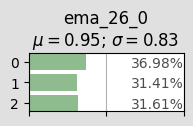
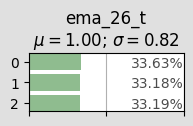
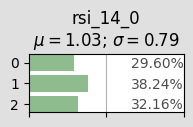
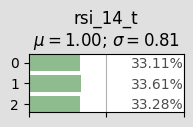
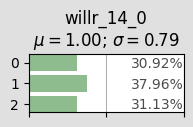
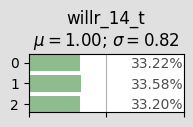
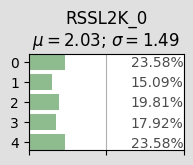
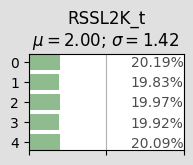
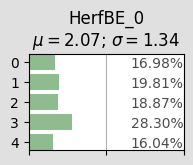
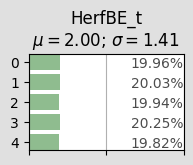
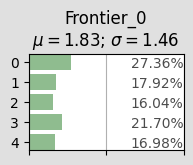
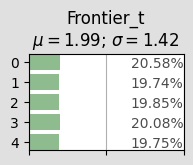
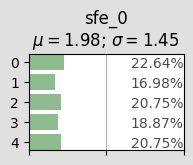
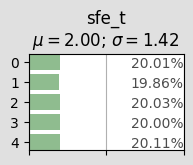
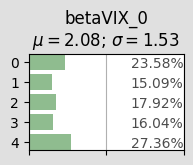
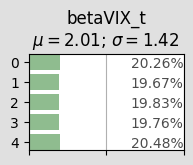
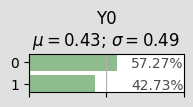
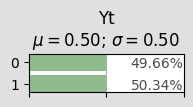

In [292]:
gnb.flow.clear()
for obs in OBSV_t:
  gnb.flow.add_html(gnb.getPosterior(twodbn, target=obs, evs={}), obs)
gnb.flow.display()

# 🧠 **Step 9: Decision Making using the Learnt DBN**

Calculate P(Y=1|features) for each stock at each decision date using the learnt DBN.

## Function: `score_cross_section_pY1`

Purpose
- Compute p(Yt=1 | parents) for all tickers at a given decision date.

Inputs
- bn: Learned BayesNet.
- two_slice_df: Two-slice data.
- date: Decision date.

Output
- Series pY1 indexed by tickers.

Procedure
- Identify Yt parents; pick available evidence columns from two_slice_df for that date.
- Run VariableElimination (fallback LazyPropagation) per row; collect posterior(Yt=1).
- Default to 0.5 if inference fails for a row.

Notes
- Uses only the columns that exist in the current two-slice build.

In [293]:



def score_cross_section_pY1(bn: gum.BayesNet, two_slice_df: pd.DataFrame, date) -> pd.Series:
    """
    Return a Series pY1 over tickers for the given decision date.
    """
    sub = two_slice_df[two_slice_df.index.get_level_values('date') == date]

    pids = list(bn.parents(bn.idFromName('Yt')))
    pnames = [bn.variable(pid).name() for pid in pids]

    BASES_0 = sorted({nm for nm in pnames if nm.endswith('_0')})
    BASES_t = sorted({nm for nm in pnames if nm.endswith('_t')})

    available_cols = set(sub.columns)
    has_Y0 = 'Y0' in pnames and 'Y0' in available_cols
    BASES_0_available = [feat for feat in BASES_0 if feat in available_cols]
    BASES_t_available = [feat for feat in BASES_t if feat in available_cols]

    try:
        ie = gum.VariableElimination(bn)
        engine_type = "VariableElimination"
    except:
        ie = gum.LazyPropagation(bn)
        engine_type = "LazyPropagation"

    idx1 = bn.variable('Yt').index('1')
    results = np.empty(len(sub))

    for i, row in enumerate(sub.itertuples(index=False)):
        ie.eraseAllEvidence()
        ev = {}

        if has_Y0:
            ev['Y0'] = int(row[sub.columns.get_loc('Y0')])

        for feat in BASES_0_available:
            ev[feat] = int(row[sub.columns.get_loc(feat)])

        for feat in BASES_t_available:
            ev[feat] = int(row[sub.columns.get_loc(feat)])

        try:
            ie.setEvidence(ev)
            ie.makeInference()
            post = ie.posterior('Yt')
            results[i] = float(post[idx1])
        except Exception:
            results[i] = 0.5

    # Use ticker level as index
    pY1 = pd.Series(results, index=sub.index.get_level_values('ticker'), name='pY1')
    return pY1

Calibration of predicted probabilities to expected returns will be done in the next step.

## Function: `calibrate_pY1_to_returns`

Purpose
- Learn a monotone mapping p(Y=1) → expected forward excess return using isotonic regression with recency weighting.

Inputs
- pY1: Series of probabilities (date×ticker MultiIndex or aligned index with returns).
- fwd_returns: Series/DataFrame of realized forward (excess) returns.
- recency_half_life_months: Exponential decay in months.

Output
- Callable f(p) → E[r_excess].

Procedure
- Align p and returns, build monthly-decay weights relative to latest date.
- If too few distinct p-values, return a constant-mean function.
- Fit IsotonicRegression(increasing=True, out_of_bounds='clip').
- Precompute a [0,1] grid and interpolate for fast calls.

Notes
- Works on excess returns (pass r − SPX).





In [294]:

def calibrate_pY1_to_returns(
    pY1: pd.Series,
    fwd_returns: pd.Series | pd.DataFrame,
    recency_half_life_months: float = 24.0,
):
    """
    monotone calibration:
    - aligns pY1 and returns
    - builds *monthly* recency weights
    - fits 1 isotonic regression
    - returns a callable f(p) -> E[r]

    Assumptions:
    - index has a datetime level (date) OR is a DatetimeIndex
    - data is monthly or close to monthly

    Parameters:
    - pY1: Series with pY1 values (index: MultiIndex (date,ticker) or Index)
    - fwd_returns: Series or DataFrame with forward returns (date x ticker)
    - recency_half_life_months: half-life for recency weighting
    Returns:
    - callable f(p) -> E[r]

    """
    # 1) normalize returns to Series
    if isinstance(fwd_returns, pd.DataFrame):
        # typical (date x ticker) forward-returns => stack
        r_ser = fwd_returns.stack()
    else:
        r_ser = fwd_returns

    p_ser = pY1.rename("p").astype(float)
    r_ser = r_ser.rename("r").astype(float)

    df = pd.concat([p_ser, r_ser], axis=1, join="inner").dropna()
    if df.empty:
        return lambda _: 0.0

    # 2) extract dates
    if isinstance(df.index, pd.MultiIndex):
        # try to find a datetime level called 'date'
        if "date" in df.index.names:
            dates = df.index.get_level_values("date")
        else:
            # assume first level is date
            dates = df.index.get_level_values(0)
    else:
        dates = df.index

    dates = pd.to_datetime(dates)
    t0 = dates.max()

    # months difference (works well for month-end)
    delta_months = (t0.year - dates.year) * 12 + (t0.month - dates.month)
    delta_months = delta_months.to_numpy()

    H = float(recency_half_life_months)
    # weight = 2^{ - age / H }
    w = np.power(2.0, -delta_months / H).astype(float)

    # 3) fit isotonic
    x = np.clip(df["p"].to_numpy(float), 0.0, 1.0)
    y = df["r"].to_numpy(float)

    # sanity: need at least a few distinct p's
    if np.unique(x).size < 5:
        m = float(np.average(y, weights=w))
        return lambda p: m if not pd.isna(p) else 0.0

    iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
    iso.fit(x, y, sample_weight=w)

    # optional: smooth to get nice values in between
    grid = np.linspace(0.0, 1.0, 201)
    yhat = iso.predict(grid)

    def f(p):
        if pd.isna(p):
            return 0.0
        p = float(np.clip(p, 0.0, 1.0))
        # linear interp on the precomputed grid
        return float(np.interp(p, grid, yhat))

    return f


A test example for the above function

In [295]:
# 36 months × 10 tickers = 360 points
dates = pd.date_range("2018-01-31", periods=36, freq="M")
tickers = [f"T{i:02d}" for i in range(10)]
idx = pd.MultiIndex.from_product([dates, tickers], names=["date", "ticker"])

# pY1: trending by ticker and a bit by time
p = []
for d in dates:
    base = np.random.uniform(0.2, 0.6)
    p.extend([base + 0.25, base + 0.20, base + 0.15, base + 0.10,
              base + 0.05, base,
              base - 0.05, base - 0.10, base - 0.15, base - 0.20])
pY1 = pd.Series(p, index=idx).clip(0, 1)

# returns positively related to pY1
alpha = 0.01
beta = 0.20
eps  = np.random.normal(0, 0.02, size=len(idx))
fwd  = alpha + beta * pY1.values + eps
fwd_ret = pd.Series(fwd, index=idx)

cal = calibrate_pY1_to_returns(
    pY1, fwd_ret,
    recency_half_life_months=24,
)

for x in [0.05, 0.2, 0.4, 0.6, 0.8, 0.95]:
    print(f"p={x:4.2f} -> {cal(x):.4f}")


p=0.05 -> 0.0129
p=0.20 -> 0.0479
p=0.40 -> 0.0927
p=0.60 -> 0.1300
p=0.80 -> 0.1698
p=0.95 -> 0.1939


In [296]:

def _extract_price_matrix(prices, tickers=None):
    """Extract plain ticker columns from MultiIndex prices"""
    pf = prices.copy()
    if isinstance(pf.columns, pd.MultiIndex):
        lvl1 = pf.columns.get_level_values(1)
        field = "Adj Close" if "Adj Close" in lvl1 else lvl1.unique()[0]
        pf = pf.loc[:, (slice(None), field)]
        pf.columns = pf.columns.droplevel(1)
    
    if tickers is not None:
        pf = pf.reindex(columns=pd.Index(tickers))
    return pf.apply(pd.to_numeric, errors="coerce")


def _compute_covariance(hist_prices, tickers, lookback_months, use_shrinkage=True):
    """
    Compute covariance matrix for a set of tickers.
    
    Parameters:
    -----------
    hist_prices : pd.DataFrame
        Price history (wide format with ticker columns)
    tickers : list-like
        Tickers to include
    lookback_months : int
        Number of periods to use
    use_shrinkage : bool
        If True, use Ledoit-Wolf; else use sample covariance
        
    Returns:
    --------
    pd.DataFrame or None
        Covariance matrix indexed/columned by tickers, or None if insufficient data
    """
    if hist_prices is None or len(tickers) == 0:
        return None
    
    hist_ret = (
        np.log(hist_prices[tickers])
        .diff()
        .iloc[-lookback_months:]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(how="all")
    )
    
    if hist_ret.shape[0] < max(len(tickers) + 1, 10):
        return None
    
    hist_clean = hist_ret.fillna(hist_ret.mean()).replace([np.inf, -np.inf], 0)
    
    try:
        if use_shrinkage:
            lw = LedoitWolf().fit(hist_clean)
            return pd.DataFrame(lw.covariance_, index=tickers, columns=tickers)
        else:
            return hist_ret.cov()
    except Exception:
        return hist_ret.cov()
    


def estimate_portfolio_variance(weights, cov_matrix, hist_prices, tickers, lookback_months):
    if weights.size == 0:
        return 1e-12
    w_vec = weights.reindex(tickers).fillna(0).values
    if cov_matrix is not None:
        try:
            return float(w_vec @ cov_matrix.values @ w_vec)
        except Exception:
            pass
    if hist_prices is not None and hist_prices.shape[0] > lookback_months:
        hist_ret = (
            np.log(hist_prices[tickers])
            .diff()
            .iloc[-lookback_months:]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        port_series = (hist_ret * w_vec).sum(axis=1)
        return float(port_series.var(ddof=1))
    return 1e-12

In [297]:
def calibrate_expected_returns(
    twodbn: gum.BayesNet,
    two_slice_df: pd.DataFrame,
    decision_date: pd.Timestamp,
    pY1_scores: pd.Series,
    prices_df: pd.DataFrame,
    benchmark_series: pd.Series,
    FWD: int = 3,
    macro_regime =macro_df_disc.loc[:, "VIX_regime"],
) -> tuple[pd.Series, dict, Callable[[float], float]]:
    """
    Calibrate pY1 scores to expected excess returns using only past data.
    """
    decision_date = pd.Timestamp(decision_date)
    all_dates = two_slice_df.index.get_level_values("date").unique().sort_values()
    cutoff_calib = decision_date - pd.offsets.MonthEnd(FWD)
    usable_calib_dates = [d for d in all_dates if d <= cutoff_calib]

    calib_debug = {
        "decision_date": decision_date,
        "FWD": int(FWD),
        "usable_calib_dates": usable_calib_dates,
        "n_usable_dates": len(usable_calib_dates),
        "pairs_total": 0,
        "pairs_used": 0,
        "mu_stats_before_ID": None,
        "regime_counts": None,
        "regime_current": None,
    }

    if len(usable_calib_dates) == 0:
        calibration_func = lambda p: float(p) if pd.notna(p) else 0.0
        expected_returns = pd.Series(
            [calibration_func(p) for p in pY1_scores],
            index=pY1_scores.index,
        )
        return expected_returns, calib_debug, calibration_func

    prices_clean = _extract_price_matrix(prices_df)
    fwd_px = compute_forward_returns(
        prices_clean, dates=usable_calib_dates, FWD=FWD, max_return_log=0.693
    )

    if benchmark_series is None:
        raise ValueError("benchmark_series required for excess-return calibration")

    benchmark_clean = (
        pd.to_numeric(benchmark_series, errors="coerce")
        .sort_index()
        .loc[lambda s: ~s.index.duplicated(keep="last")]
    )
    fwd_benchmark = compute_forward_returns(
        benchmark_clean.to_frame(name=benchmark_series.name),
        dates=usable_calib_dates,
        FWD=FWD,
    )[benchmark_series.name]

    fwd_excess = fwd_px.sub(fwd_benchmark, axis=0)

    regime_series = None
    if macro_regime is not None:
        regime_series = (
            pd.to_numeric(macro_regime, errors="coerce")
            .sort_index()
            .loc[lambda s: ~s.index.duplicated(keep="last")]
        )

        def _regime_for(ts: pd.Timestamp):
            if regime_series.loc[:ts].empty:
                return np.nan
            return regime_series.loc[:ts].iloc[-1]

    calib_frames = []

    for d_cal in usable_calib_dates:
        try:
            pY1_d = score_cross_section_pY1(twodbn, two_slice_df, d_cal)
            calib_debug["pairs_total"] += len(pY1_d)

            if d_cal not in fwd_excess.index:
                continue
            r_d = fwd_excess.loc[d_cal]

            common = pY1_d.index.intersection(r_d.index)
            calib_debug["pairs_used"] += len(common)

            if len(common) == 0:
                continue

            pY1_d_common = pY1_d.loc[common]
            r_d_common = r_d.loc[common]

            idx = pd.MultiIndex.from_product(
                [[d_cal], common], names=["date", "ticker"]
            )
            frame = pd.DataFrame(
                {"p": pY1_d_common.values, "r": r_d_common.values}, index=idx
            )

            if regime_series is not None:
                frame["regime"] = _regime_for(d_cal)

            calib_frames.append(frame)
        except Exception:
            continue

    if len(calib_frames) == 0:
        calibration_func = lambda p: float(p) if pd.notna(p) else 0.0
    else:
        calib_df = pd.concat(calib_frames)

        if "regime" in calib_df.columns:
            valid_reg = calib_df.dropna(subset=["regime"])
            if not valid_reg.empty:
                calib_debug["regime_counts"] = (
                    valid_reg["regime"].value_counts().to_dict()
                )
            if (
                "regime" in calib_df.columns
                and valid_reg["regime"].nunique() > 1
            ):
                iso_map = {}
                for reg, sub in valid_reg.groupby("regime"):
                    iso_map[reg] = calibrate_pY1_to_returns(sub["p"], sub["r"])

                if regime_series is not None and not regime_series.loc[:decision_date].empty:
                    reg_current = regime_series.loc[:decision_date].iloc[-1]
                else:
                    reg_current = None

                if reg_current not in iso_map:
                    reg_current = max(valid_reg["regime"].value_counts().items(), key=lambda x: x[1])[0]

                calib_debug["regime_current"] = reg_current
                calibration_func = iso_map[reg_current]
            else:
                calibration_func = calibrate_pY1_to_returns(
                    calib_df["p"], calib_df["r"]
                )
        else:
            calibration_func = calibrate_pY1_to_returns(
                calib_df["p"], calib_df["r"]
            )

    expected_returns = pd.Series(
        [calibration_func(p) for p in pY1_scores],
        index=pY1_scores.index,
    )

    if len(expected_returns) > 0:
        calib_debug["mu_stats_before_ID"] = (
            float(expected_returns.mean()),
            float(expected_returns.min()),
            float(expected_returns.max()),
        )

    return expected_returns, calib_debug, calibration_func


## Allocation Strategies

Some allocation strategies to convert expected returns into portfolio weights.

### Function: `allocate_MV_long_short`

Purpose
- Mean–variance optimizer for long-short baskets with per-name caps and shrinkage covariance.

Inputs
- pY1: Series of probabilities.
- basket_dict: {'long': Index, 'short': Index}.
- hist_prices: Price history (handles MultiIndex; extracts Adj Close).
- calibration_func: Optional p→E[r] mapping.
- lambda_risk: Risk aversion.
- max_weight_long/short: Per-name caps.
- lookback_months: Covariance window.
- use_shrinkage: Ledoit–Wolf if True.

Output
- Series of weights (positive long, negative short) summing to +1 long, -1 short.

Procedure
- Extract price matrix for combined basket; compute log returns; estimate covariance (shrinkage).
- Build expected returns from calibration_func (or pY1).
- Solve SLSQP maximizing μ − λ w'Σw with equality constraints on long/short sums and bounds per leg.
- Fallback to equal-weighted legs if insufficient data or failure.

Notes
- Returns market-neutral by construction (sum weights may be 0 net if equal legs).

In [298]:
def allocate_MV_long_short(
    pY1: pd.Series,
    basket_dict: Dict[str, pd.Index],
    hist_prices: Optional[pd.DataFrame],
    calibration_func: Optional[callable] = None,
    lambda_risk: float = 0.5,
    max_weight_long: float = 0.10,
    max_weight_short: float = 0.10,
    lookback_months: int = 36,
    use_shrinkage: bool = True,
    prev_weights: Optional[pd.Series] = None,
    gamma_tc: float = 0.0,
    turnover_mode: str = 'gross',
) -> pd.Series:
    """
    Mean–variance allocator with separate long/short legs and L1 turnover penalty.
    """
    longs = basket_dict.get('long', pd.Index([]))
    shorts = basket_dict.get('short', pd.Index([]))
    combined = pd.Index(list(longs) + list(shorts))
    if combined.empty:
        return pd.Series(dtype=float)

    px = _extract_price_matrix(hist_prices, tickers=combined)

    # Expected returns vector
    exp_returns = []
    for t in combined:
        p = float(pY1.get(t, np.nan))
        mu = calibration_func(p) if callable(calibration_func) else (p if np.isfinite(p) else 0.0)
        exp_returns.append(mu)
    exp_returns = np.asarray(exp_returns, dtype=float)

    # Covariance matrix
    cov_df = _compute_covariance(px, combined, lookback_months, use_shrinkage)
    
    if cov_df is not None:
        cov = cov_df.values  # Extract numpy array
    else:
        # Fallback to identity if insufficient data
        cov = np.eye(len(combined)) * 1e-6

    # (bounds, constraints, optimization)
    nL, nS = len(longs), len(shorts)
    bounds = [ (0.0, max_weight_long) if t in longs else (-max_weight_short, 0.0) for t in combined ]
    def constr_long(w): return np.sum(w[:nL]) - (1.0 if nL > 0 else 0.0)
    def constr_short(w): return np.sum(w[nL:]) + (1.0 if nS > 0 else 0.0)
    cons = [{'type': 'eq', 'fun': constr_long}]
    if nS > 0:
        cons.append({'type': 'eq', 'fun': constr_short})

    if isinstance(prev_weights, pd.Series) and not prev_weights.empty:
        w_prev = prev_weights.reindex(combined).fillna(0.0).values.astype(float)
    else:
        w_prev = np.zeros(len(combined), dtype=float)

    def neg_util(w):
        w = np.asarray(w, dtype=float)
        mu = float(w @ exp_returns)
        var = float(w @ cov @ w)
        l1 = np.sum(np.abs(w - w_prev))
        if turnover_mode == 'net':
            l1 *= 0.5
        return -(mu - lambda_risk * var - gamma_tc * l1)

    w0 = np.zeros(len(combined), dtype=float)
    if nL > 0:
        w0[:nL] = 1.0 / nL
    if nS > 0:
        w0[nL:] = -1.0 / nS

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            res = minimize(neg_util, w0, method='SLSQP', bounds=bounds, constraints=cons, options={'maxiter': 500, 'ftol': 1e-9})
    except Exception:
        res = None

    w = w0 if (res is None or not res.success) else res.x
    return pd.Series(w, index=combined, name='w')

### Function: `allocate_kelly_long_short`

Purpose
- Kelly-style sizing for long-short baskets using variance scaling and optional half-Kelly.

Inputs
- pY1, basket_dict, hist_prices.
- calibration_func: Optional mapping p→E[r].
- lookback_months, max_weight_long/short, half_kelly.

Output
- Series of weights per ticker.

Procedure
- Compute per-name expected returns (calibrated) and variances over lookback window.
- Kelly fraction ≈ μ/σ² (optionally halved).
- Split into long positives and short negatives, normalize each leg to +1 and −1 with caps.

Notes
- Fallback to equal weights when data insufficient.

In [299]:
def allocate_kelly_long_short(pY1, basket_dict, hist_prices,
                               calibration_func=None,             # NEW
                               lookback_months=36,
                               max_weight_long=0.10,
                               max_weight_short=0.10,
                               half_kelly=True):
    # Handle MultiIndex input (extract 'Adj Close' level)
    if isinstance(hist_prices.columns, pd.MultiIndex):
        hist_prices = hist_prices.xs('Adj Close', axis=1, level=1)

    long_basket = basket_dict['long']
    short_basket = basket_dict['short']
    combined_basket = long_basket.append(short_basket)

    n_long = len(long_basket)
    n_short = len(short_basket)

    if hist_prices is None or len(hist_prices) < 3 or (n_long + n_short) == 0:
        w0_long = np.ones(n_long) / n_long if n_long > 0 else np.array([])
        w0_short = -np.ones(n_short) / n_short if n_short > 0 else np.array([])
        return pd.Series(np.concatenate([w0_long, w0_short]) if n_short > 0 else w0_long,
                         index=combined_basket, name='w')

    lookback_data = (
        np.log(hist_prices[combined_basket])
        .diff()
        .iloc[-lookback_months:]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(how='all')
    )
    
    lookback_data = lookback_data.replace([np.inf, -np.inf], np.nan).dropna(how='all')
    if lookback_data.empty:
        w0_long = np.ones(n_long) / n_long if n_long > 0 else np.array([])
        w0_short = -np.ones(n_short) / n_short if n_short > 0 else np.array([])
        return pd.Series(np.concatenate([w0_long, w0_short]) if n_short > 0 else w0_long,
                         index=combined_basket, name='w')

    # Use calibrated expected EXCESS returns
    if calibration_func is not None:
        exp_returns = np.array([calibration_func(p) for p in pY1[combined_basket]])
    else:
        # fallback: centered pY1 as proxy
        exp_returns = (pY1[combined_basket].values - 0.5) * 2.0

    variances = lookback_data.var().reindex(combined_basket).fillna(lookback_data.var().mean()).values
    variances = np.maximum(variances, 1e-6)

    kelly_raw = exp_returns / variances
    if half_kelly:
        kelly_raw *= 0.5

    k_long = np.maximum(kelly_raw[:n_long], 0)
    k_short = np.minimum(kelly_raw[n_long:], 0) if n_short > 0 else np.array([])

    # Normalize and cap
    k_long = k_long if k_long.sum() > 0 else np.ones(n_long)
    k_long = k_long / k_long.sum()
    k_long = np.minimum(k_long, max_weight_long)
    k_long = k_long / k_long.sum()

    if n_short > 0:
        k_short = k_short if k_short.sum() < 0 else -np.ones(n_short)
        k_short = k_short / abs(k_short.sum())
        k_short = np.maximum(k_short, -max_weight_short)
        k_short = k_short / abs(k_short.sum())

    weights = np.concatenate([k_long, k_short]) if n_short > 0 else k_long
    return pd.Series(weights, index=combined_basket, name='w')




### Function: `allocate_pY1_weighted_long_short`

Purpose
- Heuristic magnitude-weighting by |E[r]|^power with per-name caps for long and short legs.

Inputs
- pY1, basket_dict.
- calibration_func: Optional mapping p→E[r].
- power: Exponent on magnitude.
- max_weight_long/short.

Output
- Series of weights per ticker.

Procedure
- Map pY1 to expected returns; take absolute magnitude to define scores.
- Normalize separately across long and short legs; apply caps and renormalize; assign negative sign to short weights.

Notes
- Simple and robust alternative to optimization.

In [300]:
def allocate_pY1_weighted_long_short(pY1, basket_dict, power=1.0,
                                     calibration_func=None,              # NEW
                                     max_weight_long=0.10,
                                     max_weight_short=0.10):
    long_basket = basket_dict['long']
    short_basket = basket_dict['short']
    combined_basket = long_basket.append(short_basket)

    if calibration_func is not None:
        exp = np.array([calibration_func(p) for p in pY1[combined_basket]])
    else:
        exp = (pY1[combined_basket].values - 0.5) * 2.0  # fallback

    # magnitude weights proportional to |E[r]|^power
    mag = np.abs(exp) ** power
    n_long, n_short = len(long_basket), len(short_basket)

    # split and sign
    mag_long = mag[:n_long]
    mag_short = mag[n_long:]

    # normalize longs
    w_long = mag_long / mag_long.sum() if mag_long.sum() > 0 else np.ones(n_long) / max(1, n_long)
    w_long = np.minimum(w_long, max_weight_long)
    w_long = w_long / w_long.sum() if w_long.sum() > 0 else w_long

    # normalize shorts
    if n_short > 0:
        w_short = mag_short / mag_short.sum() if mag_short.sum() > 0 else np.ones(n_short) / n_short
        w_short = -w_short
        w_short = np.maximum(w_short, -max_weight_short)
        w_short = w_short / abs(w_short.sum()) if abs(w_short.sum()) > 0 else w_short
        weights = np.concatenate([w_long, w_short])
    else:
        weights = w_long

    return pd.Series(weights, index=combined_basket, name='w')


### Function: `select_basket_long_short`

Purpose
- Build long and short baskets from pY1 scores under different selection policies.

Inputs
- pY1: Series of probabilities.
- policy: 'TopK', 'TopK_hiCut', or 'Symmetric'.
- K_long, K_short: Desired counts.

Output
- dict {'long': Index, 'short': Index}.

Procedure
- Sort pY1 descending.
- TopK: pick top K_long and bottom K_short.
- TopK_hiCut: use 75th/25th percentiles if enough names; else fallback to TopK.
- Symmetric: use thresholds pY1>0.6 for longs and pY1<0.4 for shorts, with fallback to fill K.

Notes
- Ensures minimum sizes via fallback.

In [301]:
def select_basket_long_short(
    pY1: pd.Series,
    policy: str,
    K_long: int = 30,
    K_short: int = 30,
    prev_weights: Optional[pd.Series] = None,
    overlap_keep: float = 0.6,
) -> dict:
    """
    Build long/short baskets from pY1 scores.

    Supported policies: 'TopK', 'TopK_inertia', 'Symmetric'
    - TopK: pick top K_long and bottom K_short by pY1
    - TopK_inertia: keep ~overlap_keep fraction of previous names (by sign), fill rest by current ranks
    - Symmetric: threshold-based (0.6/0.4) with fallbacks to meet K sizes
    """
    s = pY1.dropna().sort_values(ascending=False)
    longs = pd.Index([])
    shorts = pd.Index([])

    def _fill_topk(K: int) -> pd.Index:
        return s.index[:K]

    def _fill_bottomk(K: int) -> pd.Index:
        return s.index[-K:]

    if policy == 'TopKInertia':
        if K_long > 0:
            keep = int(round(K_long * overlap_keep))
            kept = []
            if isinstance(prev_weights, pd.Series) and not prev_weights.empty:
                prev_longs = prev_weights[prev_weights > 0].index.tolist()
                kept = [t for t in prev_longs if t in s.index][:keep]
            need = max(0, K_long - len(kept))
            add = [t for t in s.index if t not in kept][:need]
            longs = pd.Index(kept + add)
        if K_short > 0:
            keep = int(round(K_short * overlap_keep))
            kept = []
            if isinstance(prev_weights, pd.Series) and not prev_weights.empty:
                prev_shorts = prev_weights[prev_weights < 0].index.tolist()
                kept = [t for t in prev_shorts if t in s.index][:keep]
            need = max(0, K_short - len(kept))
            add = [t for t in s.index[::-1] if t not in kept][:need]
            shorts = pd.Index(kept + add)
    elif policy == 'TopK':
        longs = _fill_topk(K_long) if K_long > 0 else pd.Index([])
        shorts = _fill_bottomk(K_short) if K_short > 0 else pd.Index([])
    elif policy == 'Symmetric':
        hi = s[s > 0.6].index if K_long > 0 else pd.Index([])
        lo = s[s < 0.4].index if K_short > 0 else pd.Index([])
        if len(hi) < K_long:
            extra = [t for t in s.index if t not in hi][:K_long - len(hi)]
            hi = pd.Index(hi.tolist() + extra)
        if len(lo) < K_short:
            extra = [t for t in s.index[::-1] if t not in lo][:K_short - len(lo)]
            lo = pd.Index(lo.tolist() + extra)
        # Cap to K and order: longs by highest pY1, shorts by lowest pY1
        longs = pd.Index(s.loc[hi].index[:K_long])
        shorts = pd.Index(s.loc[lo].sort_values(ascending=True).index[:K_short])
    else:
        longs = _fill_topk(K_long) if K_long > 0 else pd.Index([])
        shorts = _fill_bottomk(K_short) if K_short > 0 else pd.Index([])
    
    shorts = shorts.difference(longs)

    return {"long": longs, "short": shorts}

# 📊 **Step 10: Influence Diagram from DBN**


## Function: `build_influence_diagram_from_dbn_dynamic`

Purpose
- Construct and parameterize a dynamic Influence Diagram (ID) for a specific decision date using the learned DBN, calibrated expected returns, and risk/turnover modeling.

Inputs
- twodbn, two_slice_df, decision_date, prices_df.
- actions_select: e.g., ['TopK_LongOnly','TopK_LongShort','Symmetric_LS'].
- actions_alloc: e.g., ['allocate_MV','allocate_kelly','allocate_pY1_weighted','keep_prev'].
- K_long, K_short, FWD, lookback_months, lambda_risk.
- pY1_scores: Optional precomputed p(Yt=1).
- benchmark_series: Continuous benchmark series for excess-return calibration.
- prev_weights: Prior period weights.
- gamma_turnover: Per-unit turnover utility penalty (e.g., cost_bps/10000).
- turnover_mode: 'gross' or 'net'.

Outputs
- InfluenceDiagram ID.
- mu_mat, var_mat: matrices of portfolio mean and variance per (selection, allocation).
- calib_debug: diagnostics dict.
- calibration_func: fitted p→E[r] map used.

Procedure
- Copy DBN structure, arcs, CPTs into an ID chance subgraph.
- Add decision nodes D_select and D_alloc; connect info arcs from Yt parents → D_select and D_select → D_alloc.
- Score pY1 at decision_date (or use given).
- Calibrate p→E[r_excess] using only dates ≤ decision_date−FWD (no look-ahead); build expected per-name returns.
- For each (selection, allocation):
  - Build long/short basket; compute weights by allocator.
  - Estimate μ (dot of weights and expected returns) and σ² (portfolio variance via shrinkage over lookback).
  - Estimate expected turnover vs prev_weights.
- Create chance node R_port (forward portfolio return bin) and parameterize P(R_port | D_select, D_alloc) assuming Normal(μ, σ²) and fixed bins.
- Add utility node U with u(r)=r−λ r² and subtract turnover penalty γ·turnover per policy pair.
- Return ID and matrices for downstream analysis/solving.

Notes
- Ensures calibration uses only realized-forward windows by the decision date.

In [302]:
def build_influence_diagram_from_dbn_dynamic(
    twodbn: gum.BayesNet,
    two_slice_df: pd.DataFrame,
    actions_select: list[str],
    actions_alloc: list[str],
    decision_date,
    prices_df: pd.DataFrame,
    K_long: int = 20,
    K_short: int = 10,
    FWD: int = 3,
    lookback_months: int = 36,
    lambda_risk: float = 0.5,
    pY1_scores: pd.Series = None,
    benchmark_series: pd.Series | None = None,
    prev_weights: pd.Series | None = None,
    gamma_turnover: float = 0.0,
    turnover_mode: str = "gross",
    overlap_keep: float = 0.7,
    min_history_obs: int = 12, # min required obs for cov calculation
):
    """
    Build dynamic influence diagram with precomputed baskets and covariance matrices.

    Key optimizations:
    - Precompute baskets for all selection policies once
    - Cache covariance matrices per basket
    - Separate calibration, basket selection, and allocation logic
    - Evaluate inertia/keep-prev policies with the exact holdings they will deploy
    """

    # ========================================================================
    # SECTION 0: Helper Functions (extracted from nested code)
    # ========================================================================

    # Snapshot previous holdings once so inertia/keep-prev actions use consistent data
    if isinstance(prev_weights, pd.Series):
        prev_weights = prev_weights.dropna()
    prev_hist_prices = (
        _extract_price_matrix(prices_df, tickers=prev_weights.index)
        if isinstance(prev_weights, pd.Series) and not prev_weights.empty
        else None
    )
    prev_cov = (
        _compute_covariance(prev_hist_prices, prev_weights.index, lookback_months)
        if prev_hist_prices is not None and prev_weights is not None and not prev_weights.empty
        else None
    )

    # ========================================================================
    # SECTION 1: Initialize Influence Diagram (copy DBN structure)
    # ========================================================================

    ID = gum.InfluenceDiagram()

    for node_name in twodbn.names():
        v_bn = twodbn.variable(node_name)
        v_id = gum.LabelizedVariable(v_bn.name(), v_bn.description(), v_bn.domainSize())
        for k in range(v_bn.domainSize()):
            v_id.changeLabel(k, v_bn.label(k))
        ID.addChanceNode(v_id)

    for arc in twodbn.arcs():
        src, dst = twodbn.variable(arc[0]).name(), twodbn.variable(arc[1]).name()
        if src in ID.names() and dst in ID.names():
            ID.addArc(src, dst)

    for node_name in twodbn.names():
        cpt_bn = twodbn.cpt(node_name)
        cpt_id = ID.cpt(node_name)
        vars_bn = [v.name() for v in cpt_bn.variablesSequence()]
        vars_id = [v.name() for v in cpt_id.variablesSequence()]
        if vars_bn == vars_id:
            cpt_id[:] = cpt_bn.toarray()
        else:
            I_bn, I_id = gum.Instantiation(cpt_bn), gum.Instantiation(cpt_id)
            I_bn.setFirst()
            while not I_bn.end():
                for var in vars_bn:
                    I_id.chgVal(var, I_bn.val(var))
                cpt_id.set(I_id, cpt_bn.get(I_bn))
                I_bn.inc()

    v_select = gum.LabelizedVariable("D_select", "Asset selection", len(actions_select))
    for i, a in enumerate(actions_select):
        v_select.changeLabel(i, a)
    ID.addDecisionNode(v_select)

    v_alloc = gum.LabelizedVariable("D_alloc", "Allocation", len(actions_alloc))
    for j, a in enumerate(actions_alloc):
        v_alloc.changeLabel(j, a)
    ID.addDecisionNode(v_alloc)

    try:
        y_parents = [twodbn.variable(pid).name() for pid in twodbn.parents(twodbn.idFromName("Yt"))]
    except Exception:
        y_parents = []

    for n in y_parents:
        if n in ID.names():
            ID.addArc(n, "D_select")
    ID.addArc("D_select", "D_alloc")

    # ========================================================================
    # SECTION 2: Calibration (pY1 → Expected Returns)
    # ========================================================================

    if pY1_scores is None:
        pY1_scores = score_cross_section_pY1(twodbn, two_slice_df, pd.Timestamp(decision_date))
        
    # Filter tickers with insufficient history for covariance calculation
    try:
        dt = pd.Timestamp(decision_date)
        px_all = _extract_price_matrix(prices_df, tickers=pY1_scores.index)
        hist = px_all.loc[:dt]
        # Use up to lookback_months+1 rows for stability; if fewer exist, use what's available
        if len(hist) > 1:
            hist = hist.tail(lookback_months + 1)
            rets = np.log(hist).diff().replace([np.inf, -np.inf], np.nan)
            counts = rets.count()
            eligible = counts[counts >= int(min_history_obs)].index
            dropped = pY1_scores.index.difference(eligible)
            if len(dropped) > 0:
                print(f"    Removing {len(dropped)} tickers (insufficient history for cov): {', '.join(map(str, dropped[:5]))}{'...' if len(dropped)>5 else ''}")
            pY1_scores = pY1_scores.loc[pY1_scores.index.intersection(eligible)]
    except Exception as e:
        print(f"    Warning: Could not filter tickers by history length due to error: {e}") 
        pass

    expected_returns, calib_debug, calibration_func = calibrate_expected_returns(
        twodbn=twodbn,
        two_slice_df=two_slice_df,
        decision_date=decision_date,
        pY1_scores=pY1_scores,
        prices_df=prices_df,
        benchmark_series=benchmark_series,
        FWD=FWD,
    )

    # ========================================================================
    # SECTION 3: PRECOMPUTE BASKETS
    # ========================================================================

    baskets = {}
    for i_sel, sel_action in enumerate(actions_select):
        wants_short = any(flag in sel_action for flag in ["LongShort", "_LS"])
        policy_name = sel_action.split("_")[0]

        basket_dict = select_basket_long_short(
            pY1_scores,
            policy=policy_name,
            K_long=K_long,
            K_short=K_short if wants_short else 0,
            prev_weights=prev_weights,
            overlap_keep=overlap_keep,
        )

        combined = pd.Index(list(basket_dict.get("long", pd.Index([]))) + list(basket_dict.get("short", pd.Index([]))))
        baskets[i_sel] = {
            "long": basket_dict.get("long", pd.Index([])),
            "short": basket_dict.get("short", pd.Index([])),
            "combined": combined,
        }

        if wants_short and len(basket_dict.get("short", [])) == 0:
            print(
                f"⚠️  Empty short leg for '{sel_action}' at {pd.Timestamp(decision_date).date()}"
            )

    # ========================================================================
    # SECTION 4: PRECOMPUTE COVARIANCE MATRICES
    # ========================================================================

    cov_cache = {}
    price_cache = {}
    for i_sel, basket in baskets.items():
        if basket["combined"].empty:
            cov_cache[i_sel] = None
            price_cache[i_sel] = None
        else:
            hist_prices_subset = _extract_price_matrix(prices_df, tickers=basket["combined"])
            price_cache[i_sel] = hist_prices_subset
            cov_cache[i_sel] = _compute_covariance(hist_prices_subset, basket["combined"], lookback_months)

    # ========================================================================
    # SECTION 5: COMPUTE μ/var MATRICES
    # ========================================================================

    n_sel, n_alloc = len(actions_select), len(actions_alloc)
    mu_mat = np.zeros((n_sel, n_alloc))
    var_mat = np.zeros((n_sel, n_alloc))
    turnover_mat = np.zeros((n_sel, n_alloc))

    def _evaluate_policy(
        weights: pd.Series,
        ticker_index: pd.Index,
        cov_matrix,
        hist_prices,
    ) -> tuple[float, float]:
        if weights is None or len(ticker_index) == 0:
            return 0.0, 1e-12
        w_aligned = weights.reindex(ticker_index, fill_value=0.0)
        if w_aligned.abs().sum() == 0:
            return 0.0, 1e-12
        mu_vec = expected_returns.reindex(ticker_index, fill_value=0.0).values
        mu_val = float(np.dot(w_aligned.values, mu_vec))
        monthly_var = estimate_portfolio_variance(
            w_aligned,
            cov_matrix,
            hist_prices,
            ticker_index,
            lookback_months,
        )
        var_val = max(float(FWD) * monthly_var, 1e-12)
        return mu_val, var_val

    for i_sel, basket in baskets.items():
        combined = basket["combined"]
        hist_prices_subset = price_cache[i_sel]

        alloc_dispatch = {
            "allocate_MV": lambda: allocate_MV_long_short(
                pY1_scores,
                basket,
                hist_prices_subset,
                calibration_func,
                lambda_risk,
                lookback_months=lookback_months,
            ),
            "allocate_kelly": lambda: allocate_kelly_long_short(
                pY1_scores,
                basket,
                hist_prices_subset,
                calibration_func,
                lookback_months=lookback_months,
            ),
            "allocate_pY1_weighted": lambda: allocate_pY1_weighted_long_short(
                pY1_scores,
                basket,
                calibration_func=calibration_func,
            ),
        }


        for j_alloc, alloc_action in enumerate(actions_alloc):
            if alloc_action == "keep_prev":
                if prev_weights is None or prev_weights.empty:
                    if len(combined) > 0:
                        weights = pd.Series(np.full(len(combined), 1 / len(combined)), index=combined)
                        eval_index = combined
                        cov_matrix = cov_cache[i_sel]
                        hist_px = hist_prices_subset
                    else:
                        weights = pd.Series(dtype=float)
                        eval_index = combined
                        cov_matrix = cov_cache[i_sel]
                        hist_px = hist_prices_subset
                else:
                    weights = prev_weights.copy()
                    eval_index = weights.index
                    cov_matrix = prev_cov
                    hist_px = prev_hist_prices
                turnover_mat[i_sel, j_alloc] = 0.0
            else:
                try:
                    weights = alloc_dispatch.get(alloc_action, lambda: None)()
                except Exception:
                    weights = None
                if weights is None or (isinstance(weights, pd.Series) and weights.empty):
                    nL, nS = len(basket["long"]), len(basket["short"])
                    wL = np.full(nL, 1 / nL) if nL else np.array([])
                    wS = -np.full(nS, 1 / nS) if nS else np.array([])
                    weights = (
                        pd.Series(np.concatenate([wL, wS]), index=combined)
                        if nS
                        else pd.Series(wL, index=combined)
                    )
                if not isinstance(weights, pd.Series):
                    weights = pd.Series(weights, index=combined)
                eval_index = combined
                cov_matrix = cov_cache[i_sel]
                hist_px = hist_prices_subset

                if (
                    isinstance(prev_weights, pd.Series)
                    and not prev_weights.empty
                    and not weights.empty
                ):
                    turnover_mat[i_sel, j_alloc] = compute_turnover(
                        weights, prev_weights, mode=turnover_mode
                    )

            mu_mat[i_sel, j_alloc], var_mat[i_sel, j_alloc] = _evaluate_policy(
                weights,
                eval_index,
                cov_matrix,
                hist_px,
            )

    for i_sel, sel in enumerate(actions_select):
        mus = [mu_mat[i_sel, j] for j in range(len(actions_alloc))]
        print(f"[CHECK] μ spread for {sel}: range={np.max(mus) - np.min(mus):.6g}")

    # ========================================================================
    # SECTION 6: Create R_port and its CPT
    # ========================================================================

    bin_edges = np.array([-np.inf, -0.05, 0.0, 0.02, 0.05, np.inf])
    bin_labels = [
        "big_loss(≤ -5%)",
        "down(-5..0%)",
        "flat(0..2%)",
        "up(2..5%)",
        "strong(>5%)",
    ]
    n_bins = len(bin_labels)

    v_rport = gum.LabelizedVariable("R_port", "Portfolio fwd return bin", n_bins)
    for k, lab in enumerate(bin_labels):
        v_rport.changeLabel(k, lab)
    ID.addChanceNode(v_rport)
    ID.addArc("D_select", "R_port")
    ID.addArc("D_alloc", "R_port")

    def _prob_vector_from_normal(mu_val, var_val, edges):
        sd = np.sqrt(var_val)
        if sd < 1e-8:
            k_star = int(np.digitize(mu_val, edges[1:-1], right=False))
            p = np.zeros(len(edges) - 1)
            p[k_star] = 1.0
            return p
        z = (edges - mu_val) / sd
        cdf_vals = norm.cdf(z)
        probs = np.diff(cdf_vals)
        probs = np.maximum(probs, 0.0)
        return probs / probs.sum() if probs.sum() > 0 else np.ones(len(edges) - 1) / (len(edges) - 1)

    prob_tensors = {
        (i, j): _prob_vector_from_normal(mu_mat[i, j], var_mat[i, j], bin_edges)
        for i in range(n_sel)
        for j in range(n_alloc)
    }

    cpt_rp = ID.cpt("R_port")
    inst = gum.Instantiation(cpt_rp)
    inst.setFirst()
    while not inst.end():
        cpt_rp.set(
            inst,
            prob_tensors[(inst.val("D_select"), inst.val("D_alloc"))][inst.val("R_port")],
        )
        inst.inc()

    row_sum_min = +np.inf
    row_sum_max = -np.inf
    for key, vec in prob_tensors.items():
        s = vec.sum()
        row_sum_min = min(row_sum_min, s)
        row_sum_max = max(row_sum_max, s)
    print(
        f"[DEBUG] CPT(R_port|D.*,D.*) row-sum range: "
        f"[{row_sum_min:.6f}, {row_sum_max:.6f}]"
    )

    v_util = gum.LabelizedVariable("U", "Utility", 1)
    ID.addUtilityNode(v_util)
    ID.addArc("R_port", "U")
    ID.addArc("D_select", "U")
    ID.addArc("D_alloc", "U")

    util_tab = ID.utility("U")
    mids = []
    for k in range(n_bins):
        lo = bin_edges[k]
        hi = bin_edges[k + 1]
        if np.isneginf(lo):
            mid = hi - 0.05
        elif np.isinf(hi):
            mid = lo + 0.05
        else:
            mid = 0.5 * (lo + hi)
        mids.append(mid)
    mids = np.array(mids, dtype=float)
    util_vals = mids - lambda_risk * (mids ** 2)

    instU = gum.Instantiation(util_tab)
    instU.setFirst()
    while not instU.end():
        r_state = instU.val("R_port")
        i_state = instU.val("D_select")
        j_state = instU.val("D_alloc")
        pen = float(gamma_turnover) * float(turnover_mat[i_state, j_state])
        util_tab.set(instU, float(util_vals[r_state] - pen))
        instU.inc()

    print(f"[DEBUG] Turnover penalty gamma={gamma_turnover:.6f} mode={turnover_mode}")

    calib_debug["turnover_mat"] = turnover_mat
    calib_debug["gamma_turnover"] = float(gamma_turnover)
    calib_debug["turnover_mode"] = turnover_mode

    print("=== DEBUG: mu/var by (D_select,D_alloc) ===")
    for i_sel, sel_action in enumerate(actions_select):
        row_mu = ", ".join([f"{mu_mat[i_sel, j]: .6f}" for j in range(n_alloc)])
        row_var = ", ".join([f"{var_mat[i_sel, j]: .6f}" for j in range(n_alloc)])
        print(f"  {sel_action:<18}  mu: [{row_mu}]")
        print(f"  {sel_action:<18} var: [{row_var}]")

    if calib_debug["mu_stats_before_ID"] is not None:
        mean_mu, min_mu, max_mu = calib_debug["mu_stats_before_ID"]
        print(
            f"=== DEBUG: calibrated E[ri | pY1] stats at {pd.Timestamp(decision_date).date()} ==="
        )
        print(
            f"  n_tickers: {len(expected_returns)}, "
            f"mean={mean_mu:.6f}, min={min_mu:.6f}, max={max_mu:.6f}"
        )

    usable_dates = calib_debug.get("usable_calib_dates", [])
    print(f"=== DEBUG: calibration dates used (<= dt - {FWD}m) ===")
    print(
        f"  count={calib_debug['n_usable_dates']}, "
        f"pairs_total={calib_debug['pairs_total']}, "
        f"pairs_used={calib_debug['pairs_used']}"
    )
    if usable_dates:
        print(
            f"  window: {min(usable_dates).date()} "
            f"→ {max(usable_dates).date()}"
        )
    
    # diagnose_covariance_inputs(baskets, price_cache, lookback_months=lookback_months)


    return ID, mu_mat, var_mat, calib_debug, calibration_func


In [303]:
# ============================================================================
# Build ID for a specific decision date
# ============================================================================


available_dates_in_two_slice = two_slice.index.get_level_values('date').unique().sort_values()
test_date = available_dates_in_two_slice[10]  # Use 11th date from two_slice

print(f"\n{'='*80}")
print(f"BUILDING INFLUENCE DIAGRAM FOR DATE: {test_date.date()}")
print(f"{'='*80}")

# Define action spaces
actions_select = [
    "TopK_LongOnly",      # 20 long, 0 short
    "TopK_LongShort",     # 20 long, 10 short
    "Symmetric_LS", 
    "TopKInertia_LongShort"        # pY1-based thresholds
]

actions_alloc = [
    'allocate_MV',
    'allocate_kelly',
    'allocate_pY1_weighted',
    'keep_prev'
]

# Build ID with long-short support
ID, mu_mat, var_mat, calib_debug, calibration_func = build_influence_diagram_from_dbn_dynamic(
    twodbn=twodbn,
    two_slice_df=two_slice,
    actions_select=actions_select,
    actions_alloc=actions_alloc,
    decision_date=test_date,
    prices_df=prices_train,
    K_long=20,
    K_short=10,
    FWD=3,
    benchmark_series=macro_train["SPX"]  # REQUIRED for excess returns
)



BUILDING INFLUENCE DIAGRAM FOR DATE: 1994-07-31
    Removing 230 tickers (insufficient history for cov): A, ABBV, ABNB, ACGL, ACN...
[CHECK] μ spread for TopK_LongOnly: range=0.0135358
[CHECK] μ spread for TopK_LongShort: range=0.0440801
[CHECK] μ spread for Symmetric_LS: range=0.0440801
[CHECK] μ spread for TopKInertia_LongShort: range=0.0440801
[DEBUG] CPT(R_port|D.*,D.*) row-sum range: [1.000000, 1.000000]
[DEBUG] Turnover penalty gamma=0.000000 mode=gross
=== DEBUG: mu/var by (D_select,D_alloc) ===
  TopK_LongOnly       mu: [ 0.060330,  0.057646,  0.058511,  0.046794]
  TopK_LongOnly      var: [ 0.002119,  0.002536,  0.002761,  0.002449]
  TopK_LongShort      mu: [ 0.071540,  0.068856,  0.069721,  0.027459]
  TopK_LongShort     var: [ 0.000967,  0.000952,  0.001064,  0.002184]
  Symmetric_LS        mu: [ 0.071540,  0.068856,  0.069721,  0.027459]
  Symmetric_LS       var: [ 0.001063,  0.001083,  0.001192,  0.002161]
  TopKInertia_LongShort  mu: [ 0.071540,  0.068856,  0.069721,  0


INFLUENCE DIAGRAM STRUCTURE


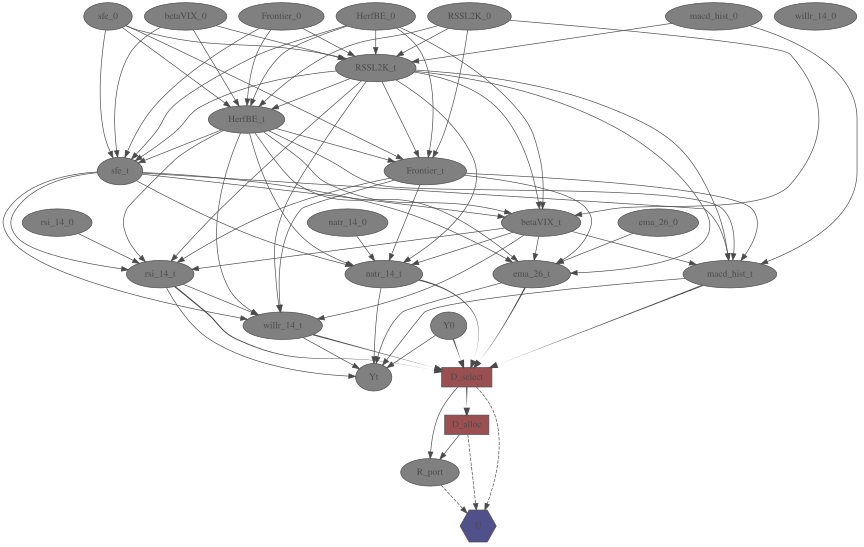

In [304]:

# Display the Influence Diagram structure
print("\n" + "="*80)
print("INFLUENCE DIAGRAM STRUCTURE")
print("="*80)
gnb.showInfluenceDiagram(ID, size="12")

In [305]:
# ============================================================================
# SOLVE (INFERENCE) THE INFLUENCE DIAGRAM (dynamic version with R_port)
# ============================================================================

print("\n" + "="*80)
print("SOLVING INFLUENCE DIAGRAM")
print("="*80)

# 1. Run influence diagram inference
ie_id = gum.ShaferShenoyLIMIDInference(ID)
ie_id.makeInference()

# 2. Optimal decision for D_select
d_select_tensor = ie_id.optimalDecision(ID.idFromName("D_select"))
d_select_arr = d_select_tensor.toarray()
optimal_select_idx = int(np.argmax(d_select_arr))
optimal_select_action = actions_select[optimal_select_idx]

# 3. Optimal decision for D_alloc
d_alloc_tensor = ie_id.optimalDecision(ID.idFromName("D_alloc"))
d_alloc_arr = d_alloc_tensor.toarray()
optimal_alloc_idx = int(np.argmax(d_alloc_arr))
optimal_alloc_action = actions_alloc[optimal_alloc_idx]

# 4. Maximum Expected Utility (MEU)
meu_dict = ie_id.MEU()  # dict: keys = strategy desc, values = EU
max_utility = float(max(meu_dict.values()))

# ----------------------------------------------------------------------------
# 5. Reconstruct the Expected Utility matrix EU[i,j]
#
#    EU[i,j] = sum_k u_vec[k] * P(R_port = k | D_select=i, D_alloc=j)
#
#    where:
#      - u_vec[k] is utility of R_port state k from the utility node U(R_port)
#      - P(R_port | D_select, D_alloc) comes from ID.cpt("R_port")
# ----------------------------------------------------------------------------

# (a) Get CPT of R_port and the utility table
cpt_rp   = ID.cpt("R_port")     # P(R_port | D_select, D_alloc)
util_tab = ID.utility("U")      # U(R_port)

# How many options do we have?
n_sel   = len(actions_select)
n_alloc = len(actions_alloc)
n_bins  = ID.variable("R_port").domainSize()

# (b) Extract u_vec[k] = utility when R_port is in state k
u_vec = np.zeros(n_bins)
instU = gum.Instantiation(util_tab)
# We'll explicitly set R_port = k and read util_tab.get(instU)
for k in range(n_bins):
    instU.chgVal("R_port", k)         
    u_vec[k] = util_tab.get(instU)

# (c) Build EU_matrix[i,j]
EU_matrix = np.zeros((n_sel, n_alloc))

# We'll reuse a single Instantiation over cpt_rp and just mutate it.
instR = gum.Instantiation(cpt_rp)

# IMPORTANT: we don't assume variable order in cpt_rp.variablesSequence(),
# we just always address variables by name using chgVal("varname", stateIndex)
for i_sel in range(n_sel):
    for j_alloc in range(n_alloc):

        # p_vec[k] = P(R_port=k | D_select=i_sel, D_alloc=j_alloc)
        p_vec = np.zeros(n_bins)

        # We'll loop over possible bins of R_port and query the CPT
        for k_bin in range(n_bins):
            instR.chgVal("R_port",   k_bin)     
            instR.chgVal("D_select", i_sel)
            instR.chgVal("D_alloc",  j_alloc)

            p_vec[k_bin] = cpt_rp.get(instR)

        # numerical guard: ensure probabilities sum to 1
        s = p_vec.sum()
        if s > 0:
            p_vec /= s

        # expected utility for this (i_sel, j_alloc)
        EU_matrix[i_sel, j_alloc] = float(np.dot(u_vec, p_vec))

# ----------------------------------------------------------------------------
# 6. Pretty-print results
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("OPTIMAL STRATEGY")
print("="*80)
print(f"\nAsset Selection:  {optimal_select_action}")
print(f"Asset Allocation: {optimal_alloc_action}")
print(f"Expected Utility: {max_utility:.6f}")

print("\n" + "="*80)
print("EXPECTED UTILITY MATRIX (after marginalizing R_port)")
print("="*80)
print("\nRows: Asset Selection | Columns: Asset Allocation")
print(f"\n{'':<20}", end="")
for alloc in actions_alloc:
    print(f"{alloc[:18]:<20}", end="")
print()
print("-" * (20 + 20 * len(actions_alloc)))

for i_sel, sel_name in enumerate(actions_select):
    print(f"{sel_name:<20}", end="")
    for j_alloc in range(n_alloc):
        marker = " ★" if (i_sel == optimal_select_idx and j_alloc == optimal_alloc_idx) else ""
        print(f"{EU_matrix[i_sel, j_alloc]:>17.5f}{marker:<3}", end="")
    print()

print("\n★ = Optimal (D_select, D_alloc) under full expected utility of R_port")



SOLVING INFLUENCE DIAGRAM

OPTIMAL STRATEGY

Asset Selection:  TopK_LongShort
Asset Allocation: allocate_MV
Expected Utility: 0.078619

EXPECTED UTILITY MATRIX (after marginalizing R_port)

Rows: Asset Selection | Columns: Asset Allocation

                    allocate_MV         allocate_kelly      allocate_pY1_weigh  keep_prev           
----------------------------------------------------------------------------------------------------
TopK_LongOnly                 0.06141             0.05705             0.05670             0.04786   
TopK_LongShort                0.07862 ★           0.07675             0.07633             0.02910   
Symmetric_LS                  0.07769             0.07549             0.07517             0.02916   
TopKInertia_LongShort          0.07862             0.07675             0.07633             0.02910   

★ = Optimal (D_select, D_alloc) under full expected utility of R_port


# 🎯 **Step 11: Backtesting**



well done! now it is time to go for the backtesting. what i am thinking about the backtesting
- we must be sure that we are using the data we have until that date
- for each date, we must recalculate the selected factors and indicators. the market is dynamic and the relation among th factors and indicators change during time
- for each date we must exapnd the data and add the previous used data to find the most relevant factors and retrain the DBN
- we want to compare how our strategy is performing againt the SPX index
- we must include the cost of stock rotation in our rebalancing.  maybe you want to use the estimate_transaction_cost and compute_turnover. you can improve these functions. 
- we must have long and short positions 

## 🧮 **Helper Functions: Transaction Cost Utilities**

These functions compute portfolio turnover and estimate transaction costs for backtesting purposes. They will be used during the backtesting phase to calculate realistic performance metrics that account for trading costs.

### Function: `compute_turnover`

Purpose
- Compute portfolio turnover between two weight vectors.

Inputs
- w_new, w_old: Series of weights.
- market_cap: Optional Series to MC-weight turnover.
- mode: 'gross' (sum abs diffs) or 'net' (0.5 × gross).

Output
- Float turnover in [0, 2] for gross, [0, 1] for net.

Procedure
- Align indices, take L1 norm of weight change; optionally weight by MC and normalize; scale for mode.

In [306]:
# === TRANSACTION COST UTILITIES  ===

def compute_turnover(w_new, w_old, market_cap=None, mode="gross"):
    """
    Turnover between two weight vectors.
    - mode='gross'  -> L1(w_new - w_old), max=2.0 (200%)
    - mode='net'    -> 0.5 * L1(...),     max=1.0 (100%)
    Optionally MC-weighted.
    """
    all_tickers = w_new.index.union(w_old.index)
    w_new_aligned = w_new.reindex(all_tickers, fill_value=0.0)
    w_old_aligned = w_old.reindex(all_tickers, fill_value=0.0)

    base = (w_new_aligned - w_old_aligned).abs()
    if market_cap is not None:
        mc = market_cap.reindex(all_tickers, fill_value=1.0)
        base = (base * mc) / mc.sum()

    gross = float(base.sum())
    if mode == "net":
        return 0.5 * gross
    return gross



### Function: `estimate_transaction_cost`

Purpose
- Estimate arithmetic transaction costs from turnover with optional market impact and short borrow fees.

Inputs
- turnover: Fraction of portfolio traded.
- cost_bps: Base cost per unit turnover.
- market_impact_factor: Quadratic impact coefficient.
- short_fee_bps: Borrow fee proxy.

Output
- Float cost fraction (arithmetic), convertible to log loss via -ln(1-cost).

Procedure
- Base + impact (α·turnover²) + short fee component.

Notes
- Used in backtest to penalize rebalances.

In [307]:


def estimate_transaction_cost(turnover, cost_bps=10, market_impact_factor=0.01, short_fee_bps=5):
    """
    Enhanced cost estimation.
    - cost_bps: Base trading cost (10 bps = 0.10%).
    - market_impact_factor: Quadratic impact for large turnover (e.g., 0.01 for 1% additional cost at 100% turnover).
    - short_fee_bps: Annual borrowing fee for shorts (5 bps).
    """
    base_cost = turnover * (cost_bps / 10000)
    impact_cost = market_impact_factor * (turnover ** 2)  # Quadratic market impact
    short_cost = turnover * (short_fee_bps / 10000) if turnover > 0 else 0  # Approximate for shorts
    
    return base_cost + impact_cost + short_cost



    

# Example demonstration
print("="*70)
print("TRANSACTION COST EXAMPLES")
print("="*70)

# Simulate different rebalancing scenarios
scenarios = [
    ("No Change", pd.Series([0.1, 0.2, 0.3, 0.4], index=['A','B','C','D']),
                  pd.Series([0.1, 0.2, 0.3, 0.4], index=['A','B','C','D'])),
    
    ("Small Adjustment", pd.Series([0.12, 0.18, 0.32, 0.38], index=['A','B','C','D']),
                         pd.Series([0.10, 0.20, 0.30, 0.40], index=['A','B','C','D'])),
    
    ("Add New Stock", pd.Series([0.1, 0.2, 0.2, 0.3, 0.2], index=['A','B','C','D','E']),
                      pd.Series([0.1, 0.2, 0.3, 0.4], index=['A','B','C','D'])),
    
    ("Full Rebalance", pd.Series([0.25, 0.25, 0.25, 0.25], index=['W','X','Y','Z']),
                       pd.Series([0.10, 0.20, 0.30, 0.40], index=['A','B','C','D'])),
]

results = []
for name, w_new, w_old in scenarios:
    turnover = compute_turnover(w_new, w_old)
    tc_10bps = estimate_transaction_cost(turnover, cost_bps=10)
    tc_5bps = estimate_transaction_cost(turnover, cost_bps=5)
    
    results.append({
        'Scenario': name,
        'Turnover': f"{turnover:.2%}",
        'TC (10 bps)': f"{tc_10bps:.4%}",
        'TC (5 bps)': f"{tc_5bps:.4%}"
    })

df_tc = pd.DataFrame(results)
print("\n" + df_tc.to_string(index=False))

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("""
- **No Change**: 0% turnover → 0% cost (hold positions)
- **Small Adjustment**: ~8% turnover → 0.08% cost (minor rebalance)
- **Add New Stock**: ~40% turnover → 0.40% cost (portfolio expansion)
- **Full Rebalance**: 200% turnover → 2.00% cost (complete overhaul)

**Quarterly Rebalancing (Our Strategy):**
- Expected turnover: 30-50% (based on pY1 evolution)
- At 10 bps: Cost ≈ 0.03-0.05% per quarter ≈ 0.12-0.20% annually
- **Impact**: Modest (~10-20% of alpha if strategy generates 1% annual alpha)

**Decision Rule:**
- Accept rebalance if: ΔUtility > Transaction Cost
- Example: Switching stock A→B adds 0.10% expected return
  - If turnover = 0.2, TC = 0.02% → Net gain = 0.08% → **DO IT**
  - If turnover = 1.5, TC = 0.15% → Net loss = -0.05% → **SKIP**
""")

print("\n✓ Transaction cost framework ready for backtesting integration")
print("="*70)

TRANSACTION COST EXAMPLES

        Scenario Turnover TC (10 bps) TC (5 bps)
       No Change    0.00%     0.0000%    0.0000%
Small Adjustment    8.00%     0.0184%    0.0144%
   Add New Stock   40.00%     0.2200%    0.2000%
  Full Rebalance  200.00%     4.3000%    4.2000%

INTERPRETATION:

- **No Change**: 0% turnover → 0% cost (hold positions)
- **Small Adjustment**: ~8% turnover → 0.08% cost (minor rebalance)
- **Add New Stock**: ~40% turnover → 0.40% cost (portfolio expansion)
- **Full Rebalance**: 200% turnover → 2.00% cost (complete overhaul)

**Quarterly Rebalancing (Our Strategy):**
- Expected turnover: 30-50% (based on pY1 evolution)
- At 10 bps: Cost ≈ 0.03-0.05% per quarter ≈ 0.12-0.20% annually
- **Impact**: Modest (~10-20% of alpha if strategy generates 1% annual alpha)

**Decision Rule:**
- Accept rebalance if: ΔUtility > Transaction Cost
- Example: Switching stock A→B adds 0.10% expected return
  - If turnover = 0.2, TC = 0.02% → Net gain = 0.08% → **DO IT**
  - If turnove

In [308]:
def filter_tickers_with_history(prices: pd.DataFrame,
                                as_of: pd.Timestamp,
                                lookback_months: int = 36,
                                min_obs: int = 12,
                                field: str = "Adj Close") -> pd.Index:
    """
    Return tickers having >= min_obs non-NaN monthly log-return observations
    in the last `lookback_months+1` rows up to `as_of`.
    Works with plain DataFrame or MultiIndex (ticker, field).
    """
    px = prices.loc[:as_of]
    if isinstance(px.columns, pd.MultiIndex):
        if field not in px.columns.get_level_values(1):
            # fallback: use first field
            field = px.columns.get_level_values(1)[0]
        px = px.xs(field, axis=1, level=1)
    if len(px) < min_obs + 1:
        return pd.Index([])
    tail = px.tail(lookback_months + 1)
    rets = np.log(tail).diff().replace([np.inf, -np.inf], np.nan)
    counts = rets.count()
    eligible = counts[counts >= min_obs].index
    return eligible


## Run the Backtesting (it takes more than 3h)

## Function: `run_backtest_sequential`

Purpose
- Walk-forward backtest with retraining at each rebalance date, decision by Influence Diagram, and realized performance accounting for costs.

Inputs
- train_df, test_df: Macro/SPX (continuous).
- train_prices, test_prices: Wide prices.
- M: Rebalance frequency (months).
- FWD: Forward horizon.
- K_long, K_short, cost_bps, N_TECH, N_MACRO, lookback_months, lambda_risk.
- turnover_mode: 'gross'|'net'.
- n_bootstrap: For MI stability.

Output
- DataFrame indexed by date with fields: strategy_alpha (log, net of costs), spx_return (log), cumulative series, turnover, transaction_cost, chosen policies, mu/var matrices, calibration diagnostics.

Procedure (per decision date dt)
- Define cutoff_train = dt − FWD months (label-safe).
- Compute indicators up to dt; clean; select TECH/MACRO via `compute_mi_continuous` on ≤ cutoff_train.
- Discretize selected indicators/macros; build training panel ≤ cutoff_train; build two-slice; learn DBN.
- Build full panel up to dt for scoring/calibration; build two-slice; score pY1 at dt.
- Build and solve Influence Diagram to choose selection/allocation.
- Construct weights; compute realized forward returns and SPX from test set; compute excess alpha and transaction costs; update cumulative curves; record metrics.

Notes
- Enforces no look-ahead at labeling and calibration steps.

In [309]:
def run_backtest_sequential(
    train_df,
    train_prices,
    test_df,
    test_prices,
    M=3,
    FWD=3,
    K_long=20,
    K_short=10,
    cost_bps=10,
    N_TECH=5,
    N_MACRO=5,
    lookback_months=36,
    lambda_risk=0.5,
    turnover_mode: str = "gross", 
    n_bootstrap=5,
    selection_inertia: bool = True,
    overlap_keep: float = 0.7,
    id_turnover_penalty_scale: float = 5.0
):
    """
    Sequential backtest with retraining at each rebalance date.

    At each decision date dt:
      1. We define cutoff_train = dt - FWD months.
         Anything after cutoff_train is NOT allowed in training the DBN,
         because we wouldn't yet know FWD-forward returns for those later months.
      2. We train the factor model / DBN on data <= cutoff_train.
      3. We build panel_full up to dt (the info actually known live).
      4. We make two_slice_full from panel_full (includes dt and recent past).
      5. We call build_influence_diagram_from_dbn_dynamic(...) which:
         - calibrates pY1 -> E[fwd return] using only past dates whose
           forward window has fully realized by dt,
         - estimates mean/var for each (selection policy, allocation policy),
         - builds an Influence Diagram with R_port -> U,
         - returns the Influence Diagram.
      6. We solve the ID to get optimal D_select and D_alloc.
      7. We construct weights, apply transaction cost, roll forward PnL.

    Returns:
      DataFrame indexed by 'date' with realized performance, chosen policies, etc.
    """

    actions_select = ["TopK_LongOnly", "TopK_LongShort", "Symmetric_LS", "TopKInertia_LongShort"]
    actions_alloc  = ["allocate_MV", "allocate_kelly", "allocate_pY1_weighted", 'keep_prev']


    # ------------------------------------------------------------------
    # 1. Pick decision dates (rebalance every M months, must have FWD future)
    # ------------------------------------------------------------------
    all_dates = test_df.index.sort_values()
    decision_dates = all_dates[::M]

    max_date = test_prices.index[-1]
    valid_decision_dates = [
        dt for dt in decision_dates if dt + pd.offsets.MonthEnd(FWD) <= max_date
    ]
    decision_dates = valid_decision_dates if len(valid_decision_dates) > 1 else []

    if len(decision_dates) < 1:
        raise ValueError("Not enough valid decision dates for backtest")

    # ------------------------------------------------------------------
    # 2. Tracking state across periods
    # ------------------------------------------------------------------
    results = []
    prev_weights = pd.Series(dtype=float)
    cumulative_strategy = 1.0
    cumulative_spx = 1.0
    cumulative_alpha = 1.0             # pure alpha


    # ------------------------------------------------------------------
    # 3. Loop over rebalance dates
    # ------------------------------------------------------------------
    for i, dt in enumerate(decision_dates):
        try:
            print(f"\n{'='*60}")
            print(f"DATE {i+1}/{len(decision_dates)}: {dt.date()}")
            print(f"{'='*60}")

            # -------------------------------------------------
            # Define training and live windows relative to dt
            # -------------------------------------------------

            # full info available "live" at dt
            # Ensure no future rows beyond dt
            df_full = pd.concat([train_df.loc[:dt],  test_df.loc[:dt]]).loc[:dt]
            px_full = pd.concat([train_prices.loc[:dt], test_prices.loc[:dt]]).loc[:dt]

            # Enforce monotone unique index
            df_full = df_full[~df_full.index.duplicated(keep="last")].sort_index()
            px_full = px_full[~px_full.index.duplicated(keep="last")].sort_index()

            assert px_full.index.max() == dt, f"Price leakage: got {px_full.index.max()} > {dt}"

            # filter universe by sufficient return history ---
            eligible_tickers = filter_tickers_with_history(
                px_full, dt,
                lookback_months=lookback_months,
            )
            if len(eligible_tickers) == 0:
                print(f"[{dt.date()}] No eligible tickers (history). Skipping.")
                continue

            # Restrict prices + (later) indicators to eligible tickers only
            if isinstance(px_full.columns, pd.MultiIndex):
                # keep all fields (e.g. 'Adj Close', 'Open', ...) for eligible tickers
                ix = pd.IndexSlice
                px_full = px_full.loc[:, ix[eligible_tickers, :]]
            else:
                px_full = px_full[eligible_tickers]

            # Align previous weights to surviving universe
            if not prev_weights.empty:
                prev_weights = prev_weights.reindex(eligible_tickers).dropna()
            # -------------------------------------------------


            # training slice (used to learn DBN & do MI selection)
            cutoff_train = dt - pd.offsets.MonthEnd(FWD)  # last date we can label safely

            df_train_cut = df_full.loc[:cutoff_train]
            px_train_cut = px_full.loc[:cutoff_train]

            # -------------------------------------------------
            # STEP A. Compute indicators on full price history up to dt
            # -------------------------------------------------
            ind_all_full = compute_technical_indicators(px_full)
            ind_all_full = indicators_to_dict(ind_all_full)

            # clean NaN/inf in indicators
            ind_all_full_clean = {}
            for name, df_ind in ind_all_full.items():
                df_clean = (
                    df_ind.replace([np.inf, -np.inf], np.nan)
                         .fillna(method="ffill", limit=3)
                         .fillna(method="bfill", limit=3)
                         .fillna(0)
                )
                ind_all_full_clean[name] = df_clean
            ind_all_full = ind_all_full_clean

            # indicators restricted to training slice
            ind_train = {k: v.loc[:cutoff_train] for k, v in ind_all_full.items()}

            # -------------------------------------------------
            # STEP B. Feature selection via MI on *training slice only*
            # -------------------------------------------------
            mi_ser = compute_mi_continuous(
                cont_factor_df=df_train_cut,
                prices_df=px_train_cut,
                indicators_dict=ind_train,
                FWD=1,
                n_bootstrap=n_bootstrap,
            )

            TECH_KEEP = (
                mi_ser.loc[[c for c in ind_train.keys() if c in mi_ser.index]]
                .sort_values(ascending=False)
                .head(N_TECH)
                .index.tolist()
            )

            MACRO_KEEP = (
                mi_ser.loc[[c for c in df_train_cut.columns if c in mi_ser.index]]
                .sort_values(ascending=False)
                .head(N_MACRO)
                .index.tolist()
            )

            print(f"Selected TECH_KEEP: {TECH_KEEP}")
            print(f"Selected MACRO_KEEP: {MACRO_KEEP}")

            # -------------------------------------------------
            # STEP C. Build discretized training panel (<= cutoff_train)
            # -------------------------------------------------
            ind_train_keep = {k: v for k, v in ind_train.items() if k in TECH_KEEP}
            ind_train_disc = {k: xsec_discretize(v, 3) for k, v in ind_train_keep.items()}

            trnd_train = pd.DataFrame(index=df_train_cut.index, columns=MACRO_KEEP)
            for col in MACRO_KEEP:
                s_col = pd.Series(df_train_cut[col].values, index=df_train_cut.index)
                bins = getBinsFromTrend(s_col.index, s_col, [3, 10, 1], 20)
                trnd_train[col] = bins["bin"]
            trnd_train = trnd_train.dropna()

            panel_train, _ = build_panel(
                cont_factor_df=df_train_cut[MACRO_KEEP + ["SPX"]],
                prices_df=px_train_cut,
                indicators_dict=ind_train_disc,
                FWD=FWD,
                macro_disc_df=trnd_train,
                filter_decisions=True,
            )
            assert len(panel_train) > 0, "Empty training panel."
            assert panel_train.index.get_level_values("date").max() <= cutoff_train, "Leakage in training panel dates."


            # -------------------------------------------------
            # STEP D. two-slice for TRAIN → learn DBN
            # -------------------------------------------------
            train_dates = panel_train.index.get_level_values("date").unique().sort_values()
            if len(train_dates) < 2:
                print(f"Not enough dates to train DBN for {dt.date()}")
                continue

            two_slice_train = build_two_slice(panel_train, train_dates)
            two_slice_train = (
                two_slice_train.replace([np.inf, -np.inf], np.nan)
                               .dropna()
            )

            if two_slice_train.empty:
                print(f"Warning: empty two_slice_train for {dt.date()}")
                continue

            twodbn = learn_two_slice_dbn(TECH_KEEP, MACRO_KEEP, two_slice_train, max_indegree=4)

            # -------------------------------------------------
            # STEP E. Build SCORING + CALIBRATION panel using ALL info up to dt
            #         (TECH_KEEP / MACRO_KEEP fixed from training)
            # -------------------------------------------------
            ind_score_keep = {
                k: v.loc[:dt] for k, v in ind_all_full.items() if k in TECH_KEEP
            }
            ind_score_disc = {k: xsec_discretize(v, 3) for k, v in ind_score_keep.items()}

            trnd_full = pd.DataFrame(index=df_full.index, columns=MACRO_KEEP)
            for col in MACRO_KEEP:
                s_col = pd.Series(df_full[col].values, index=df_full.index)
                bins = getBinsFromTrend(s_col.index, s_col, [3, 10, 1], 20)
                trnd_full[col] = bins["bin"]
            # Reindexing and filling so the current dt is available (avoid losing dt)
            trnd_full = (
                    trnd_full.reindex(df_full.index)
                            .fillna(method="ffill", limit=3)
                            .fillna(method="bfill", limit=3)
)

            panel_full, _ = build_panel(
                cont_factor_df=df_full[MACRO_KEEP + ["SPX"]],
                prices_df=px_full,
                indicators_dict=ind_score_disc,
                FWD=FWD,
                macro_disc_df=trnd_full,
                filter_decisions=False,
            )

            all_scoring_dates = (
                panel_full.index.get_level_values("date").unique().sort_values()
            )

            # We will hand the full two_slice (up to dt) into the ID builder.
            two_slice_full = build_two_slice(panel_full, all_scoring_dates)

            # pY1 scores at the actual decision date dt, from that same view
            pY1_scores_dt = score_cross_section_pY1(twodbn, two_slice_full, dt)

            # -------------------------------------------------
            # Diagnostics BEFORE ID solve
            # -------------------------------------------------

            print(f"\n=== DIAGNOSTICS BEFORE build_influence_diagram ===")
            print(f"dt: {dt}")
            print(f"cutoff_train: {cutoff_train}")
            print(f"TRAIN panel dates: {train_dates.min()} → {train_dates.max()}")
            print(f"FULL  panel dates: {all_scoring_dates.min()} → {all_scoring_dates.max()}")
            print(f"two_slice_train.shape: {two_slice_train.shape}")
            print(f"two_slice_full.shape:  {two_slice_full.shape}")
            print(f"Does two_slice_full include dt? "
                  f"{dt in two_slice_full.index.get_level_values('date')}")
            print(f"TECH_KEEP: {TECH_KEEP}")
            print(f"MACRO_KEEP: {MACRO_KEEP}")
            print(f"twodbn names: {twodbn.names() if twodbn is not None else None}")
            print(f"px_full.shape: {px_full.shape}")
            print(f"px_full range: {px_full.index.min()} → {px_full.index.max()}")
            print(f"actions_select: {actions_select}")
            print(f"actions_alloc:  {actions_alloc}")
            print(f"K_long: {K_long}, K_short: {K_short}, FWD: {FWD}")
            print("=" * 60)

            # -------------------------------------------------
            # STEP F. Build ID for this dt and solve
            # -------------------------------------------------
            # Expose decision date globally so calibration can use macro regime if implemented
            ID, mu_mat, var_mat, calib_debug, calibration_func = build_influence_diagram_from_dbn_dynamic(
                twodbn=twodbn,
                two_slice_df=two_slice_full,
                actions_select=actions_select,
                actions_alloc=actions_alloc,
                decision_date=dt,
                prices_df=px_full,          # px_full stops at dt
                K_long=K_long,
                K_short=K_short,
                FWD=FWD,
                lookback_months=lookback_months,
                lambda_risk=lambda_risk,
                pY1_scores=pY1_scores_dt,   # we already scored dt explicitly
                benchmark_series=df_full["SPX"],  # use SPX for excess mapping
                prev_weights=prev_weights,
                # Stronger penalty inside ID to reduce churn
                gamma_turnover=id_turnover_penalty_scale * (cost_bps/10000.0),
                turnover_mode=turnover_mode,  
            )

            # solve the LIMID
            ie_id = gum.ShaferShenoyLIMIDInference(ID)
            ie_id.makeInference()

            dsel_policy   = ie_id.optimalDecision(ID.idFromName("D_select")).toarray()
            dalloc_policy = ie_id.optimalDecision(ID.idFromName("D_alloc")).toarray()

            optimal_select = actions_select[int(np.argmax(dsel_policy))]
            optimal_alloc  = actions_alloc[int(np.argmax(dalloc_policy))]

            # -------------------------------------------------
            # STEP G. Turn that optimal policy into actual tradable weights
            # -------------------------------------------------
            policy_name = optimal_select.split("_")[0]  # "TopK" or "Symmetric"

            # Optional selection inertia to reduce turnover
            sel_policy_to_use = policy_name
            if selection_inertia and policy_name == "TopK":
                sel_policy_to_use = "TopKInertia"

            basket_dict = select_basket_long_short(
                pY1_scores_dt,
                policy=sel_policy_to_use,
                K_long=K_long,
                K_short=K_short
                if ("LongShort" in optimal_select or "LS" in optimal_select)
                else 0,
                prev_weights=prev_weights,
                overlap_keep=overlap_keep,
            )

            print(f"DEBUG: basket_dict for {dt.date()}: {basket_dict}")
            print(
                f"Long: {len(basket_dict['long'])}, "
                f"Short: {len(basket_dict['short'])}, "
                f"Total: {len(basket_dict['long']) + len(basket_dict['short'])}"
            )

            # allocators should only see price history up to dt
            px_alloc = px_full

            if optimal_alloc == "allocate_MV":
                new_weights = allocate_MV_long_short(
                    pY1_scores_dt,
                    basket_dict,
                    px_alloc,
                    calibration_func=calibration_func,
                    lambda_risk=lambda_risk,
                    lookback_months=lookback_months,  
                    use_shrinkage=True,               
                    prev_weights=prev_weights,
                    gamma_tc=0.0,  #  SET TO 0 HERE (ID already penalized turnover)
                    turnover_mode=turnover_mode,
                )
            elif optimal_alloc == "allocate_kelly":
                new_weights = allocate_kelly_long_short(
                    pY1_scores_dt, basket_dict, px_alloc, calibration_func=calibration_func
                )
            elif optimal_alloc == "allocate_pY1_weighted":
                new_weights = allocate_pY1_weighted_long_short(
                    pY1_scores_dt, basket_dict, calibration_func=calibration_func
                )
            elif optimal_alloc == "keep_prev":
                if not prev_weights.empty:
                    new_weights = prev_weights.copy()
                else:
                    longs = basket_dict["long"]
                    shorts = basket_dict["short"]
                    nL, nS = len(longs), len(shorts)
                    if nL + nS == 0:
                        new_weights = pd.Series(dtype=float)
                    else:
                        combo = pd.Index(list(longs) + list(shorts))
                        wL = np.full(nL, 1.0 / nL) if nL > 0 else np.array([])
                        wS = -np.full(nS, 1.0 / nS) if nS > 0 else np.array([])
                        new_weights = pd.Series(np.concatenate([wL, wS]) if nS > 0 else wL, index=combo)

                    # Top up with best current names if we lost members
                    desired = K_long + K_short
                    if desired > len(new_weights):
                        scores = pY1_scores_dt.drop(new_weights.index, errors="ignore")
                        fill = scores.sort_values(ascending=False).head(desired - len(new_weights))
                        filler = pd.Series(np.sign(fill - 0.5), index=fill.index)
                        new_weights = pd.concat([new_weights, filler])

                    # Normalize to keep gross exposure at 1
                    if not new_weights.empty:
                        new_weights = new_weights / new_weights.abs().sum()
            else:
                longs = basket_dict["long"]
                shorts = basket_dict["short"]
                nL, nS = len(longs), len(shorts)
                if nL + nS == 0:
                    new_weights = pd.Series(dtype=float)
                else:
                    combo = pd.Index(list(longs) + list(shorts))
                    wL = np.full(nL, 1.0 / nL) if nL > 0 else np.array([])
                    wS = -np.full(nS, 1.0 / nS) if nS > 0 else np.array([])
                    new_weights = pd.Series(np.concatenate([wL, wS]) if nS > 0 else wL, index=combo)

            # ------------------------ Realized returns (EXCESS) ------------------------

            px_test_clean = _extract_price_matrix(test_prices)

            # stock forward raw return (Series by ticker at dt)
            fwd_ret = compute_forward_returns(px_test_clean, dates=[dt], FWD=FWD).loc[dt]

            # SPX forward raw return (scalar)
            spx_fwd = compute_forward_returns(test_df[["SPX"]], dates=[dt], FWD=FWD).loc[dt, "SPX"]

            # alpha (excess) per name, and realized portfolio alpha (LOG space)
            fwd_ret_excess = fwd_ret - float(spx_fwd)
            port_alpha = (new_weights * fwd_ret_excess.reindex(new_weights.index, fill_value=0.0)).sum()

            # transaction costs (arithmetic), convert to log-loss
            if not prev_weights.empty and not new_weights.empty:
                turnover = compute_turnover(new_weights, prev_weights, mode=turnover_mode)
                tc_arith = estimate_transaction_cost(turnover, cost_bps=cost_bps, market_impact_factor=0.0)
            else:
                turnover = 0.0
                tc_arith = 0.0
            
            # convert arithmetic cost to positive log-loss: tc_log = -ln(1 - tc_arith)
            tc_arith = float(np.clip(tc_arith, 0.0, 0.95))
            tc_log = -np.log(1.0 - tc_arith)

            port_alpha_net_log = float(port_alpha) - float(tc_log)

            # update cumulative series:
            # - cumulative_alpha: pure alpha growth
            # - cumulative_spx: benchmark
            # - cumulative_strategy: hedged absolute = SPX + alpha
            cumulative_alpha    *= np.exp(port_alpha_net_log)
            cumulative_spx      *= np.exp(spx_fwd)
            cumulative_strategy *= np.exp(spx_fwd + port_alpha_net_log)
            
            results.append({
                "date": dt,
                "strategy_alpha": port_alpha_net_log,
                "spx_return": spx_fwd,
                "cumulative_alpha": cumulative_alpha,
                "cumulative_spx": cumulative_spx,
                "cumulative_strategy": cumulative_strategy,
                "turnover": turnover,
                "transaction_cost": tc_log,
                "optimal_select": optimal_select,
                "optimal_alloc": optimal_alloc,
                "mu_mat": mu_mat,
                "var_mat": var_mat,
                "calib_debug": calib_debug,
                "n_long": len(basket_dict["long"]),
                "n_short": len(basket_dict["short"]),
                "basket_tickers": list(new_weights.index),  # Actual holdings
            })

            prev_weights = new_weights

        # 🔥 Print interim stats every 3 dates
            if (i + 1) % 3 == 0 and len(results) > 0:
                temp_df = pd.DataFrame(results).set_index("date")
                r_alpha = temp_df["strategy_alpha"].astype(float).fillna(0.0)
                r_strat = (temp_df["spx_return"] + r_alpha).astype(float)
                
                # Compute live metrics
                live_sharpe = (r_strat.mean() / r_strat.std()) * np.sqrt(4) if r_strat.std() > 0 else 0.0
                total_alpha_log = r_alpha.sum()  # Sum of log returns
                live_turnover = temp_df["turnover"].mean()
                live_win_rate = float((r_alpha > 0).mean())
                
                # Cumulative alpha display: stored as growth factor, print (growth-1) as percent
                cum_alpha_growth = float(temp_df["cumulative_alpha"].iloc[-1])
                cum_alpha_pct = cum_alpha_growth - 1.0
                
                print(f"\n📊 INTERIM STATS (after {i+1}/{len(decision_dates)} dates):")
                print(f"   Sharpe (rolling):     {live_sharpe:.2f}")
                print(f"   Win Rate:             {live_win_rate:.1%}")
                print(f"   Total Alpha (log):    {total_alpha_log:.4f} ({np.exp(total_alpha_log)-1:.2%} arith)")
                print(f"   Avg Turnover:         {live_turnover:.1%}")
                print(f"   Cumulative Alpha:     {cum_alpha_pct:.2%}\n")

        except Exception as e:
            print(f"Error on {dt.date()}: {str(e)}")
            traceback.print_exc()
            continue

    if not results:
        return pd.DataFrame()

    return pd.DataFrame(results).set_index("date")


In [310]:
# Run the sequential backtest
backtest_results = run_backtest_sequential(
    macro_train, prices_df_train, macro_test, prices_df_test,
    M=3, FWD=3, K_long=20, K_short=10, cost_bps=10, N_TECH=6, N_MACRO=6,
    turnover_mode="gross",
    n_bootstrap=10,
    id_turnover_penalty_scale=2.0,
    overlap_keep=0.4,
)
print(backtest_results)


DATE 1/27: 2018-05-31
Auto-detected: 16 tech + 173 macro
Panel: 120,727 rows × 189 features
Window: last 5y → 28,384 samples
Time decay: ½-life=2y, weight ratio=5.7x
Bootstrap: 10 samples (n_jobs=-1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   56.3s finished


Selected TECH_KEEP: ['natr_14', 'ema_12', 'macd', 'willr_14', 'roc_12', 'macd_hist']
Selected MACRO_KEEP: ['MomSeason06YrPlus', 'HerfBE', 'RD', 'BidAskSpread', 'ChInvIA', 'GrSaleToGrOverhead']
   Found 105 valid date pairs from 106 total dates
   Found 319 valid date pairs from 320 total dates

=== DIAGNOSTICS BEFORE build_influence_diagram ===
dt: 2018-05-31 00:00:00
cutoff_train: 2018-02-28 00:00:00
TRAIN panel dates: 1991-10-31 00:00:00 → 2018-01-31 00:00:00
FULL  panel dates: 1991-10-31 00:00:00 → 2018-05-31 00:00:00
two_slice_train.shape: (48552, 26)
two_slice_full.shape:  (148988, 26)
Does two_slice_full include dt? True
TECH_KEEP: ['natr_14', 'ema_12', 'macd', 'willr_14', 'roc_12', 'macd_hist']
MACRO_KEEP: ['MomSeason06YrPlus', 'HerfBE', 'RD', 'BidAskSpread', 'ChInvIA', 'GrSaleToGrOverhead']
twodbn names: {'ema_12_t', 'HerfBE_t', 'macd_hist_0', 'RD_t', 'macd_t', 'ema_12_0', 'GrSaleToGrOverhead_t', 'Y0', 'natr_14_0', 'Yt', 'macd_0', 'willr_14_0', 'MomSeason06YrPlus_t', 'roc_12_0'

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   41.8s finished


Selected TECH_KEEP: ['natr_14', 'ema_12', 'roc_12', 'macd_hist', 'ema_26', 'willr_14']
Selected MACRO_KEEP: ['HerfBE', 'ShareIss5Y', 'Frontier', 'AnnouncementReturn', 'PredictedFE', 'BPEBM']
   Found 106 valid date pairs from 107 total dates
   Found 322 valid date pairs from 323 total dates

=== DIAGNOSTICS BEFORE build_influence_diagram ===
dt: 2018-08-31 00:00:00
cutoff_train: 2018-05-31 00:00:00
TRAIN panel dates: 1991-10-31 00:00:00 → 2018-04-30 00:00:00
FULL  panel dates: 1991-10-31 00:00:00 → 2018-08-31 00:00:00
two_slice_train.shape: (49028, 26)
two_slice_full.shape:  (150416, 26)
Does two_slice_full include dt? True
TECH_KEEP: ['natr_14', 'ema_12', 'roc_12', 'macd_hist', 'ema_26', 'willr_14']
MACRO_KEEP: ['HerfBE', 'ShareIss5Y', 'Frontier', 'AnnouncementReturn', 'PredictedFE', 'BPEBM']
twodbn names: {'ema_12_t', 'HerfBE_t', 'ShareIss5Y_0', 'macd_hist_0', 'ema_12_0', 'PredictedFE_t', 'Y0', 'natr_14_0', 'Yt', 'ema_26_t', 'willr_14_0', 'PredictedFE_0', 'roc_12_0', 'willr_14_t', '

...

Selected TECH_KEEP: ['natr_14', 'roc_12', 'macd', 'rsi_14', 'cci_20', 'ema_26']
Selected MACRO_KEEP: ['Leverage', 'CF', 'NetDebtPrice', 'realestate', 'InvGrowth', 'RDcap']
   Found 129 valid date pairs from 130 total dates
   Found 391 valid date pairs from 392 total dates

=== DIAGNOSTICS BEFORE build_influence_diagram ===
dt: 2024-05-31 00:00:00
cutoff_train: 2024-02-29 00:00:00
TRAIN panel dates: 1991-10-31 00:00:00 → 2024-01-31 00:00:00
FULL  panel dates: 1991-10-31 00:00:00 → 2024-05-31 00:00:00
two_slice_train.shape: (62748, 26)
two_slice_full.shape:  (191730, 26)
Does two_slice_full include dt? True
TECH_KEEP: ['natr_14', 'roc_12', 'macd', 'rsi_14', 'cci_20', 'ema_26']
MACRO_KEEP: ['Leverage', 'CF', 'NetDebtPrice', 'realestate', 'InvGrowth', 'RDcap']
twodbn names: {'rsi_14_0', 'Leverage_t', 'NetDebtPrice_t', 'InvGrowth_t', 'realestate_t', 'macd_t', 'Y0', 'natr_14_0', 'Yt', 'macd_0', 'realestate_0', 'ema_26_t', 'NetDebtPrice_0', 'roc_12_0', 'CF_0', 'cci_20_t', 'Leverage_0', 'cci_

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   43.5s finished


Selected TECH_KEEP: ['natr_14', 'roc_12', 'cci_20', 'ema_12', 'ema_26', 'willr_14']
Selected MACRO_KEEP: ['MomOffSeason', 'realestate', 'CoskewACX', 'RSSL2K', 'IntanCFP', 'EarningsStreak']
   Found 130 valid date pairs from 131 total dates
   Found 394 valid date pairs from 395 total dates

=== DIAGNOSTICS BEFORE build_influence_diagram ===
dt: 2024-08-31 00:00:00
cutoff_train: 2024-05-31 00:00:00
TRAIN panel dates: 1991-10-31 00:00:00 → 2024-04-30 00:00:00
FULL  panel dates: 1991-10-31 00:00:00 → 2024-08-31 00:00:00
two_slice_train.shape: (63246, 26)
two_slice_full.shape:  (193224, 26)
Does two_slice_full include dt? True
TECH_KEEP: ['natr_14', 'roc_12', 'cci_20', 'ema_12', 'ema_26', 'willr_14']
MACRO_KEEP: ['MomOffSeason', 'realestate', 'CoskewACX', 'RSSL2K', 'IntanCFP', 'EarningsStreak']
twodbn names: {'ema_12_t', 'IntanCFP_t', 'realestate_t', 'ema_12_0', 'Y0', 'natr_14_0', 'Yt', 'realestate_0', 'ema_26_t', 'willr_14_0', 'roc_12_0', 'MomOffSeason_0', 'willr_14_t', 'cci_20_t', 'Coske

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   43.2s finished


Selected TECH_KEEP: ['natr_14', 'roc_12', 'cci_20', 'macd', 'rsi_14', 'ema_26']
Selected MACRO_KEEP: ['MomOffSeason', 'CoskewACX', 'grcapx', 'EarningsStreak', 'IntanCFP', 'realestate']
   Found 131 valid date pairs from 132 total dates
   Found 397 valid date pairs from 398 total dates

=== DIAGNOSTICS BEFORE build_influence_diagram ===
dt: 2024-11-30 00:00:00
cutoff_train: 2024-08-31 00:00:00
TRAIN panel dates: 1991-10-31 00:00:00 → 2024-07-31 00:00:00
FULL  panel dates: 1991-10-31 00:00:00 → 2024-11-30 00:00:00
two_slice_train.shape: (63872, 26)
two_slice_full.shape:  (195109, 26)
Does two_slice_full include dt? True
TECH_KEEP: ['natr_14', 'roc_12', 'cci_20', 'macd', 'rsi_14', 'ema_26']
MACRO_KEEP: ['MomOffSeason', 'CoskewACX', 'grcapx', 'EarningsStreak', 'IntanCFP', 'realestate']
twodbn names: {'rsi_14_0', 'IntanCFP_t', 'grcapx_0', 'grcapx_t', 'realestate_t', 'macd_t', 'Y0', 'natr_14_0', 'Yt', 'macd_0', 'realestate_0', 'ema_26_t', 'roc_12_0', 'MomOffSeason_0', 'cci_20_t', 'CoskewACX

# Analysing the Results

## Function: `summarize_backtest`

Purpose
- Compute and plot summary performance statistics and curves from backtest results.

Input
- backtest_results: DataFrame from run_backtest_sequential.

Output
- Plots: strategy (gross/net) vs SPX, turnover and tx cost.
- Prints: totals, annualized return/vol, Sharpe, information ratio (alpha), win rate, max drawdown, average turnover/cost.
- No return value.

Procedure
- Rebuild per-period log returns; derive equity curves; annualize stats based on inferred period length; plot and print metrics.

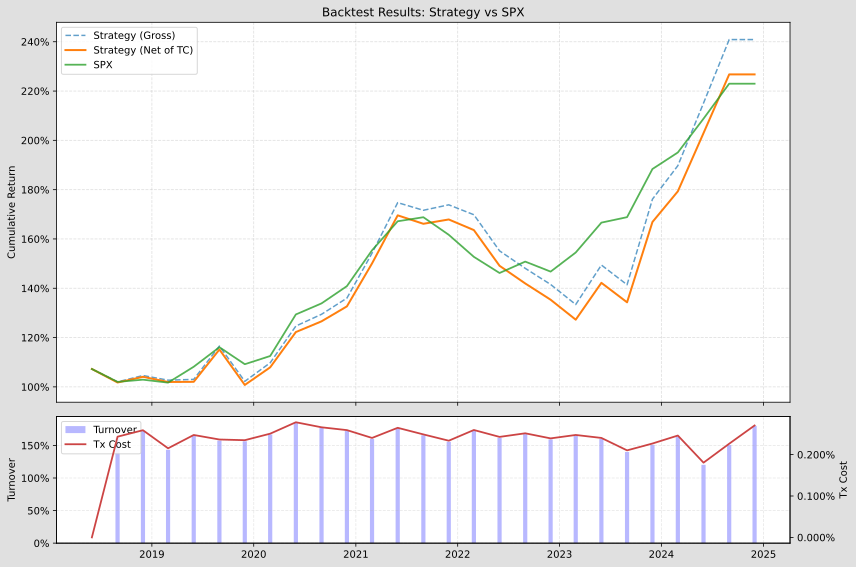


Backtest Summary:
Total Strategy Return: 126.74%
Total SPX Return:      122.99%
Outperformance:        3.75%
Annualized Return:     13.42%
Annualized Vol:        16.67%
Sharpe (0% rf):         0.72
Information Ratio:      0.02
Win Rate (alpha>0):    48.15%
Max Drawdown:          -24.95%
Average Turnover:      155.82%
Average Tx Cost:       0.23%


In [311]:
def summarize_backtest(backtest_results: pd.DataFrame):
    # Assumes spx_return and strategy_alpha are per-period log returns.
    if backtest_results is None or backtest_results.empty:
        print("No backtest results to display.")
        return

    br = backtest_results.copy().sort_index()
    req = {"cumulative_strategy","cumulative_spx","strategy_alpha","spx_return","turnover","transaction_cost"}
    missing = req - set(br.columns)
    if missing:
        print(f"Missing columns in results: {missing}")
        return

    # Per-period log returns
    r_strategy_log = (br["spx_return"].astype(float) + br["strategy_alpha"].astype(float)).fillna(0.0)
    r_a_log        = br["strategy_alpha"].astype(float).fillna(0.0)

    # Gross = add back costs to the stored net alpha
    r_alpha_gross_log    = (br["strategy_alpha"].astype(float) + br["transaction_cost"].astype(float)).fillna(0.0)
    r_strategy_gross_log = (br["spx_return"].astype(float) + r_alpha_gross_log).fillna(0.0)

    # Annualization scaffolding
    dt0, dt1 = br.index[0], br.index[-1]
    years = max((dt1 - dt0).days / 365.25, 1e-6)
    if len(br.index) > 1:
        days_step = float(np.median(np.diff(br.index.values).astype("timedelta64[D]").astype(float)))
        months_step = max(days_step / 30.0, 1e-6)
        periods_per_year = 12.0 / months_step
    else:
        periods_per_year = 12.0

    # Equity curves (log compounding)
    eq_gross = np.exp(r_strategy_gross_log.cumsum())
    eq_net   = np.exp(r_strategy_log.cumsum())
    eq_spx   = np.exp(br["spx_return"].astype(float).fillna(0.0).cumsum())

    # Totals
    total_strategy_return = float(eq_net.iloc[-1] - 1.0)
    total_spx_return      = float(eq_spx.iloc[-1] - 1.0)
    outperformance        = total_strategy_return - total_spx_return

    # Annualized stats using per-period log returns
    mu_p   = float(np.nanmean(r_strategy_log))
    sig_p  = float(np.nanstd(r_strategy_log, ddof=1)) if len(r_strategy_log) > 1 else 0.0
    ann_ret = (1.0 + total_strategy_return) ** (1.0 / max(years, 1e-6)) - 1.0
    ann_vol = sig_p * np.sqrt(periods_per_year) if sig_p > 0 else 0.0
    sharpe  = (mu_p / sig_p) * np.sqrt(periods_per_year) if sig_p > 0 else np.nan

    # Information ratio on alpha leg (log)
    mu_a  = float(np.nanmean(r_a_log))
    sig_a = float(np.nanstd(r_a_log, ddof=1)) if len(r_a_log) > 1 else 0.0
    info_ratio = (mu_a / sig_a) * np.sqrt(periods_per_year) if sig_a > 0 else np.nan
    win_rate = float((r_a_log > 0).mean())

    # Drawdown on the recomputed net equity curve
    eq = eq_net.replace([np.inf, -np.inf], np.nan).dropna()
    if not eq.empty:
        peak = eq.cummax()
        dd = eq / peak - 1.0
        max_dd = float(dd.min())
    else:
        max_dd = np.nan

    avg_turnover = float(br["turnover"].astype(float).mean())
    avg_tc = float(br["transaction_cost"].astype(float).mean())

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    ax1.plot(br.index, eq_gross, label="Strategy (Gross)", lw=1.5, ls="--", alpha=0.7)
    ax1.plot(br.index, eq_net,   label="Strategy (Net of TC)", lw=2)
    ax1.plot(br.index, eq_spx,   label="SPX", lw=1.8, alpha=0.8)
    ax1.set_title("Backtest Results: Strategy vs SPX")
    ax1.set_ylabel("Cumulative Return")
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax1.grid(True, ls="--", alpha=0.4)
    ax1.legend(loc="best")

    ax2.bar(br.index, br["turnover"].astype(float), width=15, label="Turnover", color="#8888ff", alpha=0.6)
    ax2b = ax2.twinx()
    ax2b.plot(br.index, br["transaction_cost"].astype(float), color="#cc4444", label="Tx Cost", lw=1.8)
    ax2.set_ylabel("Turnover")
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2b.set_ylabel("Tx Cost")
    ax2b.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.grid(True, ls="--", alpha=0.3)
    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = ax2b.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc="upper left")

    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

    # Summary
    print("\nBacktest Summary:")
    print(f"Total Strategy Return: {total_strategy_return:.2%}")
    print(f"Total SPX Return:      {total_spx_return:.2%}")
    print(f"Outperformance:        {outperformance:.2%}")
    print(f"Annualized Return:     {ann_ret:.2%}")
    print(f"Annualized Vol:        {ann_vol:.2%}")
    print(f"Sharpe (0% rf):        {sharpe: .2f}")
    print(f"Information Ratio:     {info_ratio: .2f}")
    print(f"Win Rate (alpha>0):    {win_rate:.2%}")
    print(f"Max Drawdown:          {max_dd:.2%}")
    print(f"Average Turnover:      {avg_turnover:.2%}")
    print(f"Average Tx Cost:       {avg_tc:.2%}")
# ...existing code...


summarize_backtest(backtest_results)


## Function: `performance_report`

Purpose
- Additional diagnostics: cumulative returns, drawdowns, rolling Sharpe/IR, alpha histogram, and policy usage; save CSV.

Input
- backtest_results: DataFrame from run_backtest_sequential.

Output
- Multiple plots; prints policy usage; writes backtest_results.csv.

Procedure
- Compute log-return curves and drawdowns.
- Rolling Sharpe/IR over ~1-year window.
- Alpha histogram with mean line.
- Print value_counts of optimal_select/optimal_alloc if present.

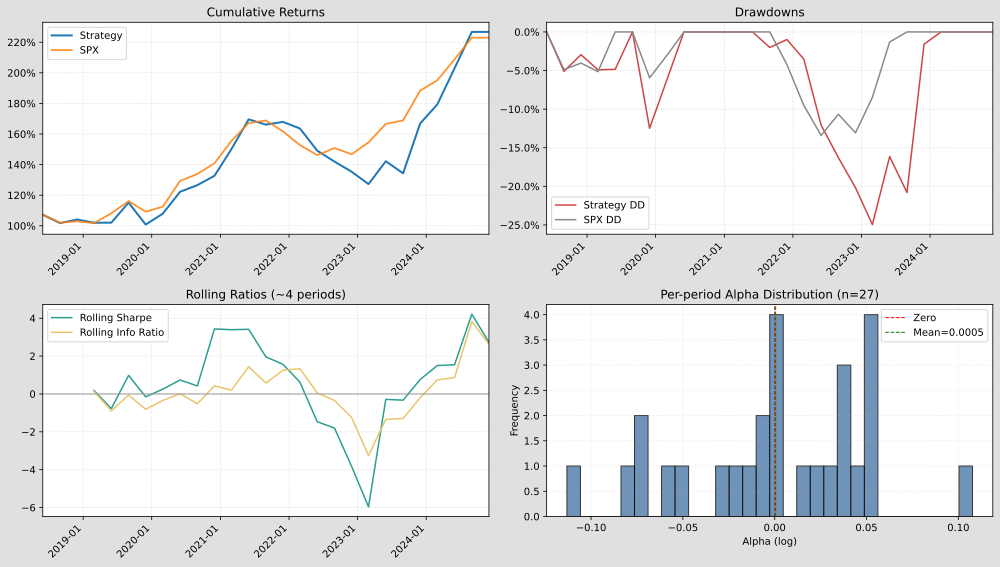


Policy usage:
Selection:
 optimal_select
TopK_LongShort           24
TopKInertia_LongShort     3
Name: count, dtype: int64

Allocation:
 optimal_alloc
allocate_kelly           12
allocate_MV              12
allocate_pY1_weighted     3
Name: count, dtype: int64

Saved: backtest_results.csv


In [312]:

def performance_report(backtest_results: pd.DataFrame):
    # Assumes spx_return and strategy_alpha are per-period log returns.
    if backtest_results is None or backtest_results.empty:
        print("No backtest results.")
        return

    br = backtest_results.copy().sort_index()
    need = {"cumulative_strategy","cumulative_spx","strategy_alpha","spx_return"}
    if not need.issubset(br.columns):
        print(f"Missing columns: {need - set(br.columns)}")
        return

    r_s_log = (br["spx_return"].astype(float) + br["strategy_alpha"].astype(float)).fillna(0.0)
    r_a_log = br["strategy_alpha"].astype(float).fillna(0.0)

    # infer periods/year
    if len(br.index) > 1:
        days_step = float(np.median(np.diff(br.index.values).astype("timedelta64[D]").astype(float)))
        months_step = max(days_step / 30.0, 1e-6)
        periods_per_year = 12.0 / months_step
    else:
        periods_per_year = 12.0
    win = max(3, int(round(periods_per_year)))  # ~1-year rolling window

    # Equity curves from log returns
    eq_s   = np.exp(r_s_log.cumsum())
    eq_spx = np.exp(br["spx_return"].astype(float).fillna(0.0).cumsum())

    # drawdowns
    def drawdown(eq):
        peak = eq.cummax()
        return eq/peak - 1.0
    dd_s   = drawdown(eq_s)
    dd_spx = drawdown(eq_spx)

    # rolling Sharpe/IR on log returns
    def roll_ratio(x):
        mu, sig = np.nanmean(x), np.nanstd(x, ddof=1)
        return 0.0 if sig == 0 or np.isnan(sig) else (mu/sig)*np.sqrt(periods_per_year)
    roll_sharpe = r_s_log.rolling(win).apply(roll_ratio, raw=True)
    roll_ir     = r_a_log.rolling(win).apply(roll_ratio, raw=True)

    # figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax1, ax2, ax3, ax4 = axes.ravel()

    date_min = br.index.min()
    date_max = br.index.max()

    # equity
    ax1.plot(eq_s.index, eq_s, label="Strategy", lw=2)
    ax1.plot(eq_spx.index, eq_spx, label="SPX", lw=1.8, alpha=0.85)
    ax1.set_title("Cumulative Returns")
    ax1.set_xlim(date_min, date_max)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax1.grid(True, ls="--", alpha=0.3)
    ax1.legend()
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # drawdowns
    ax2.plot(dd_s.index, dd_s, label="Strategy DD", color="#cc4444")
    ax2.plot(dd_spx.index, dd_spx, label="SPX DD", color="#888")
    ax2.set_title("Drawdowns")
    ax2.set_xlim(date_min, date_max)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.grid(True, ls="--", alpha=0.3)
    ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # rolling risk ratios
    ax3.plot(roll_sharpe.index, roll_sharpe, label="Rolling Sharpe", color="#2a9d8f")
    ax3.plot(roll_ir.index, roll_ir, label="Rolling Info Ratio", color="#e9c46a")
    ax3.axhline(0, color="#999", lw=1)
    ax3.set_title(f"Rolling Ratios (~{win} periods)")
    ax3.set_xlim(date_min, date_max)
    ax3.grid(True, ls="--", alpha=0.3)
    ax3.legend()
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax3.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # alpha histogram (log per-period)
    r_a_clean = r_a_log.replace([np.inf, -np.inf], np.nan).dropna()
    if len(r_a_clean) > 0:
        alpha_values = r_a_clean.values
        ax4.hist(alpha_values, bins=30, color="#4c78a8", alpha=0.8, edgecolor='black')
        ax4.set_title(f"Per-period Alpha Distribution (n={len(alpha_values)})")
        ax4.set_xlabel("Alpha (log)")
        ax4.set_ylabel("Frequency")
        ax4.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero')
        ax4.axvline(alpha_values.mean(), color='green', linestyle='--', linewidth=1, 
                    label=f'Mean={alpha_values.mean():.4f}')
        ax4.legend()
        ax4.grid(True, ls="--", alpha=0.2)
    else:
        ax4.text(0.5, 0.5, "No valid alpha data", ha='center', va='center',
                 transform=ax4.transAxes, fontsize=14, color='red')
        ax4.set_title("Per-period Alpha (log)")

    plt.tight_layout()
    plt.show()

    if "optimal_select" in br.columns and "optimal_alloc" in br.columns:
        print("\nPolicy usage:")
        print("Selection:\n", br["optimal_select"].value_counts())
        print("\nAllocation:\n", br["optimal_alloc"].value_counts())

    br.to_csv("backtest_results.csv")
    print("\nSaved: backtest_results.csv")


# After running summarize_backtest(backtest_results)
performance_report(backtest_results)

- Function: `_parents_of_Yt`

Purpose
- Utility to list parent node names of Yt in a BayesNet.

Input
- bn: gum.BayesNet.

Output
- List of parent variable names (strings).

Procedure
- Query bn.parents(id(Yt)) and map to names with error handling.

- Function: `_row_evidence_for`

Purpose
- Build an evidence dict for the parents of Yt from a specific (date, ticker) row in two_slice_df.

Inputs
- bn: BayesNet.
- two_slice_df: Two-slice DataFrame.
- date, ticker: Keys to locate the row.

Output
- dict of {parent_name: int(state)} usable as evidence.

Procedure
- Find parent names of Yt, locate row, collect any available parent states as ints.


- Function: `_posterior_pYt1`

Purpose
- Compute P(Yt=1 | evidence) for a BayesNet.

Inputs
- bn: BayesNet.
- ev: dict or None.

Output
- Float probability.

Procedure
- Run LazyPropagation; set evidence if provided; compute posterior('Yt'); pick index of label '1' (fallback to 1).


- Function: `explain_pY1_for_ticker`

Purpose
- Local explanation for a single ticker/date: posterior p(Yt=1), prior, per-feature contributions (leave-one-out log-odds), and sensitivity across states.

Inputs
- bn, two_slice_df, date, ticker.
- top_k: Max contributions to return.

Output
- dict with p_all, p_prior, evidence, contrib_df, and sensitivity summaries.

Procedure
- Build full evidence; compute posterior (p_all) and prior (p_prior).
- For each evidence variable, recompute posterior w/o that variable; record Δlog-odds and Δprob.
- For sensitivity, vary one parent across its domain holding others fixed; record p-range.


- Function: `plot_explanation`

Purpose
- Visualize local explanation: waterfall-style contributions (Δlog-odds) and prior vs posterior probability.

Input
- expl: dict from explain_pY1_for_ticker.
- max_bars: Limit for contributions.

Output
- Two plots; no return.

Procedure
- Horizontal bar chart for top contributions; bar chart for prior/posterior probabilities.

- Function: `explain_top_sensitivity`

Purpose
- Plot the most influential parents’ sensitivity curves (p(Yt=1) across their states).

Inputs
- expl: dict from explain_pY1_for_ticker.
- max_plots: Number of variables to display.

Output
- Line plots; no return.

Procedure
- Rank features by p-range; plot p vs state label per feature.

In [313]:
# --- DBN local explanations: per-ticker probability and drivers ---

def _parents_of_Yt(bn: gum.BayesNet):
    try:
        pids = list(bn.parents(bn.idFromName('Yt')))
        return [bn.variable(pid).name() for pid in pids]
    except Exception:
        return []

def _row_evidence_for(bn: gum.BayesNet, two_slice_df: pd.DataFrame, date, ticker):
    # build evidence dict for all available parents from the row (date,ticker)
    pnames = set(_parents_of_Yt(bn))
    sub = two_slice_df.loc[(pd.Timestamp(date), ticker)]
    ev = {}
    for name in pnames:
        if name in sub.index and pd.notna(sub[name]):
            try:
                ev[name] = int(sub[name])
            except Exception:
                pass
    return ev

def _posterior_pYt1(bn: gum.BayesNet, ev: dict | None):
    # compute P(Yt=1 | ev)
    ie = gum.LazyPropagation(bn)
    if ev:
        ie.setEvidence(ev)
    ie.makeInference()
    post = ie.posterior('Yt')
    try:
        idx1 = bn.variable('Yt').index('1')
    except Exception:
        idx1 = 1  # fallback
    return float(post[idx1])

def explain_pY1_for_ticker(bn: gum.BayesNet,
                           two_slice_df: pd.DataFrame,
                           date,
                           ticker,
                           top_k: int = 12):
    """
    Return:
      - p_all: P(Yt=1 | all parents evidence for this date,ticker)
      - p_prior: P(Yt=1) with no evidence
      - contrib_df: per-parent impact via leave-one-out on log-odds
      - sens_dict: per-parent sensitivity across all its states
    """
    date = pd.Timestamp(date)
    # all-evidence posterior
    ev_all = _row_evidence_for(bn, two_slice_df, date, ticker)
    p_all = _posterior_pYt1(bn, ev_all)
    p_prior = _posterior_pYt1(bn, ev=None)

    # contributions using leave-one-out in log-odds space
    def _logit(p): 
        p = min(max(p, 1e-9), 1-1e-9)
        return np.log(p/(1-p))

    rows = []
    for var in sorted(ev_all.keys()):
        ev_minus = {k:v for k,v in ev_all.items() if k != var}
        p_minus = _posterior_pYt1(bn, ev_minus)
        d_logit = _logit(p_all) - _logit(p_minus)
        d_prob  = p_all - p_minus

        # pretty state label
        v = bn.variable(var)
        st = ev_all[var]
        lab = v.label(st) if st < v.domainSize() else str(st)

        rows.append({
            'var': var,
            'state_idx': int(st),
            'state_label': str(lab),
            'p_without': float(p_minus),
            'delta_logit': float(d_logit),
            'delta_prob': float(d_prob)
        })
    contrib_df = pd.DataFrame(rows).sort_values('delta_logit', key=np.abs, ascending=False)
    if top_k is not None:
        contrib_df = contrib_df.head(top_k)

    # per-feature sensitivity: vary each parent across its domain
    sens = {}
    # base evidence without the feature being varied
    for var in _parents_of_Yt(bn):
        if var not in two_slice_df.columns:  # may be absent from this two-slice build
            continue
        # start from all-evidence then override var
        base_ev = dict(ev_all)
        base_ev.pop(var, None)

        v = bn.variable(var)
        vals, probs = [], []
        for s in range(v.domainSize()):
            ev_try = dict(base_ev)
            ev_try[var] = int(s)
            p_try = _posterior_pYt1(bn, ev_try)
            vals.append(s)
            probs.append(p_try)
        if vals:
            sens[var] = {
                'states': vals,
                'labels': [v.label(s) for s in vals],
                'pY1': probs,
                'range': (float(np.min(probs)), float(np.max(probs)))
            }

    return {
        'date': date,
        'ticker': ticker,
        'p_all': p_all,
        'p_prior': p_prior,
        'evidence': ev_all,
        'contrib_df': contrib_df,
        'sensitivity': sens
    }

def plot_explanation(expl, max_bars=12):
    # Waterfall-style bar chart by delta_logit contribution
    df = expl['contrib_df'].copy().head(max_bars)
    if df.empty:
        print("No contributions to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax = axes[0]
    ax.barh(df['var'] + " = " + df['state_label'], df['delta_logit'],
            color=np.where(df['delta_logit']>=0, '#2a9d8f', '#e76f51'))
    ax.axvline(0, color='#777', lw=1)
    ax.set_title(f"Log-odds contributions to p(Yt=1)\n{expl['ticker']} @ {expl['date'].date()}")
    ax.set_xlabel("Δ log-odds (with vs without feature)")
    ax.grid(True, ls='--', alpha=0.3)
    ax.invert_yaxis()

    # Prior vs posterior
    ax2 = axes[1]
    ax2.bar(['Prior', 'Posterior'], [expl['p_prior'], expl['p_all']], color=['#8ecae6', '#219ebc'])
    ax2.set_ylim(0,1)
    ax2.set_ylabel("Probability")
    ax2.set_title("P(Yt=1) before/after evidence")
    ax2.grid(True, ls='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

def explain_top_sensitivity(expl, max_plots=4):
    # Plot the most influential features’ sensitivity (by p-range)
    sens = expl['sensitivity']
    if not sens:
        print("No sensitivity info.")
        return
    # rank by range
    ranked = sorted(sens.items(), key=lambda kv: kv[1]['range'][1]-kv[1]['range'][0], reverse=True)[:max_plots]
    n = len(ranked)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 3), squeeze=False)
    for j,(var, info) in enumerate(ranked):
        ax = axes[0, j]
        ax.plot(info['labels'], info['pY1'], marker='o')
        ax.set_title(f"{var}\nrange={info['range'][0]:.3f}..{info['range'][1]:.3f}")
        ax.set_ylim(0,1)
        ax.grid(True, ls='--', alpha=0.3)
        ax.set_xlabel("State")
        if j==0:
            ax.set_ylabel("P(Yt=1)")
    plt.tight_layout()
    plt.show()

Ticker=A, date=1994-07-31, p_prior=0.503, p_all=0.168


,var,state_idx,state_label,p_without,delta_logit,delta_prob
4,rsi_14_t,1,1,0.405455,-1.218713,-0.237683
0,Y0,0,0,0.345102,-0.960864,-0.177331
5,willr_14_t,1,1,0.277143,-0.642821,-0.109371
1,ema_26_t,2,2,0.229981,-0.393082,-0.062209
2,macd_hist_t,2,2,0.151551,0.120989,0.016221
3,natr_14_t,1,1,0.170357,-0.018399,-0.002585


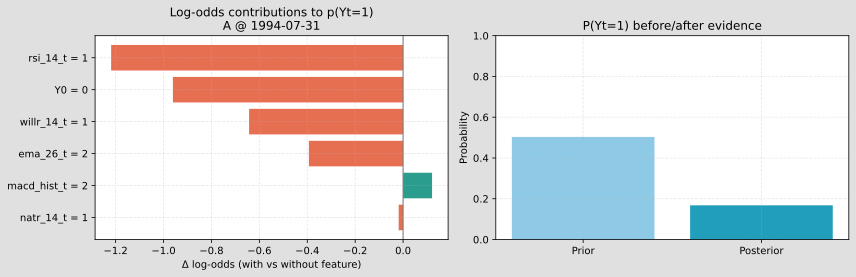

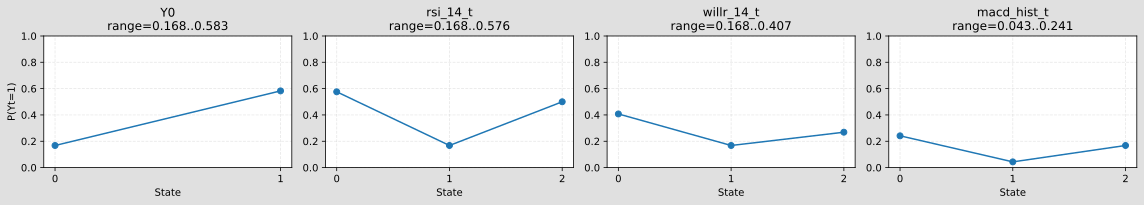

In [314]:
# Pick a date and ticker present in your two_slice
available_dates_in_two_slice = two_slice.index.get_level_values('date').unique().sort_values()
test_date = available_dates_in_two_slice[10]  # Use 11th date from two_slice
date_explain = test_date  # or any date in two_slice.index.get_level_values('date')
tickers_on_date = two_slice.loc[date_explain].index.get_level_values('ticker')
ticker_explain = tickers_on_date[0]  # or choose one you care about

expl = explain_pY1_for_ticker(twodbn, two_slice, date_explain, ticker_explain)
print(f"Ticker={expl['ticker']}, date={expl['date'].date()}, p_prior={expl['p_prior']:.3f}, p_all={expl['p_all']:.3f}")
display(expl['contrib_df'])
plot_explanation(expl)
explain_top_sensitivity(expl)

- Function: `id_probabilities_and_eu`

Purpose
- Extract P(R_port | D_select, D_alloc) and compute the expected utility matrix EU[i,j] from an Influence Diagram.

Inputs
- ID: InfluenceDiagram.
- actions_select, actions_alloc: Lists.

Outputs
- EU: 2D array of expected utility by (selection, allocation).
- prob_cube: 3D array [R_port_state, i, j] of probabilities.
- opt_idx: (i*, j*) argmax of EU.

Procedure
- Read utility vector over R_port states.
- For each (i,j), read CPT entries P(R_port=k | i,j), normalize, compute dot with utility vector.

- Function: `explain_id_choice`

Purpose
- Print a concise explanation of the ID’s chosen policy, the EU matrix, probability distribution over return bins, and (optionally) drivers μ/σ² and expected turnover.

Inputs
- ID, actions_select, actions_alloc.
- mu_mat, var_mat: Optional matrices used to parameterize R_port.
- calib_debug: Optional diagnostics containing turnover_mat and gamma.

Output
- Prints summary; no return.

Procedure
- Call id_probabilities_and_eu to get EU and optimal indices.
- Pretty-print EU table, chosen policy, P(R_port | chosen).
- If provided, print μ, σ², and expected turnover and γ.

In [315]:
# --- ID-level explanations: probabilities and reasons behind the chosen decision ---

def id_probabilities_and_eu(ID: gum.InfluenceDiagram, actions_select: list[str], actions_alloc: list[str]):
    """
    Read the CPT of R_port and the utility table U to build:
      - P(R_port | D_select=i, D_alloc=j)
      - EU[i,j] = sum_k U(k) * P(R_port=k | i,j)
    Returns EU_matrix, prob_cube, optimal (i,j).
    """
    cpt_rp   = ID.cpt("R_port")      # P(R_port | D_select, D_alloc)
    util_tab = ID.utility("U")
    n_sel    = len(actions_select)
    n_alloc  = len(actions_alloc)
    n_bins   = ID.variable("R_port").domainSize()

    # u_vec[k] for each R_port state k (keeping other parents fixed as created)
    u_vec = np.zeros(n_bins)
    instU = gum.Instantiation(util_tab)
    for k in range(n_bins):
        instU.chgVal("R_port", k)
        u_vec[k] = util_tab.get(instU)

    # Build probability cube P[k, i, j]
    prob_cube = np.zeros((n_bins, n_sel, n_alloc))
    instR = gum.Instantiation(cpt_rp)
    for i_sel in range(n_sel):
        for j_alloc in range(n_alloc):
            p_vec = np.zeros(n_bins)
            for k in range(n_bins):
                instR.chgVal("R_port", k)
                instR.chgVal("D_select", i_sel)
                instR.chgVal("D_alloc",  j_alloc)
                p_vec[k] = cpt_rp.get(instR)
            s = p_vec.sum()
            if s > 0:
                p_vec /= s
            prob_cube[:, i_sel, j_alloc] = p_vec

    # EU[i,j]
    EU = np.zeros((n_sel, n_alloc))
    for i_sel in range(n_sel):
        for j_alloc in range(n_alloc):
            EU[i_sel, j_alloc] = float(np.dot(u_vec, prob_cube[:, i_sel, j_alloc]))

    opt_idx = np.unravel_index(np.argmax(EU), EU.shape)
    return EU, prob_cube, opt_idx

def explain_id_choice(ID: gum.InfluenceDiagram,
                      actions_select: list[str],
                      actions_alloc: list[str],
                      mu_mat: np.ndarray | None = None,
                      var_mat: np.ndarray | None = None,
                      calib_debug: dict | None = None):
    EU, prob_cube, (i_star, j_star) = id_probabilities_and_eu(ID, actions_select, actions_alloc)

    print("Optimal policy:")
    print(f"  D_select = {actions_select[i_star]}")
    print(f"  D_alloc  = {actions_alloc[j_star]}")
    print(f"  Max EU   = {EU[i_star, j_star]:.6f}\n")

    # Show EU table
    print("Expected Utility (rows=selection, cols=allocation):")
    for i, sel in enumerate(actions_select):
        row = "  " + f"{sel:<18}" + " ".join([f"{EU[i,j]:>12.6f}{' *' if (i==i_star and j==j_star) else ''}" for j in range(len(actions_alloc))])
        print(row)
    print("  * = chosen\n")

    # Show P(R_port | chosen)
    r_labels = [ID.variable('R_port').label(k) for k in range(ID.variable('R_port').domainSize())]
    p_vec = prob_cube[:, i_star, j_star]
    print("P(R_port | chosen D_select, D_alloc):")
    for lab, p in zip(r_labels, p_vec):
        print(f"  {lab:<16} : {p:>7.3%}")
    print()

    # If mu/var were fed into the ID construction, show the immediate drivers
    if mu_mat is not None and var_mat is not None:
        mu  = float(mu_mat[i_star, j_star])
        var = float(var_mat[i_star, j_star])
        print(f"Driver stats for chosen policy (from calibration step):")
        print(f"  Expected forward return (μ): {mu:.6f}")
        print(f"  Variance estimate (σ²):      {var:.6f}")
    if calib_debug is not None and 'turnover_mat' in calib_debug:
        to = float(calib_debug['turnover_mat'][i_star, j_star])
        print(f"  Expected turnover:           {to:.3f}")
        if 'gamma_turnover' in calib_debug:
            print(f"  Turnover penalty γ:          {float(calib_debug['gamma_turnover']):.6f} ({calib_debug.get('turnover_mode','gross')})")

In [316]:
EU, prob_cube, (i_opt, j_opt) = id_probabilities_and_eu(ID, actions_select, actions_alloc)
explain_id_choice(ID, actions_select, actions_alloc, mu_mat=mu_mat, var_mat=var_mat, calib_debug=calib_debug)

Optimal policy:
  D_select = TopK_LongShort
  D_alloc  = allocate_MV
  Max EU   = 0.078619

Expected Utility (rows=selection, cols=allocation):
  TopK_LongOnly         0.061409     0.057047     0.056698     0.047857
  TopK_LongShort        0.078619 *     0.076755     0.076326     0.029100
  Symmetric_LS          0.077686     0.075491     0.075171     0.029159
  TopKInertia_LongShort    0.078619     0.076755     0.076326     0.029100
  * = chosen

P(R_port | chosen D_select, D_alloc):
  big_loss(≤ -5%)  :  0.005%
  down(-5..0%)     :  1.068%
  flat(0..2%)      :  3.803%
  up(2..5%)        : 19.555%
  strong(>5%)      : 75.569%

Driver stats for chosen policy (from calibration step):
  Expected forward return (μ): 0.071540
  Variance estimate (σ²):      0.000967
  Expected turnover:           0.000
  Turnover penalty γ:          0.000000 (gross)


,var,state_idx,state_label,p_without,delta_logit,delta_prob
4,rsi_14_t,2,2,0.440562,2.183909,0.434341
1,ema_26_t,0,0,0.558520,1.709871,0.316384
5,willr_14_t,0,0,0.666141,1.254248,0.208763
0,Y0,0,0,0.690955,1.140440,0.183948
3,natr_14_t,0,0,0.722443,0.988418,0.152461
2,macd_hist_t,0,0,0.815341,0.459935,0.059563


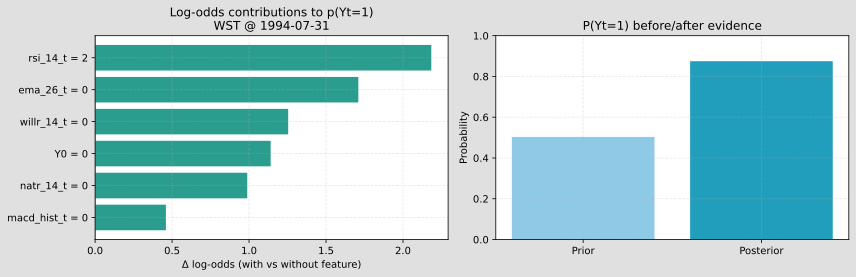

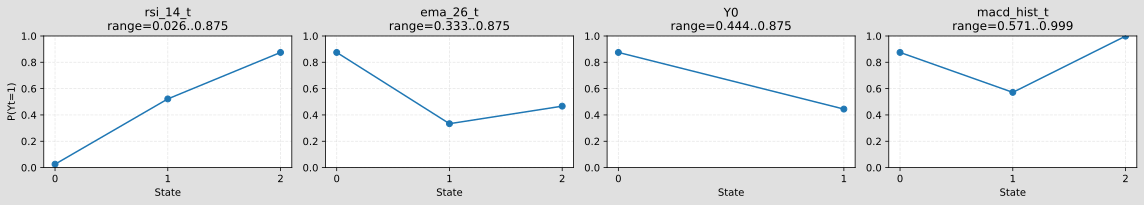

Optimal policy:
  D_select = TopK_LongShort
  D_alloc  = allocate_MV
  Max EU   = 0.078619

Expected Utility (rows=selection, cols=allocation):
  TopK_LongOnly         0.061409     0.057047     0.056698     0.047857
  TopK_LongShort        0.078619 *     0.076755     0.076326     0.029100
  Symmetric_LS          0.077686     0.075491     0.075171     0.029159
  TopKInertia_LongShort    0.078619     0.076755     0.076326     0.029100
  * = chosen

P(R_port | chosen D_select, D_alloc):
  big_loss(≤ -5%)  :  0.005%
  down(-5..0%)     :  1.068%
  flat(0..2%)      :  3.803%
  up(2..5%)        : 19.555%
  strong(>5%)      : 75.569%

Driver stats for chosen policy (from calibration step):
  Expected forward return (μ): 0.071540
  Variance estimate (σ²):      0.000967
  Expected turnover:           0.000
  Turnover penalty γ:          0.000000 (gross)


In [317]:
# Find top pY1 ticker and explain it
pY1_today = score_cross_section_pY1(twodbn, two_slice, test_date).sort_values(ascending=False)
top_tk = pY1_today.index[0]
expl = explain_pY1_for_ticker(twodbn, two_slice, test_date, top_tk)
display(expl['contrib_df'])
plot_explanation(expl)
explain_top_sensitivity(expl)

# And explain the ID’s decision
explain_id_choice(ID, actions_select, actions_alloc, mu_mat=mu_mat, var_mat=var_mat, calib_debug=calib_debug)